# Curso de Especialización en Python — Desarrollo profundo por módulos

A continuación se desarrollan con **profundidad teórica y práctica** todos los epígrafes, explicados para un estudiante de informática. Cada epígrafe incluye: **conceptos clave**, **explicación razonada**, **ejemplos ejecutables**, **errores frecuentes** y **batería de test**.

---
## Configuración inicial — Instalación de librerías necesarias

Ejecuta la siguiente celda para instalar todas las dependencias del curso.
Asegúrate de haber seleccionado el intérprete Python correcto en el menú **Kernel → Change kernel** (Jupyter) o en la barra superior de VS Code / Kiro.

In [1]:
# ── Configuración inicial — Instalación robusta de dependencias ─────────────
import sys

print(f"Intérprete activo: {sys.executable}")
print(f"Versión Python: {sys.version}")

if sys.version_info < (3, 10):
    print("\n⚠ AVISO: este curso usa 'match/case' (3.10+) y sintaxis moderna de 'typing'.")
    print("  Se recomienda Python 3.10 o superior. Verifica tu kernel en")
    print("  Kernel → Change kernel (Jupyter) o la barra superior de VS Code / Kiro.\n")

paquetes = [
    "flask", "fastapi", "uvicorn", "requests", "pandas", "numpy",
    "openpyxl", "matplotlib", "seaborn", "scikit-learn", "sqlalchemy", "pytest",
]

import subprocess

def instalar(paquete):
    """Intenta instalar normalmente; si el entorno está 'externally-managed'
    (Python del sistema en Linux/Ubuntu recientes, PEP 668), reintenta con --user."""
    r = subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", paquete],
                        capture_output=True, text=True)
    if r.returncode != 0 and "externally-managed-environment" in (r.stderr or ""):
        r = subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--user", paquete],
                            capture_output=True, text=True)
    return r

fallidos = []
for paquete in paquetes:
    resultado = instalar(paquete)
    if resultado.returncode != 0:
        fallidos.append(paquete)
        print(f"✗ Error instalando {paquete}:")
        print("  ", resultado.stderr.strip().splitlines()[-1] if resultado.stderr else "error desconocido")
    else:
        print(f"✓ {paquete}")

if fallidos:
    print(f"\n⚠ No se pudieron instalar: {', '.join(fallidos)}.")
    print("  Si el error menciona 'externally-managed-environment', crea un entorno")
    print("  virtual (ver epígrafe 1.3) con 'python -m venv env' y actívalo antes de")
    print("  volver a ejecutar esta celda. Si el error es de red, revisa tu conexión.")
else:
    print("\nInstalación completada correctamente. Todos los paquetes están disponibles.")

Intérprete activo: /usr/bin/python3
Versión Python: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]


✗ Error instalando flask:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando fastapi:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando uvicorn:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando requests:
   hint: See PEP 668 for the detailed specification.


...

✗ Error instalando matplotlib:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando seaborn:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando scikit-learn:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando sqlalchemy:
   hint: See PEP 668 for the detailed specification.


✗ Error instalando pytest:
   hint: See PEP 668 for the detailed specification.

⚠ No se pudieron instalar: flask, fastapi, uvicorn, requests, pandas, numpy, openpyxl, matplotlib, seaborn, scikit-learn, sqlalchemy, pytest.
  Si el error menciona 'externally-managed-environment', crea un entorno
  virtual (ver epígrafe 1.3) con 'python -m venv env' y actívalo antes de
  volver a ejecutar esta celda. Si el error es de red, revisa tu conexión.


---
# MÓDULO 5098 — ENTORNOS Y SINTAXIS EN PYTHON (3 ECTS, 25 h)

## Epígrafe 1.1 — Análisis de problemas y estrategias de resolución

### 1.1.1 Conceptos clave

| Concepto | Definición |
|---|---|
| **Entorno de aplicación** | Contexto donde se ejecutará el programa: CLI, web, escritorio, móvil, IoT, ciencia de datos. |
| **Estrategia** | Plan ordenado de acciones para transformar una entrada en una salida correcta. |
| **Descomposición** | Dividir un problema complejo en subproblemas más simples e independientes. |
| **Refinamiento por pasos** | Desarrollar la solución de lo general a lo específico. |
| **Diagrama de flujo** | Representación gráfica del algoritmo mediante símbolos normalizados. |
| **Implementabilidad** | Grado en que una solución puede codificarse con los recursos disponibles. |

### 1.1.2 Explicación razonada

Cuando un ingeniero informático se enfrenta a un problema, **no debe escribir código inmediatamente**. El proceso correcto es:

1. **Comprender el problema**: identificar entradas, salidas, restricciones y casos límite.
2. **Identificar el entorno**: no es lo mismo un script CLI que una API REST o un modelo de ML. El entorno condiciona librerías, rendimiento y despliegue.
3. **Diseñar estrategias**: normalmente se aplica *divide y vencerás*. Cada subproblema se resuelve por separado y luego se integra.
4. **Analizar dificultades**: complejidad temporal/espacial, dependencias externas, formatos de datos, concurrencia.
5. **Representar con diagramas de flujo**: permiten visualizar el flujo antes de codificar. Símbolos estándar:
   - Óvalo → inicio/fin
   - Rectángulo → proceso
   - Rombo → decisión
   - Paralelogramo → entrada/salida
   - Flechas → flujo
6. **Seleccionar el diagrama óptimo**: el que sea más claro, modular y con menor coste de implementación.
7. **Verificar implementabilidad en Python**: comprobar que existen librerías, que el rendimiento es aceptable y que la sintaxis lo permite.

> **Ejemplo razonado**: si el problema es "calcular la nómina de 10.000 empleados", un diagrama con un bucle simple es implementable, pero si el problema es "procesar 10 TB de logs", habrá que pensar en `pandas`, `dask` o procesamiento por lotes.

### 1.1.4 Errores frecuentes

- Codificar antes de analizar → retrabajo.
- Ignorar el entorno → elegir librerías incompatibles.
- No contemplar casos límite (vacío, negativo, desbordamiento).
- Diagramas demasiado detallados que se vuelven ilegibles.

In [2]:
# ── Práctica guiada 1.1 ──────────────────────────────────────────────────────
# Problema: determinar si un año es bisiesto
# Estrategia: descomposición en una condición booleana
# Diagrama: decisión simple

def es_bisiesto(anio: int) -> bool:
    """
    Un año es bisiesto si:
    - Es divisible por 4 Y no por 100
    - O es divisible por 400
    """
    return (anio % 4 == 0 and anio % 100 != 0) or (anio % 400 == 0)

# Casos de prueba (verificación de implementabilidad)
casos = [(2000, True), (1900, False), (2024, True), (2023, False)]
for anio, esperado in casos:
    assert es_bisiesto(anio) == esperado, f"Fallo en {anio}"
print("Todos los casos pasan")

# Ejercicio: dibuja el diagrama de flujo de `es_bisiesto` y compáralo con la
# implementación. ¿Hay alguna rama que no se ejecute nunca?

Todos los casos pasan


### 1.1.5 Test (10 preguntas)

1. ¿Qué símbolo representa una decisión en un diagrama de flujo?  
   a) Rectángulo &nbsp; b) Rombo &nbsp; c) Óvalo &nbsp; d) Paralelogramo

2. La descomposición modular busca principalmente…  
   a) menos líneas &nbsp; b) reutilización y claridad &nbsp; c) más velocidad &nbsp; d) evitar funciones

3. ¿Cuál NO es un entorno típico de Python?  
   a) CLI &nbsp; b) Web &nbsp; c) Kernel Linux &nbsp; d) Data science

4. Un pseudocódigo es…  
   a) código ejecutable &nbsp; b) lenguaje formal &nbsp; c) descripción algorítmica legible &nbsp; d) bytecode

5. La verificación de implementabilidad comprueba…  
   a) que el diagrama es bonito &nbsp; b) que la solución puede codificarse en Python &nbsp; c) que no hay errores &nbsp; d) el coste

6. En un diagrama de flujo, un paralelogramo indica…  
   a) proceso &nbsp; b) decisión &nbsp; c) E/S &nbsp; d) inicio

7. ¿Qué criterio NO ayuda a elegir el diagrama óptimo?  
   a) modularidad &nbsp; b) claridad &nbsp; c) color del fondo &nbsp; d) coste

8. La estrategia "divide y vencerás" implica…  
   a) un solo bloque &nbsp; b) subproblemas independientes &nbsp; c) recursión obligatoria &nbsp; d) bucles infinitos

9. Analizar dificultades sirve para…  
   a) retrasar el proyecto &nbsp; b) anticipar riesgos &nbsp; c) escribir más código &nbsp; d) evitar tests

10. La implementabilidad en Python se ve limitada por…  
    a) sintaxis estricta &nbsp; b) tipado dinámico &nbsp; c) disponibilidad de librerías &nbsp; d) no hay límites

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 1.1 — es_palindromo

Escribe 'es_palindromo(texto)' que indique si una cadena se lee igual al derecho y al revés, ignorando mayúsculas y espacios.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [3]:
def es_palindromo(texto: str) -> bool:
    # TODO: implementa aquí tu solución
    ...

_casos = [("Anita lava la tina", True), ("Python", False), ("reconocer", True), ("A", True)]
_ok = 0
for _entrada, _esperado in _casos:
    try:
        _resultado = es_palindromo(_entrada)
    except Exception as e:
        print(f"✗ Error al probar {_entrada!r}: {e}"); continue
    if _resultado == _esperado:
        _ok += 1; print(f"✓ es_palindromo({_entrada!r}) = {_resultado}")
    else:
        print(f"✗ es_palindromo({_entrada!r}) = {_resultado}  (esperado {_esperado})")
print(f"\nResultado: {_ok}/{len(_casos)} casos correctos")

✗ es_palindromo('Anita lava la tina') = None  (esperado True)
✗ es_palindromo('Python') = None  (esperado False)
✗ es_palindromo('reconocer') = None  (esperado True)
✗ es_palindromo('A') = None  (esperado True)

Resultado: 0/4 casos correctos


---
## Epígrafe 1.2 — Caracterización de elementos de programación en Python

### 1.2.1 Conceptos clave

| Concepto | Explicación |
|---|---|
| **Alto nivel** | El lenguaje abstrae el hardware; el programador trabaja con estructuras lógicas. |
| **Compilado** | Traduce todo el código a binario antes de ejecutar (C, C++). |
| **Interpretado** | Ejecuta instrucción a instrucción mediante un intérprete. |
| **Bytecode** | Representación intermedia que ejecuta la VM de Python (CPython). |
| **JIT** | Just-In-Time: compila en tiempo de ejecución (PyPy). |
| **Bloque** | Conjunto de sentencias con el mismo nivel de indentación. |
| **Scope** | Ámbito donde una variable es visible (local, global, nonlocal). |

### 1.2.2 Explicación razonada

Python es un lenguaje **de alto nivel, interpretado y con tipado dinámico fuerte**. Internamente:

1. El código fuente `.py` se compila a **bytecode** `.pyc`.
2. La **PVM** (Python Virtual Machine) ejecuta ese bytecode.
3. Existen implementaciones alternativas: **CPython** (referencia), **PyPy** (JIT, más rápido), **Jython** (JVM), **IronPython** (.NET).

**Diferencias entre versiones importantes**:
- Python 2 vs 3: `print` era sentencia → ahora función; `/` era división entera → ahora real; strings Unicode por defecto.
- 3.8: operador walrus `:=`.
- 3.10: `match/case` (pattern matching).
- 3.11: mejoras de rendimiento (~25%).
- 3.12: type parameter syntax, f-strings mejoradas.

**Bloques fundamentales de un programa Python**:
- Módulos (`.py`)
- Funciones (`def`)
- Clases (`class`)
- Expresiones y sentencias
- Comentarios y docstrings

**Errores frecuentes**:
- Argumentos mutables por defecto (`def f(l=[])`).
- Confundir `is` con `==`.
- Modificar una lista mientras se itera.
- Scope mal entendido (LEGB: Local → Enclosing → Global → Built-in).

**Depuración**: `pdb`, `breakpoint()`, `logging`, `traceback`. Comparar código antes/después de depurar es una práctica profesional.

In [4]:
# ── Práctica guiada 1.2 ──────────────────────────────────────────────────────

# 1) Diferencia compilado/interpretado (bytecode visible)
import dis
def suma(a, b): return a + b
dis.dis(suma)   # muestra el bytecode

# 2) Error frecuente: mutable por defecto
def malo(lista=[]):
    lista.append(1)
    return lista

def bueno(lista=None):
    if lista is None:
        lista = []
    lista.append(1)
    return lista

print(malo(), malo())    # [1, 1]  ← sorpresa
print(bueno(), bueno())  # [1] [1]

# 3) Scope LEGB
x = "global"
def outer():
    x = "enclosing"
    def inner():
        nonlocal x
        x = "nonlocal"
    inner()
    return x
print(outer())  # nonlocal

# 4) Depuración con pdb
# Descomenta la siguiente línea para activar el depurador interactivo:
# def dividir(a, b):
#     breakpoint()   # pausa aquí
#     return a / b
# dividir(10, 2)

  5           0 RESUME                   0
              2 LOAD_FAST                0 (a)
              4 LOAD_FAST                1 (b)
              6 BINARY_OP                0 (+)
             10 RETURN_VALUE
[1, 1] [1, 1]
[1] [1]
nonlocal


### 1.2.4 Test

1. Python es…  
   a) compilado puro &nbsp; b) interpretado con bytecode &nbsp; c) ensamblador &nbsp; d) markup

2. CPython implementa…  
   a) JIT &nbsp; b) intérprete de bytecode &nbsp; c) compilador a C &nbsp; d) transpilador

3. `print` en Python 2 era…  
   a) función &nbsp; b) sentencia &nbsp; c) método &nbsp; d) clase

4. El operador walrus `:=` aparece en…  
   a) 3.6 &nbsp; b) 3.7 &nbsp; c) 3.8 &nbsp; d) 3.9

5. Un error frecuente es…  
   a) usar type hints &nbsp; b) mutable por defecto &nbsp; c) usar logging &nbsp; d) usar venv

6. `breakpoint()` invoca…  
   a) print &nbsp; b) pdb &nbsp; c) logging &nbsp; d) sys.exit

7. La indentación en Python es…  
   a) decorativa &nbsp; b) sintáctica &nbsp; c) opcional &nbsp; d) solo en clases

8. Un bloque en Python se delimita por…  
   a) llaves &nbsp; b) begin/end &nbsp; c) indentación &nbsp; d) punto y coma

9. `match` se introdujo en…  
   a) 3.8 &nbsp; b) 3.9 &nbsp; c) 3.10 &nbsp; d) 3.11

10. La depuración sirve para…  
    a) compilar &nbsp; b) localizar y corregir errores &nbsp; c) ofuscar &nbsp; d) empaquetar

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 1.2 — acumular (evitar el error del mutable por defecto)

Escribe 'acumular(valor, historial=None)' que añada 'valor' a una lista y la devuelva. Debe evitar el error clásico del argumento por defecto mutable: cada llamada sin 'historial' debe partir de una lista NUEVA, no reutilizar la de la llamada anterior.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [5]:
def acumular(valor, historial=None):
    # TODO: implementa aquí tu solución (cuidado con el mutable por defecto)
    ...

_ok = 0
_r1 = acumular(1)
_r2 = acumular(2)
if _r1 == [1] and _r2 == [2]:
    _ok += 1; print("✓ Dos llamadas sin historial no comparten lista:", _r1, _r2)
else:
    print(f"✗ Esperado [1] y [2] en llamadas independientes, obtenido {_r1!r} y {_r2!r}")
_h = [10]
_r3 = acumular(20, _h)
if _r3 == [10, 20]:
    _ok += 1; print("✓ Con historial explícito, acumula correctamente:", _r3)
else:
    print(f"✗ Esperado [10, 20], obtenido {_r3!r}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado [1] y [2] en llamadas independientes, obtenido None y None
✗ Esperado [10, 20], obtenido None

Resultado: 0/2 casos correctos


---
## Epígrafe 1.3 — Evaluación de entornos de trabajo (IDE, frameworks)

### 1.3.1 Conceptos clave

| Herramienta | Tipo | Uso principal |
|---|---|---|
| **PyCharm** | IDE completo | Proyectos grandes, Django, refactor avanzado |
| **VS Code** | Editor extensible | Polivalente, ligero, gran ecosistema |
| **Spyder** | IDE científico | Data science, notebooks, variables |
| **Thonny** | IDE didáctico | Aprendizaje, paso a paso |
| **IDLE** | IDE básico | Enseñanza, scripts pequeños |
| **Jupyter** | Notebook | Análisis exploratorio, docencia |
| **Django** | Framework full-stack | Web con ORM, admin, auth |
| **Flask** | Microframework | APIs, prototipos |
| **FastAPI** | Framework ASGI | APIs modernas, async, tipado |
| **Kivy/PyQt** | GUI | Aplicaciones de escritorio/móvil |

### 1.3.2 Explicación razonada

Un **IDE** integra editor, depurador, terminal, control de versiones, refactorización y autocompletado. La elección depende de:

- **Tipo de proyecto**: web, datos, GUI, scripting.
- **Rendimiento del equipo**: PyCharm es pesado; VS Code ligero.
- **Ecosistema**: plugins, soporte de frameworks.
- **Coste**: PyCharm Professional es de pago; VS Code gratuito.

**Frameworks**: aportan estructura, convenciones y utilidades. Django sigue el patrón MVT (Model-View-Template) y trae "baterías incluidas". Flask es minimalista y flexible. FastAPI brilla en APIs asíncronas con validación automática.

**IDLE**: entorno oficial, ideal para aprender porque muestra errores claros y permite ejecutar en Shell interactiva.

In [6]:
# ── Práctica guiada 1.3a — Entorno virtual (ejecutar en terminal, no aquí) ───
# Los siguientes comandos son para terminal/consola, no para el notebook.
# Se muestran como referencia:

# python -m venv env
# source env/bin/activate        # Linux/macOS
# env\Scripts\activate           # Windows
# pip install flask fastapi pandas
# pip freeze > requirements.txt

# Verificamos las librerías disponibles en el entorno actual:
import importlib
for lib in ["flask", "fastapi", "pandas", "numpy", "sklearn"]:
    try:
        importlib.import_module(lib)
        print(f"  ✓ {lib} disponible")
    except ImportError:
        print(f"  ✗ {lib} NO instalado")

  ✓ flask disponible


  ✓ fastapi disponible


  ✓ pandas disponible
  ✓ numpy disponible


  ✓ sklearn disponible


In [7]:
# ── Práctica guiada 1.3b — Flask ejecutándose de verdad dentro del notebook ──
# En producción, Flask se lanza desde terminal ("python app.py" o "flask run").
# Aquí lo levantamos en un hilo en segundo plano SOLO con fines didácticos,
# para poder ver una petición real sin salir del notebook.

import threading
import time
import requests
from werkzeug.serving import make_server
from flask import Flask, jsonify

app_flask = Flask(__name__)

@app_flask.route("/")
def hola_flask():
    return "Hola desde Flask"

@app_flask.route("/api/saludo/<nombre>")
def saludo_api(nombre):
    return jsonify({"mensaje": f"Hola, {nombre}"})

class ServidorEnHilo(threading.Thread):
    """Envuelve el servidor de desarrollo de Werkzeug para poder pararlo con .shutdown()."""
    def __init__(self, app, port):
        super().__init__(daemon=True)
        self.server = make_server("127.0.0.1", port, app)
        self.ctx = app.app_context()
        self.ctx.push()

    def run(self):
        self.server.serve_forever()

    def detener(self):
        self.server.shutdown()

PUERTO_FLASK = 5050
servidor = ServidorEnHilo(app_flask, PUERTO_FLASK)
servidor.start()
time.sleep(0.3)  # damos tiempo a que el servidor arranque

try:
    r1 = requests.get(f"http://127.0.0.1:{PUERTO_FLASK}/")
    print("GET / →", r1.status_code, r1.text)

    r2 = requests.get(f"http://127.0.0.1:{PUERTO_FLASK}/api/saludo/Ana")
    print("GET /api/saludo/Ana →", r2.status_code, r2.json())
finally:
    servidor.detener()
    print("Servidor Flask detenido.")

print("\nPara ejecutarlo de forma normal (fuera del notebook):")
print("  1) Copia app_flask a un fichero app.py")
print("  2) En terminal:  flask --app app run --debug")

127.0.0.1 - - [16/Sep/2026 20:25:56] "GET / HTTP/1.1" 200 -


127.0.0.1 - - [16/Sep/2026 20:25:56] "GET /api/saludo/Ana HTTP/1.1" 200 -


GET / → 200 Hola desde Flask
GET /api/saludo/Ana → 200 {'mensaje': 'Hola, Ana'}


Servidor Flask detenido.

Para ejecutarlo de forma normal (fuera del notebook):
  1) Copia app_flask a un fichero app.py
  2) En terminal:  flask --app app run --debug


In [8]:
# ── Práctica guiada 1.3c — FastAPI ejecutándose de verdad dentro del notebook ─
import threading
import time
import requests
import uvicorn
from fastapi import FastAPI

app_fastapi = FastAPI()

@app_fastapi.get("/")
def hola_fastapi():
    return {"msg": "Hola FastAPI"}

@app_fastapi.get("/api/saludo/{nombre}")
def saludo_api(nombre: str):
    return {"mensaje": f"Hola, {nombre}"}

PUERTO_FASTAPI = 5051
config = uvicorn.Config(app_fastapi, host="127.0.0.1", port=PUERTO_FASTAPI, log_level="warning")
servidor_uvicorn = uvicorn.Server(config)

hilo = threading.Thread(target=servidor_uvicorn.run, daemon=True)
hilo.start()
time.sleep(0.5)  # esperamos a que uvicorn arranque

try:
    r1 = requests.get(f"http://127.0.0.1:{PUERTO_FASTAPI}/")
    print("GET / →", r1.status_code, r1.json())

    r2 = requests.get(f"http://127.0.0.1:{PUERTO_FASTAPI}/api/saludo/Luis")
    print("GET /api/saludo/Luis →", r2.status_code, r2.json())
finally:
    servidor_uvicorn.should_exit = True
    hilo.join(timeout=2)
    print("Servidor FastAPI detenido.")

print("\nPara ejecutarlo de forma normal (fuera del notebook):")
print("  1) Copia app_fastapi a un fichero main.py")
print("  2) En terminal:  uvicorn main:app_fastapi --reload")
print("  3) Documentación automática en: http://127.0.0.1:8000/docs")

GET / → 200 {'msg': 'Hola FastAPI'}
GET /api/saludo/Luis → 200 {'mensaje': 'Hola, Luis'}


Servidor FastAPI detenido.

Para ejecutarlo de forma normal (fuera del notebook):
  1) Copia app_fastapi a un fichero main.py
  2) En terminal:  uvicorn main:app_fastapi --reload
  3) Documentación automática en: http://127.0.0.1:8000/docs


### 1.3.4 Test

1. Un IDE incluye…  
   a) solo editor &nbsp; b) editor+debug+refactor &nbsp; c) solo debug &nbsp; d) compilador

2. Flask es un framework…  
   a) full-stack &nbsp; b) micro &nbsp; c) ORM &nbsp; d) test

3. Django destaca por…  
   a) minimalismo &nbsp; b) baterías incluidas &nbsp; c) solo API &nbsp; d) GUI

4. VS Code es…  
   a) IDE puro &nbsp; b) editor extensible &nbsp; c) framework &nbsp; d) intérprete

5. IDLE es útil para…  
   a) producción &nbsp; b) aprendizaje &nbsp; c) big data &nbsp; d) web

6. FastAPI se basa en…  
   a) WSGI &nbsp; b) ASGI &nbsp; c) CGI &nbsp; d) FTP

7. PyQt sirve para…  
   a) web &nbsp; b) GUI &nbsp; c) datos &nbsp; d) test

8. Un venv sirve para…  
   a) compilar &nbsp; b) aislar dependencias &nbsp; c) depurar &nbsp; d) formatear

9. Spyder está orientado a…  
   a) web &nbsp; b) ciencia de datos &nbsp; c) GUI &nbsp; d) juegos

10. Elegir IDE depende de…  
    a) color &nbsp; b) tipo de proyecto &nbsp; c) SO &nbsp; d) RAM

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 1.3 — comprobar_instalado

Escribe 'comprobar_instalado(paquetes)' que reciba una lista de nombres de módulos (str) y devuelva un diccionario {nombre: True/False} según se puedan importar o no, usando 'importlib.util.find_spec' (NO uses import directo con try/except por cada uno).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [9]:
import importlib.util

def comprobar_instalado(paquetes: list) -> dict:
    # TODO: implementa aquí tu solución usando importlib.util.find_spec
    ...

_r = comprobar_instalado(["os", "sys", "un_paquete_que_no_existe_xyz"])
_ok = 0
if isinstance(_r, dict):
    if _r.get("os") is True and _r.get("sys") is True:
        _ok += 1; print("✓ Detecta correctamente módulos instalados (os, sys)")
    else:
        print(f"✗ 'os' y 'sys' deberían ser True, obtenido {_r}")
    if _r.get("un_paquete_que_no_existe_xyz") is False:
        _ok += 1; print("✓ Detecta correctamente un módulo inexistente")
    else:
        print(f"✗ El paquete inexistente debería ser False, obtenido {_r}")
else:
    print(f"✗ Debe devolver un dict, se obtuvo {type(_r)}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Debe devolver un dict, se obtuvo <class 'NoneType'>

Resultado: 0/2 casos correctos


---
## Epígrafe 1.4 — Uso del IDLE básico y Shell

### 1.4.1 Conceptos clave

- **Shell interactiva**: REPL (Read-Eval-Print Loop).
- **Script**: archivo `.py` ejecutable.
- **Indentación**: 4 espacios por convención PEP 8.
- **Comentarios**: `#` línea, `"""..."""` docstring.
- **Continuación de línea**: `\` explícita, o implícita dentro de `()`, `[]`, `{}`.

### 1.4.2 Explicación razonada

La Shell de Python es un **REPL**: lee, evalúa, imprime y repite. Es ideal para probar expresiones rápidas. Pero **no** para programas grandes.

**Mala praxis**: escribir varias instrucciones en una línea con `;`. Aunque Python lo permite, reduce legibilidad y dificulta la depuración.

**Sangrado**: en Python la indentación **no es estética**, es sintáctica. Define bloques. Un error de indentación produce `IndentationError`.

**Comentarios**: `#` para una línea. `"""docstring"""` al inicio de módulo, clase o función para documentar. Se accede con `__doc__`.

In [10]:
# ── Práctica guiada 1.4 ──────────────────────────────────────────────────────

# Expresiones básicas (equivalente a Shell interactiva)
print(2 + 3)       # 5
print("a" * 3)     # aaa

# Multilínea con paréntesis
total = (1 + 2 +
         3 + 4)
print(total)  # 10

# Multilínea con backslash
total2 = 1 + 2 + \
         3 + 4
print(total2)  # 10

# Comentarios y docstring
def f(x):
    """Devuelve el doble de x."""
    return x * 2

print(f.__doc__)   # Devuelve el doble de x.
print(f(7))        # 14

# Ejercicio: pedir dos números por consola y mostrar su suma
# Descomenta para ejecutar:
# a = float(input("Primer número: "))
# b = float(input("Segundo número: "))
# print(f"Suma: {a + b}")

5
aaa
10
10
Devuelve el doble de x.
14


### 1.4.4 Test

1. En shell, varias instrucciones en una línea se separan con…  
   a) `,` &nbsp; b) `;` &nbsp; c) `:` &nbsp; d) `|`

2. El sangrado en Python es…  
   a) opcional &nbsp; b) obligatorio en bloques &nbsp; c) decorativo &nbsp; d) solo en funciones

3. Un comentario de línea empieza por…  
   a) `//` &nbsp; b) `#` &nbsp; c) `--` &nbsp; d) `/*`

4. Un docstring se delimita con…  
   a) `#` &nbsp; b) `'''` o `"""` &nbsp; c) `//` &nbsp; d) `<!--`

5. La continuación de línea explícita usa…  
   a) `;` &nbsp; b) `\` &nbsp; c) `:` &nbsp; d) `&`

6. Escribir varias instrucciones en una línea es mala praxis porque…  
   a) es más rápido &nbsp; b) reduce legibilidad &nbsp; c) ahorra memoria &nbsp; d) Python lo prohíbe

7. IDLE permite…  
   a) solo editar &nbsp; b) editar y ejecutar &nbsp; c) solo depurar &nbsp; d) solo test

8. Un editor no integrado es…  
   a) PyCharm &nbsp; b) VS Code (sin extensiones) &nbsp; c) Spyder &nbsp; d) Thonny

9. El sangrado incorrecto produce…  
   a) warning &nbsp; b) IndentationError &nbsp; c) SyntaxError &nbsp; d) nada

10. Los comentarios sirven para…  
    a) ejecutar &nbsp; b) documentar &nbsp; c) compilar &nbsp; d) ofuscar

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 1.4 — primeras_n_lineas

Escribe 'primeras_n_lineas(texto, n)' que devuelva una lista con las primeras 'n' líneas de un texto multilínea (usa el docstring de la función para documentarla).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [11]:
def primeras_n_lineas(texto: str, n: int) -> list:
    '''TODO: documenta aquí qué hace la función.'''
    # TODO: implementa aquí tu solución
    ...

_texto = "linea1\nlinea2\nlinea3\nlinea4"
_ok = 0
_r = primeras_n_lineas(_texto, 2)
if _r == ["linea1", "linea2"]:
    _ok += 1; print("✓ primeras_n_lineas correcto:", _r)
else:
    print(f"✗ Esperado ['linea1', 'linea2'], obtenido {_r!r}")
if primeras_n_lineas.__doc__ and primeras_n_lineas.__doc__.strip() and "TODO" not in primeras_n_lineas.__doc__:
    _ok += 1; print("✓ La función tiene docstring propio")
else:
    print("✗ Falta documentar la función con un docstring real")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado ['linea1', 'linea2'], obtenido None
✓ La función tiene docstring propio

Resultado: 1/2 casos correctos


---
## Epígrafe 1.5 — Sintaxis, operadores y tipos

### 1.5.1 Conceptos clave

| Categoría | Operadores |
|---|---|
| Aritméticos | `+ - * / // % **` |
| Comparación | `== != < > <= >=` |
| Lógicos | `and or not` |
| Bit a bit | `& \| ^ ~ << >>` |
| Asignación | `= += -= *= /= //= %= **= &= \|= ^= >>= <<=` |
| Pertenencia | `in not in` |
| Identidad | `is is not` |

**Tipos simples**: `int`, `float`, `complex`, `bool`, `str`, `NoneType`.  
**Tipos complejos**: `list`, `tuple`, `set`, `dict`, `frozenset`, `bytes`, `bytearray`.

### 1.5.2 Explicación razonada

Python es de **tipado dinámico fuerte**: una variable no tiene tipo fijo, pero las operaciones entre tipos incompatibles lanzan `TypeError`. La coerción es explícita (`int("10")`), no implícita como en JS.

**Precedencia** (de mayor a menor): `**` → unarios → `* / // %` → `+ -` → comparaciones → `not` → `and` → `or` → asignación.

**Truthiness**: `0`, `0.0`, `""`, `[]`, `{}`, `()`, `set()`, `None`, `False` se evalúan como `False`.

**Identidad vs igualdad**: `is` compara direcciones de memoria; `==` compara valores. Para enteros pequeños Python reutiliza objetos (`-5..256`), pero no para listas.

In [12]:
# ── Práctica guiada 1.5 ──────────────────────────────────────────────────────

a, b = 5, 2
print(a/b)    # 2.5
print(a//b)   # 2
print(a%b)    # 1
print(a**b)   # 25
print(a&b)    # 0  (101 & 010)
print(a|b)    # 7
print(a^b)    # 7
print(~a)     # -6

# Comparaciones encadenadas
print(1 < 2 < 3)   # True

# Pertenencia
print("a" in "casa")   # True
print(3 in [1,2,3])    # True

# Identidad
x = [1,2]; y = [1,2]; z = x
print(x == y, x is y, x is z)  # True False True

# Coerción
print(int("10") + float("2.5"))  # 12.5
print("a" * 3)                    # aaa
print([1,2] + [3])                # [1,2,3]
print({1,2} | {3})                # {1,2,3}

# Tipos complejos
d = {"a": 1, "b": 2}
print(d["a"], d.get("c", 0))
t = (1, 2, 3); print(t[0], t[-1])
s = {1, 2, 3}; s.add(4); print(s)

2.5
2
1
25
0
7
7
-6
True
True
True
True False True
12.5
aaa
[1, 2, 3]
{1, 2, 3}
1 0
1 3
{1, 2, 3, 4}


### 1.5.4 Test

1. `//` es…  
   a) división real &nbsp; b) división entera &nbsp; c) módulo &nbsp; d) potencia

2. `**` es…  
   a) XOR &nbsp; b) potencia &nbsp; c) multiplicación &nbsp; d) módulo

3. `is` compara…  
   a) valor &nbsp; b) identidad &nbsp; c) tipo &nbsp; d) tamaño

4. `in` es operador de…  
   a) identidad &nbsp; b) pertenencia &nbsp; c) bits &nbsp; d) asignación

5. `3 == 3.0` es…  
   a) False &nbsp; b) True &nbsp; c) Error &nbsp; d) None

6. `~5` en Python devuelve…  
   a) -5 &nbsp; b) -6 &nbsp; c) 5 &nbsp; d) 6

7. `bool` es subclase de…  
   a) float &nbsp; b) int &nbsp; c) str &nbsp; d) None

8. `{1,2} | {3}` produce…  
   a) dict &nbsp; b) set &nbsp; c) list &nbsp; d) tuple

9. La precedencia más alta la tiene…  
   a) `+` &nbsp; b) `**` &nbsp; c) `and` &nbsp; d) `=`

10. `int("10") + 2.5` da…  
    a) 12 &nbsp; b) 12.5 &nbsp; c) Error &nbsp; d) "102.5"

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 1.5 — convertir_tipo

Escribe 'convertir_tipo(cadena)' que intente convertir un string a int; si falla, a float; si también falla, devuelva el propio string sin modificar.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [13]:
def convertir_tipo(cadena: str):
    # TODO: implementa aquí tu solución (usa try/except encadenados)
    ...

_casos = [("10", 10), ("3.14", 3.14), ("hola", "hola")]
_ok = 0
for _entrada, _esperado in _casos:
    _r = convertir_tipo(_entrada)
    if _r == _esperado and type(_r) == type(_esperado):
        _ok += 1; print(f"✓ convertir_tipo({_entrada!r}) = {_r!r} ({type(_r).__name__})")
    else:
        print(f"✗ convertir_tipo({_entrada!r}) = {_r!r}  (esperado {_esperado!r})")
print(f"\nResultado: {_ok}/{len(_casos)} casos correctos")

✗ convertir_tipo('10') = None  (esperado 10)
✗ convertir_tipo('3.14') = None  (esperado 3.14)
✗ convertir_tipo('hola') = None  (esperado 'hola')

Resultado: 0/3 casos correctos


---
# MÓDULO 5099 — ESTRUCTURAS DE CONTROL EN PYTHON (5 ECTS, 40 h)

## Epígrafe 2.1 — Identificación de estructuras de control

### 2.1.1 Conceptos clave

- **Secuencial**: instrucciones una tras otra.
- **Selección**: `if/elif/else`, `match`.
- **Repetición**: `for`, `while`.
- **Condición**: expresión evaluada como booleana (truthiness).
- **Sangrado**: delimita el bloque de cada estructura.

### 2.1.2 Explicación razonada

El **flujo de control** determina el orden de ejecución. Sin estructuras de control, un programa sería lineal. Con ellas podemos:

- Tomar decisiones (`if`).
- Repetir tareas (`for`, `while`).
- Saltar (`break`, `continue`, `return`).

**Diagramas de flujo**: cada estructura tiene su representación. Un `if` es un rombo con dos ramas. Un `while` es un rombo con una rama que vuelve atrás.

**Importancia del sangrado**: en Python el bloque se define por indentación. Un `if` sin bloque indentado lanza `IndentationError`.

In [14]:
# ── Práctica guiada 2.1 ──────────────────────────────────────────────────────

# Secuencial
x = 1; y = 2; z = x + y

# Selección
if z > 2:
    print("mayor")
else:
    print("menor")

# Repetición con for
for i in range(3):
    print(i)

# Repetición con while
i = 0
while i < 3:
    print(i)
    i += 1

# Ejercicio: dibuja el diagrama de flujo de un while que suma hasta 100

mayor
0
1
2
0
1
2


### 2.1.4 Test

1. La estructura secuencial…  
   a) decide &nbsp; b) repite &nbsp; c) ejecuta en orden &nbsp; d) anida

2. `if` es estructura…  
   a) secuencial &nbsp; b) selección &nbsp; c) repetición &nbsp; d) salto

3. `while` es…  
   a) selección &nbsp; b) repetición &nbsp; c) secuencial &nbsp; d) función

4. El sangrado en control…  
   a) opcional &nbsp; b) obligatorio &nbsp; c) decorativo &nbsp; d) solo en if

5. Una condición en Python evalúa…  
   a) solo bool &nbsp; b) truthiness &nbsp; c) solo int &nbsp; d) solo str

6. `for` itera sobre…  
   a) solo enteros &nbsp; b) iterables &nbsp; c) solo listas &nbsp; d) solo rangos

7. Un diagrama de flujo de bucle tiene…  
   a) solo rectángulos &nbsp; b) decisión de salida &nbsp; c) solo óvalos &nbsp; d) paralelogramos

8. `else` en `for` se ejecuta…  
   a) siempre &nbsp; b) si no hubo break &nbsp; c) si hubo break &nbsp; d) nunca

9. `elif` equivale a…  
   a) else if &nbsp; b) for &nbsp; c) while &nbsp; d) try

10. La indentación en Python delimita…  
    a) tipos &nbsp; b) bloques &nbsp; c) módulos &nbsp; d) paquetes

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 2.1 — suma_hasta

Escribe 'suma_hasta(n)' que devuelva la suma de los enteros de 1 a n (incluido) usando un bucle 'while' (no uses la fórmula de Gauss ni 'sum(range(...))').

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [15]:
def suma_hasta(n: int) -> int:
    # TODO: implementa aquí tu solución con while
    ...

_casos = [(5, 15), (1, 1), (0, 0), (10, 55)]
_ok = 0
for _n, _esperado in _casos:
    _r = suma_hasta(_n)
    if _r == _esperado:
        _ok += 1; print(f"✓ suma_hasta({_n}) = {_r}")
    else:
        print(f"✗ suma_hasta({_n}) = {_r}  (esperado {_esperado})")
print(f"\nResultado: {_ok}/{len(_casos)} casos correctos")

✗ suma_hasta(5) = None  (esperado 15)
✗ suma_hasta(1) = None  (esperado 1)
✗ suma_hasta(0) = None  (esperado 0)
✗ suma_hasta(10) = None  (esperado 55)

Resultado: 0/4 casos correctos


---
## Epígrafe 2.2 — Sentencias condicionales

### 2.2.1 Conceptos clave

- `if cond:` → ejecuta si verdadero.
- `elif cond:` → evalúa si el anterior fue falso.
- `else:` → si todos los anteriores falsos.
- **Anidación**: `if` dentro de `if`.
- **Ternario**: `a if cond else b`.
- **match/case**: pattern matching estructural (3.10+).

### 2.2.2 Explicación razonada

Las sentencias condicionales permiten **tomar decisiones**. La evaluación es perezosa: en `A and B`, si `A` es falso, `B` no se evalúa (short-circuit). Esto es clave para evitar errores:

```python
if lista and lista[0] > 0:  # seguro: si lista vacía, no evalúa lista[0]
    ...
```

**Anidación**: útil pero puede volverse ilegible. Se recomienda usar `elif` o funciones auxiliares.

**match**: más potente que `if/elif` para estructuras. Permite desestructurar tuplas, listas, diccionarios y aplicar guardas (`case n if n > 0`).

In [16]:
# ── Práctica guiada 2.2 ──────────────────────────────────────────────────────

# if/elif/else
edad = 20
if edad < 18:
    print("menor")
elif edad < 65:
    print("adulto")
else:
    print("mayor")

# Ternario
print("par" if edad % 2 == 0 else "impar")

# Anidación
nota = 7
if nota >= 5:
    if nota >= 9:
        print("sobresaliente")
    else:
        print("aprobado")
else:
    print("suspenso")

# match (requiere Python 3.10+)
import sys
if sys.version_info >= (3, 10):
    exec("""
match edad:
    case n if n < 18:
        print("menor (match)")
    case n if n < 65:
        print("adulto (match)")
    case _:
        print("mayor (match)")

punto = (0, 5)
match punto:
    case (0, 0):
        print("origen")
    case (0, y):
        print(f"eje Y en {y}")
    case (x, 0):
        print(f"eje X en {x}")
    case (x, y):
        print(f"punto ({x},{y})")
""")
else:
    print("match/case requiere Python >= 3.10")

adulto
par
aprobado
adulto (match)
eje Y en 5


### 2.2.4 Test

1. `elif` se evalúa…  
   a) siempre &nbsp; b) si if es falso &nbsp; c) si if es verdadero &nbsp; d) nunca

2. El ternario en Python es…  
   a) `cond ? a : b` &nbsp; b) `a if cond else b` &nbsp; c) `if cond then a` &nbsp; d) `a unless b`

3. `match` se introdujo en…  
   a) 3.8 &nbsp; b) 3.9 &nbsp; c) 3.10 &nbsp; d) 3.11

4. Un `if` anidado…  
   a) no existe &nbsp; b) if dentro de if &nbsp; c) solo en funciones &nbsp; d) solo en bucles

5. `case _` en match es…  
   a) error &nbsp; b) comodín &nbsp; c) variable &nbsp; d) None

6. La indentación en `if`…  
   a) opcional &nbsp; b) obligatoria &nbsp; c) decorativa &nbsp; d) solo si hay else

7. `if 0:` se evalúa como…  
   a) True &nbsp; b) False &nbsp; c) Error &nbsp; d) None

8. `if []:` es…  
   a) True &nbsp; b) False &nbsp; c) Error &nbsp; d) None

9. `elif` puede haber…  
   a) 0 o 1 &nbsp; b) 0 o varios &nbsp; c) solo 1 &nbsp; d) solo 2

10. `else` es…  
    a) obligatorio &nbsp; b) opcional &nbsp; c) solo con elif &nbsp; d) solo en bucles

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 2.2 — categorizar_edad

Escribe 'categorizar_edad(edad)' que devuelva 'niño' (<13), 'adolescente' (13-17), 'adulto' (18-64) o 'anciano' (65+), usando 'if/elif/else'.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [17]:
def categorizar_edad(edad: int) -> str:
    # TODO: implementa aquí tu solución
    ...

_casos = [(5, "niño"), (15, "adolescente"), (40, "adulto"), (70, "anciano"), (17, "adolescente"), (18, "adulto")]
_ok = 0
for _edad, _esperado in _casos:
    _r = categorizar_edad(_edad)
    if _r == _esperado:
        _ok += 1; print(f"✓ categorizar_edad({_edad}) = {_r!r}")
    else:
        print(f"✗ categorizar_edad({_edad}) = {_r!r}  (esperado {_esperado!r})")
print(f"\nResultado: {_ok}/{len(_casos)} casos correctos")

✗ categorizar_edad(5) = None  (esperado 'niño')
✗ categorizar_edad(15) = None  (esperado 'adolescente')
✗ categorizar_edad(40) = None  (esperado 'adulto')
✗ categorizar_edad(70) = None  (esperado 'anciano')
✗ categorizar_edad(17) = None  (esperado 'adolescente')
✗ categorizar_edad(18) = None  (esperado 'adulto')

Resultado: 0/6 casos correctos


---
## Epígrafe 2.3 — Sentencias iterativas

### 2.3.1 Conceptos clave

- `for` itera sobre iterables.
- `while` repite mientras condición.
- `break` sale del bucle.
- `continue` salta a la siguiente iteración.
- `else` del bucle: se ejecuta si no hubo `break`.
- Anidamiento de bucles.

### 2.3.2 Explicación razonada

**`for`** es un *foreach*: recorre cualquier iterable (`range`, `list`, `str`, `dict`, generadores). Internamente usa el protocolo de iteración (`__iter__`, `__next__`).

**`while`** evalúa la condición antes de cada iteración. Si nunca se vuelve falsa, bucle infinito.

**`break`/`continue`**: control fino del flujo. `else` en bucles es una peculiaridad de Python: se ejecuta si el bucle terminó sin `break`. Útil para búsquedas.

**Anidamiento**: bucles dentro de bucles. Cuidado con complejidad O(n²).

**Herramientas útiles**: `enumerate`, `zip`, `range` con paso, `reversed`, `sorted`.

In [18]:
# ── Práctica guiada 2.3 ──────────────────────────────────────────────────────

# for con range y paso
for i in range(0, 10, 2):
    print(i, end=" ")  # 0 2 4 6 8
print()

# for sobre lista
for x in [10, 20, 30]:
    print(x, end=" ")
print()

# enumerate
for i, x in enumerate(["a","b","c"]):
    print(i, x)

# zip
for a, b in zip([1,2,3], ["x","y","z"]):
    print(a, b)

# while con break
i = 0
while True:
    if i >= 3:
        break
    print(i, end=" ")
    i += 1
print()

# continue
for i in range(5):
    if i % 2 == 0:
        continue
    print(i, end=" ")  # 1 3
print()

# for-else (búsqueda)
buscado = 7
for x in [1,2,3,4,5]:
    if x == buscado:
        print("encontrado"); break
else:
    print("no encontrado")

# anidado: tabla de multiplicar (3x3)
for i in range(1, 4):
    for j in range(1, 4):
        print(i*j, end=" ")
    print()

0 2 4 6 8 
10 20 30 
0 a
1 b
2 c
1 x
2 y
3 z
0 1 2 
1 3 
no encontrado
1 2 3 
2 4 6 
3 6 9 


### 2.3.4 Test

1. `range(5)` produce…  
   a) 1..5 &nbsp; b) 0..4 &nbsp; c) 0..5 &nbsp; d) 1..4

2. `break`…  
   a) salta iteración &nbsp; b) sale del bucle &nbsp; c) reinicia &nbsp; d) nada

3. `continue`…  
   a) sale &nbsp; b) salta a siguiente iteración &nbsp; c) reinicia &nbsp; d) nada

4. `for...else` se ejecuta…  
   a) siempre &nbsp; b) sin break &nbsp; c) con break &nbsp; d) nunca

5. `while True` con break es…  
   a) error &nbsp; b) patrón común &nbsp; c) infinito sin salida &nbsp; d) ilegal

6. `enumerate` devuelve…  
   a) solo valores &nbsp; b) índice y valor &nbsp; c) solo índice &nbsp; d) claves

7. `zip` combina…  
   a) dicts &nbsp; b) iterables &nbsp; c) sets &nbsp; d) strings

8. Un bucle anidado tiene…  
   a) un solo nivel &nbsp; b) varios niveles &nbsp; c) solo while &nbsp; d) solo for

9. `for i in "abc"` itera…  
   a) error &nbsp; b) caracteres &nbsp; c) palabras &nbsp; d) bytes

10. `while` evalúa la condición…  
    a) nunca &nbsp; b) antes de cada iteración &nbsp; c) después &nbsp; d) solo una vez

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 2.3 — numeros_pares

Escribe 'numeros_pares(lista)' que devuelva una nueva lista solo con los números pares, usando un bucle 'for' y 'continue' (no uses comprehensions ni filter).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [19]:
def numeros_pares(lista: list) -> list:
    # TODO: implementa aquí tu solución con for + continue
    ...

_r = numeros_pares([1, 2, 3, 4, 5, 6, 7, 8])
_ok = 0
if _r == [2, 4, 6, 8]:
    _ok += 1; print("✓ numeros_pares correcto:", _r)
else:
    print(f"✗ Esperado [2, 4, 6, 8], obtenido {_r!r}")
_r2 = numeros_pares([])
if _r2 == []:
    _ok += 1; print("✓ Lista vacía gestionada correctamente")
else:
    print(f"✗ Con lista vacía se esperaba [], obtenido {_r2!r}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado [2, 4, 6, 8], obtenido None
✗ Con lista vacía se esperaba [], obtenido None

Resultado: 0/2 casos correctos


---
## Epígrafe 2.4 — Funciones

### 2.4.1 Conceptos clave

- **Built-in**: `len`, `sum`, `min`, `max`, `map`, `filter`, `sorted`, `zip`, `enumerate`.
- **Definidas**: `def nombre(params): ...`.
- **Argumentos**: posicionales, por nombre, por defecto, `*args`, `**kwargs`.
- **Retorno**: `return`, múltiple (tupla).
- **Lambda**: función anónima de una expresión.
- **Recursividad**: función que se llama a sí misma con caso base.

### 2.4.2 Explicación razonada

Las funciones **encapsulan lógica reutilizable**. Ventajas: modularidad, testabilidad, legibilidad, evitan repetición (DRY).

**Paso de argumentos**: en Python se pasa **referencia al objeto**. Si el objeto es mutable y se modifica dentro, el cambio se refleja fuera.

**Ámbitos**: LEGB. Una función puede acceder a variables globales, pero para modificarlas necesita `global`. Para variables de la función envolvente, `nonlocal`.

**Lambda**: útil para `key` en `sorted`, `map`, `filter`. No admite sentencias, solo expresiones.

**Recursividad**: elegante para problemas jerárquicos (factorial, Fibonacci, árboles). Siempre debe tener caso base y acercarse a él. Python tiene límite de recursión (~1000).

In [20]:
# ── Práctica guiada 2.4 ──────────────────────────────────────────────────────

# Built-in
print(len("hola"), sum([1,2,3]), max([1,5,2]))
print(list(map(lambda x: x*2, [1,2,3])))
print(list(filter(lambda x: x%2==0, range(10))))
print(sorted([3,1,2], key=lambda x: -x))

# Definida por usuario
def saludar(nombre, saludo="Hola"):
    return f"{saludo}, {nombre}"

print(saludar("Ana"))
print(saludar("Luis", saludo="Buenos días"))

# *args y **kwargs
def suma(*args):
    return sum(args)
print(suma(1,2,3,4))

def config(**kwargs):
    return kwargs
print(config(a=1, b=2))

# Retorno múltiple
def min_max(lista):
    return min(lista), max(lista)
lo, hi = min_max([3,1,4,1,5])
print(lo, hi)

# Lambda
doble = lambda x: x*2
print(doble(5))

# Recursividad
def fact(n):
    return 1 if n <= 1 else n * fact(n-1)
print(fact(5))  # 120

def fib(n):
    return n if n < 2 else fib(n-1) + fib(n-2)
print([fib(i) for i in range(10)])

4 6 5
[2, 4, 6]
[0, 2, 4, 6, 8]
[3, 2, 1]
Hola, Ana
Buenos días, Luis
10
{'a': 1, 'b': 2}
1 5
10
120
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


### 2.4.4 Test

1. `lambda` es…  
   a) clase &nbsp; b) función anónima &nbsp; c) módulo &nbsp; d) decorador

2. `map` devuelve…  
   a) lista &nbsp; b) iterador &nbsp; c) dict &nbsp; d) set

3. `filter`…  
   a) transforma &nbsp; b) filtra &nbsp; c) ordena &nbsp; d) reduce

4. Recursividad necesita…  
   a) while &nbsp; b) caso base &nbsp; c) for &nbsp; d) break

5. `def` define…  
   a) clase &nbsp; b) función &nbsp; c) módulo &nbsp; d) variable

6. `return` sin valor devuelve…  
   a) 0 &nbsp; b) None &nbsp; c) "" &nbsp; d) error

7. `sorted` devuelve…  
   a) None &nbsp; b) nueva lista &nbsp; c) modifica in-place &nbsp; d) set

8. `*args` recoge…  
   a) dict &nbsp; b) tupla de posicionales &nbsp; c) solo kwargs &nbsp; d) nada

9. `**kwargs` recoge…  
   a) tupla &nbsp; b) dict &nbsp; c) lista &nbsp; d) set

10. Una función sin return devuelve…  
    a) 0 &nbsp; b) None &nbsp; c) error &nbsp; d) ""

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 2.4 — maximo_y_minimo

Escribe 'maximo_y_minimo(lista)' que devuelva una tupla (máximo, mínimo) de una lista de números SIN usar las funciones built-in 'max()' ni 'min()'.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [21]:
def maximo_y_minimo(lista: list) -> tuple:
    # TODO: implementa aquí tu solución sin usar max()/min()
    ...

_r = maximo_y_minimo([3, 7, 1, 9, 4])
_ok = 0
if _r == (9, 1):
    _ok += 1; print("✓ maximo_y_minimo correcto:", _r)
else:
    print(f"✗ Esperado (9, 1), obtenido {_r!r}")
if isinstance(_r, tuple):
    _ok += 1; print("✓ Devuelve una tupla")
else:
    print(f"✗ Debe devolver una tupla, se obtuvo {type(_r)}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado (9, 1), obtenido None
✗ Debe devolver una tupla, se obtuvo <class 'NoneType'>

Resultado: 0/2 casos correctos


---
## Epígrafe 2.5 — Arquitectura de código robusto y excepciones

### 2.5.1 Conceptos clave

- **Error de sintaxis**: no se puede ni compilar.
- **Excepción**: error en tiempo de ejecución, capturable.
- `try/except/else/finally`.
- **Excepciones personalizadas**: heredan de `Exception`.
- **Depuración**: `pdb`, `logging`, `traceback`.
- **Código robusto**: validación, manejo de errores, logging.

### 2.5.2 Explicación razonada

Un **error de sintaxis** lo detecta el intérprete antes de ejecutar (paréntesis sin cerrar, `if` sin `:`). Una **excepción** ocurre durante la ejecución (`ZeroDivisionError`, `FileNotFoundError`, `ValueError`).

**Bloque try**:
- `try`: código que puede fallar.
- `except`: captura y maneja.
- `else`: se ejecuta si no hubo excepción.
- `finally`: se ejecuta siempre (limpieza).

**Jerarquía**: `BaseException` → `Exception` → `ValueError`, `TypeError`, etc. `KeyboardInterrupt` y `SystemExit` heredan de `BaseException`, no de `Exception` (no capturar sin querer).

**Buenas prácticas**:
- Capturar excepciones específicas, no `except:` genérico.
- Usar `logging` en vez de `print` para errores.
- No silenciar excepciones.
- Usar `assert` solo para depuración, no en producción.

In [22]:
# ── Práctica guiada 2.5 ──────────────────────────────────────────────────────
import logging
import traceback

logging.basicConfig(level=logging.INFO)

# Captura específica con else y finally
try:
    x = int("a")
except ValueError as e:
    logging.error("Conversión fallida: %s", e)
else:
    logging.info("Conversión OK: %s", x)
finally:
    logging.info("Fin del intento")

# Múltiples excepciones
try:
    with open("no_existe.txt") as f:
        data = f.read()
except FileNotFoundError:
    logging.warning("Fichero no encontrado")
except PermissionError:
    logging.error("Sin permisos")

# Excepción personalizada
class SaldoInsuficiente(Exception):
    def __init__(self, saldo, importe):
        super().__init__(f"Saldo {saldo} < importe {importe}")
        self.saldo = saldo
        self.importe = importe

def retirar(saldo, importe):
    if importe > saldo:
        raise SaldoInsuficiente(saldo, importe)
    return saldo - importe

try:
    retirar(100, 200)
except SaldoInsuficiente as e:
    print(e)

# traceback
try:
    1/0
except ZeroDivisionError:
    traceback.print_exc()

ERROR:root:Conversión fallida: invalid literal for int() with base 10: 'a'


INFO:root:Fin del intento


Saldo 100 < importe 200


Traceback (most recent call last):
  File "/tmp/ipykernel_328/3914814428.py", line 45, in <module>
    1/0
    ~^~
ZeroDivisionError: division by zero


### 2.5.4 Test

1. `ValueError` es…  
   a) error sintaxis &nbsp; b) excepción &nbsp; c) warning &nbsp; d) None

2. `finally` se ejecuta…  
   a) solo si error &nbsp; b) siempre &nbsp; c) solo si no error &nbsp; d) nunca

3. `else` en try se ejecuta…  
   a) siempre &nbsp; b) sin excepción &nbsp; c) con excepción &nbsp; d) nunca

4. Una excepción personalizada hereda de…  
   a) object &nbsp; b) Exception &nbsp; c) BaseException &nbsp; d) Error

5. `raise` sirve para…  
   a) capturar &nbsp; b) lanzar &nbsp; c) ignorar &nbsp; d) log

6. `except (A, B)` captura…  
   a) solo A &nbsp; b) A o B &nbsp; c) A y B &nbsp; d) ninguna

7. Un error de sintaxis…  
   a) se captura con try &nbsp; b) no se captura &nbsp; c) es warning &nbsp; d) es None

8. `logging` sirve para…  
   a) compilar &nbsp; b) registrar eventos &nbsp; c) test &nbsp; d) GUI

9. `assert` sirve para…  
   a) producción &nbsp; b) depuración &nbsp; c) GUI &nbsp; d) web

10. `KeyboardInterrupt` hereda de…  
    a) Exception &nbsp; b) BaseException &nbsp; c) Error &nbsp; d) object

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 2.5 — leer_entero

Escribe 'leer_entero(cadena)' que intente convertir 'cadena' a int y lo devuelva; si no es convertible, debe capturar la excepción e imprimir un mensaje de error con 'logging.error', devolviendo None (no dejes que el programa se rompa).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [23]:
import logging
logging.basicConfig(level=logging.INFO)

def leer_entero(cadena: str):
    # TODO: implementa aquí tu solución con try/except + logging.error
    ...

_ok = 0
_r1 = leer_entero("42")
if _r1 == 42:
    _ok += 1; print("✓ leer_entero('42') = 42")
else:
    print(f"✗ Esperado 42, obtenido {_r1!r}")
_r2 = leer_entero("abc")
if _r2 is None and _r1 is not None:
    _ok += 1; print("✓ leer_entero('abc') = None (gestionado sin excepción)")
else:
    print(f"✗ Esperado None, obtenido {_r2!r}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado 42, obtenido None
✓ leer_entero('abc') = None (gestionado sin excepción)

Resultado: 1/2 casos correctos


---
# MÓDULO 5100 — PROGRAMACIÓN ORIENTADA A OBJETOS (9 ECTS, 75 h)

## Epígrafe 3.1 — Caracterización de la POO

### 3.1.1 Conceptos clave

| Concepto | Definición |
|---|---|
| **Objeto** | Instancia de una clase con estado y comportamiento. |
| **Clase** | Plantilla que define atributos y métodos. |
| **Atributo** | Dato del objeto o de la clase. |
| **Método** | Función asociada a la clase. |
| **Constructor** | `__init__`, inicializa la instancia. |
| **Destructor** | `__del__`, libera recursos. |
| **Ortogonalidad** | Métodos independientes entre sí. |
| **Tipos de métodos** | Instancia, clase (`@classmethod`), estático (`@staticmethod`). |

### 3.1.2 Explicación razonada

La POO modela el mundo real mediante **objetos** que tienen **estado** (atributos) y **comportamiento** (métodos). Una **clase** es el molde; una **instancia** es el objeto concreto.

**`__init__`**: se llama al crear la instancia. `self` es la referencia al objeto. Los atributos de instancia se definen aquí.

**`__del__`**: se llama cuando el objeto va a ser destruido (recolección de basura). No se garantiza su ejecución inmediata.

**Métodos**:
- De instancia: reciben `self`.
- De clase: reciben `cls`, se llaman sobre la clase.
- Estáticos: no reciben ni `self` ni `cls`, son funciones normales dentro de la clase.

**Ortogonalidad**: cada método debe hacer una cosa y no depender de efectos colaterales de otros. Favorece la mantenibilidad.

In [24]:
# ── Práctica guiada 3.1 ──────────────────────────────────────────────────────

class Persona:
    especie = "humano"   # atributo de clase

    def __init__(self, nombre, edad):
        self.nombre = nombre   # atributo de instancia
        self.edad = edad

    def saludar(self):
        return f"Hola, soy {self.nombre}"

    @classmethod
    def especie_actual(cls):
        return cls.especie

    @staticmethod
    def mayor_de_edad(edad):
        return edad >= 18

    def __del__(self):
        print(f"Adiós {self.nombre}")

p = Persona("Ana", 30)
print(p.saludar())
print(Persona.especie_actual())
print(Persona.mayor_de_edad(20))
del p

Hola, soy Ana
humano
True
Adiós Ana


### 3.1.4 Test

1. Una clase es…  
   a) instancia &nbsp; b) plantilla &nbsp; c) método &nbsp; d) atributo

2. `__init__` es…  
   a) destructor &nbsp; b) constructor &nbsp; c) método estático &nbsp; d) propiedad

3. `__del__` es…  
   a) constructor &nbsp; b) destructor &nbsp; c) estático &nbsp; d) clase

4. `self` representa…  
   a) clase &nbsp; b) instancia &nbsp; c) módulo &nbsp; d) None

5. Un atributo de clase…  
   a) por instancia &nbsp; b) compartido &nbsp; c) privado &nbsp; d) estático

6. `@staticmethod`…  
   a) recibe self &nbsp; b) no recibe self ni cls &nbsp; c) recibe cls &nbsp; d) es abstracto

7. `@classmethod` recibe…  
   a) self &nbsp; b) cls &nbsp; c) nada &nbsp; d) object

8. Ortogonalidad de métodos significa…  
   a) mismos nombres &nbsp; b) independencia funcional &nbsp; c) herencia &nbsp; d) polimorfismo

9. Una instancia se crea…  
   a) `Clase` &nbsp; b) `Clase()` &nbsp; c) `new Clase` &nbsp; d) `Clase.new`

10. Los atributos son…  
    a) funciones &nbsp; b) datos del objeto &nbsp; c) módulos &nbsp; d) clases

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 3.1 — Circulo (clase con atributo de clase)

Escribe la clase 'Circulo' con: atributo de instancia 'radio', atributo DE CLASE 'PI = 3.14159', método 'area()' (PI * radio**2) y método 'perimetro()' (2 * PI * radio).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [25]:
class Circulo:
    # TODO: define PI como atributo de clase, __init__, area() y perimetro()
    ...

_ok = 0
try:
    c = Circulo(2)
    if abs(c.area() - 12.56636) < 0.001:
        _ok += 1; print(f"✓ area() correcta: {c.area():.4f}")
    else:
        print(f"✗ area() = {c.area()} (esperado ≈12.5664)")
    if abs(c.perimetro() - 12.56636) < 0.001:
        _ok += 1; print(f"✓ perimetro() correcto: {c.perimetro():.4f}")
    else:
        print(f"✗ perimetro() = {c.perimetro()} (esperado ≈12.5664)")
    if hasattr(Circulo, "PI"):
        _ok += 1; print("✓ PI es atributo de clase")
    else:
        print("✗ Falta el atributo de clase PI")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")
print(f"\nResultado: {_ok}/3 casos correctos")

✗ Error de ejecución: TypeError: Circulo() takes no arguments

Resultado: 0/3 casos correctos


---
## Epígrafe 3.2 — Aplicación de POO

### 3.2.1 Conceptos clave

- **Herencia**: `class B(A)`.
- **Herencia múltiple**: `class C(A, B)`.
- **Polimorfismo**: misma interfaz, distinto comportamiento.
- **Encapsulación**: `_protegido`, `__privado` (name mangling).
- **`super()`**: llama al padre.
- **Módulos y paquetes**: `.py` y carpetas con `__init__.py`.

### 3.2.2 Explicación razonada

**Herencia** permite reutilizar código. La subclase hereda atributos y métodos, y puede sobrescribirlos. `super()` invoca al padre para no duplicar lógica.

**Polimorfismo**: distintas clases implementan el mismo método. El código cliente trabaja con la interfaz, no con la implementación.

**Encapsulación**: en Python no hay privacidad real. `_x` es convención; `__x` aplica *name mangling* (`_Clase__x`). El objetivo es indicar intención y evitar colisiones.

**Módulos**: un archivo `.py` es un módulo. Un paquete es una carpeta con `__init__.py`. Se importan con `import`, `from ... import ...`.

In [26]:
# ── Práctica guiada 3.2 ──────────────────────────────────────────────────────

# Herencia y polimorfismo
class Animal:
    def __init__(self, nombre):
        self.nombre = nombre
    def hablar(self):
        return "..."

class Perro(Animal):
    def hablar(self):
        return "guau"

class Gato(Animal):
    def hablar(self):
        return "miau"

for a in [Perro("Rex"), Gato("Misu")]:
    print(a.nombre, a.hablar())   # polimorfismo

# super()
class Vehiculo:
    def __init__(self, marca):
        self.marca = marca

class Coche(Vehiculo):
    def __init__(self, marca, puertas):
        super().__init__(marca)
        self.puertas = puertas

c = Coche("Seat", 5)
print(c.marca, c.puertas)

# Encapsulación
class Cuenta:
    def __init__(self):
        self.__saldo = 0
    def ingreso(self, x):
        self.__saldo += x
    def saldo(self):
        return self.__saldo

cu = Cuenta()
cu.ingreso(100)
print(cu.saldo())
# print(cu.__saldo)  # AttributeError — name mangling activo

# Módulos y paquetes (referencia)
# Estructura de paquete:
#   mi_paquete/__init__.py
#   mi_paquete/util.py
# Uso: from mi_paquete.util import funcion

Rex guau
Misu miau
Seat 5
100


### 3.2.4 Test

1. Herencia se define…  
   a) `class B(A)` &nbsp; b) `class B extends A` &nbsp; c) `class B:A` &nbsp; d) `class B->A`

2. Polimorfismo permite…  
   a) misma interfaz distinto comportamiento &nbsp; b) ocultar datos &nbsp; c) heredar &nbsp; d) empaquetar

3. `__x` es…  
   a) público &nbsp; b) name-mangled &nbsp; c) constante &nbsp; d) static

4. `_x` es…  
   a) privado real &nbsp; b) convención protegido &nbsp; c) static &nbsp; d) clase

5. `super()` sirve para…  
   a) crear &nbsp; b) llamar a la clase padre &nbsp; c) destruir &nbsp; d) importar

6. Un módulo es…  
   a) archivo .py &nbsp; b) carpeta &nbsp; c) clase &nbsp; d) función

7. Un paquete es…  
   a) archivo .py &nbsp; b) carpeta con `__init__.py` &nbsp; c) clase &nbsp; d) módulo

8. Herencia múltiple…  
   a) no existe &nbsp; b) `class C(A,B)` &nbsp; c) solo Java &nbsp; d) solo con mixins

9. Encapsulación busca…  
   a) ocultar estado &nbsp; b) heredar &nbsp; c) polimorfismo &nbsp; d) empaquetar

10. Un destructor se invoca…  
    a) al crear &nbsp; b) al liberar &nbsp; c) nunca &nbsp; d) manualmente

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 3.2 — CuentaBancaria (encapsulación)

Completa 'CuentaBancaria' con un atributo PRIVADO '__saldo', método 'ingresar(cantidad)', método 'retirar(cantidad)' que lance ValueError('Fondos insuficientes') si no hay saldo, y método 'consultar_saldo()'.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [27]:
class CuentaBancaria:
    def __init__(self, titular: str, saldo_inicial: float = 0.0):
        self.titular = titular
        # TODO: inicializa aquí el atributo privado

    def ingresar(self, cantidad: float):
        ...  # TODO

    def retirar(self, cantidad: float):
        ...  # TODO

    def consultar_saldo(self) -> float:
        ...  # TODO

_ok = 0
_total = 3
try:
    cuenta = CuentaBancaria("Ana", 100)
    cuenta.ingresar(50)
    if cuenta.consultar_saldo() == 150:
        _ok += 1; print("✓ ingresar/consultar_saldo correctos")
    else:
        print(f"✗ saldo esperado 150, obtenido {cuenta.consultar_saldo()}")
    cuenta.retirar(30)
    if cuenta.consultar_saldo() == 120:
        _ok += 1; print("✓ retirar correcto")
    else:
        print(f"✗ saldo esperado 120, obtenido {cuenta.consultar_saldo()}")
    try:
        cuenta.retirar(10_000)
        print("✗ debería haber lanzado ValueError por fondos insuficientes")
    except ValueError:
        _ok += 1; print("✓ ValueError lanzado correctamente al retirar de más")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")
print(f"\nResultado: {_ok}/{_total} casos correctos")

✗ saldo esperado 150, obtenido None
✗ saldo esperado 120, obtenido None
✗ debería haber lanzado ValueError por fondos insuficientes

Resultado: 0/3 casos correctos


---
## Epígrafe 3.3 — Gestión de ficheros

### 3.3.1 Conceptos clave

- `open(ruta, modo)`: modos `r`, `w`, `a`, `x`, `b`, `t`, `+`.
- Métodos: `read`, `readline`, `readlines`, `write`, `writelines`, `seek`, `tell`, `close`.
- Propiedades: `name`, `mode`, `closed`.
- `with`: cierre automático.
- JSON: `json.dump`, `json.load`.
- Serialización: `str`, `repr`, `pickle`.

### 3.3.2 Explicación razonada

La gestión de ficheros es esencial para persistencia. `open` devuelve un objeto `File`. El modo determina el comportamiento:

- `r`: lectura (error si no existe).
- `w`: escritura (sobrescribe).
- `a`: append (añade).
- `x`: creación exclusiva.
- `b`: binario.
- `+`: lectura y escritura.

**`with`**: context manager que garantiza el cierre incluso si hay excepción. Es la forma recomendada.

**JSON**: formato de intercambio. `json.dump(obj, f)` escribe; `json.load(f)` lee. Los objetos Python deben ser serializables (dict, list, str, int, float, bool, None).

**Pickle**: serializa objetos Python arbitrarios, pero es inseguro si la fuente no es confiable.

In [28]:
# ── Práctica guiada 3.3 ──────────────────────────────────────────────────────
import json
import pickle
import os

# Escritura y lectura de texto
with open("datos.txt", "w", encoding="utf-8") as f:
    f.write("línea 1\n")
    f.writelines(["línea 2\n", "línea 3\n"])

with open("datos.txt", "r", encoding="utf-8") as f:
    print(f.read())

# Lectura línea a línea
with open("datos.txt") as f:
    for linea in f:
        print(linea.strip())

# seek y tell
with open("datos.txt") as f:
    print("pos inicial:", f.tell())   # 0
    f.seek(7)
    print("tras seek(7):", f.read(5))

# JSON
datos = {"nombre": "Ana", "edad": 30, "hobbies": ["leer", "correr"]}
with open("datos.json", "w") as f:
    json.dump(datos, f, indent=2)

with open("datos.json") as f:
    d = json.load(f)
print(d["nombre"], d["hobbies"][0])

# Pickle
with open("datos.pkl", "wb") as f:
    pickle.dump(datos, f)
with open("datos.pkl", "rb") as f:
    print(pickle.load(f))

# Limpieza de ficheros temporales
for fn in ["datos.txt", "datos.json", "datos.pkl"]:
    if os.path.exists(fn):
        os.remove(fn)

línea 1
línea 2
línea 3

línea 1
línea 2
línea 3
pos inicial: 0
tras seek(7): 1
lín
Ana leer
{'nombre': 'Ana', 'edad': 30, 'hobbies': ['leer', 'correr']}


### 3.3.4 Test

1. `with open(...)` garantiza…  
   a) velocidad &nbsp; b) cierre &nbsp; c) formato &nbsp; d) nada

2. Modo `a`…  
   a) sobrescribe &nbsp; b) añade &nbsp; c) lee &nbsp; d) binario

3. `readlines` devuelve…  
   a) str &nbsp; b) lista &nbsp; c) dict &nbsp; d) set

4. `seek(0)`…  
   a) cierra &nbsp; b) va al inicio &nbsp; c) final &nbsp; d) borra

5. `tell` devuelve…  
   a) tamaño &nbsp; b) posición &nbsp; c) nombre &nbsp; d) modo

6. `json.dump` escribe…  
   a) str &nbsp; b) objeto a fichero &nbsp; c) lista &nbsp; d) dict a str

7. `pickle` serializa…  
   a) solo str &nbsp; b) objetos Python &nbsp; c) JSON &nbsp; d) CSV

8. `f.closed` indica…  
   a) modo &nbsp; b) si está cerrado &nbsp; c) nombre &nbsp; d) tamaño

9. `writelines` escribe…  
   a) una línea &nbsp; b) iterable de líneas &nbsp; c) dict &nbsp; d) set

10. `open(..., "rb")` abre…  
    a) texto &nbsp; b) binario &nbsp; c) append &nbsp; d) write

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 3.3 — contar_lineas

Escribe 'contar_lineas(ruta)' que devuelva cuántas líneas tiene un fichero de texto. Si el fichero no existe, debe devolver 0 en lugar de lanzar una excepción.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [29]:
def contar_lineas(ruta: str) -> int:
    # TODO: implementa aquí tu solución (usa with open(...) y maneja FileNotFoundError)
    ...

import tempfile, os
_ok = 0
with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False, encoding="utf-8") as f:
    f.write("a\nb\nc\n")
    _ruta = f.name
try:
    _r = contar_lineas(_ruta)
    if _r == 3:
        _ok += 1; print(f"✓ contar_lineas devuelve 3 líneas: {_r}")
    else:
        print(f"✗ Esperado 3, obtenido {_r!r}")
finally:
    os.remove(_ruta)
_r2 = contar_lineas("un_fichero_que_no_existe_xyz.txt")
if _r2 == 0:
    _ok += 1; print("✓ Fichero inexistente devuelve 0 sin lanzar excepción")
else:
    print(f"✗ Esperado 0, obtenido {_r2!r}")
print(f"\nResultado: {_ok}/2 casos correctos")

✗ Esperado 3, obtenido None
✗ Esperado 0, obtenido None

Resultado: 0/2 casos correctos


---
## Epígrafe 3.4 — Conexión y gestión de bases de datos

### 3.4.1 Conceptos clave

- `sqlite3`: BD embebida, sin servidor.
- `connect`, `cursor`, `execute`, `executemany`, `commit`, `rollback`, `close`.
- SQL: `CREATE`, `INSERT`, `SELECT`, `UPDATE`, `DELETE`.
- Web: Flask + SQLite.
- Seguridad: SQL injection, parametrización, HTTPS, validación.

### 3.4.2 Explicación razonada

**SQLite** es ideal para prototipos y aplicaciones pequeñas. No requiere servidor. Para producción se usan PostgreSQL, MySQL, etc., con librerías como `psycopg2`, `mysql-connector`, o ORMs como SQLAlchemy.

**Flujo típico**:
1. `con = sqlite3.connect("bd.db")`
2. `cur = con.cursor()`
3. `cur.execute("SQL", params)`
4. `con.commit()`
5. `con.close()`

**Parametrización**: SIEMPRE usar `?` o `:nombre` para evitar **SQL injection**. Nunca concatenar strings.

**Web**: Flask recibe peticiones HTTP. Se conecta a la BD, ejecuta consultas y devuelve respuestas. Para seguridad: HTTPS, validación de entrada, escape de salida, sesiones seguras, CSRF.

In [30]:
# ── Práctica guiada 3.4a — SQLite ────────────────────────────────────────────
import sqlite3

# BD en memoria (no crea fichero)
con = sqlite3.connect(":memory:")
cur = con.cursor()

# Crear tabla
cur.execute("""
    CREATE TABLE usuarios (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        email TEXT UNIQUE
    )
""")

# Insertar (parametrizado — previene SQL injection)
cur.execute("INSERT INTO usuarios (nombre, email) VALUES (?, ?)", ("Ana", "ana@x.com"))
cur.executemany("INSERT INTO usuarios (nombre, email) VALUES (?, ?)",
                [("Luis", "luis@x.com"), ("Eva", "eva@x.com")])
con.commit()

# Consultar
for row in cur.execute("SELECT * FROM usuarios"):
    print(row)

# Actualizar
cur.execute("UPDATE usuarios SET email=? WHERE nombre=?", ("nuevo@x.com", "Ana"))
con.commit()

# Eliminar
cur.execute("DELETE FROM usuarios WHERE nombre=?", ("Luis",))
con.commit()

# Rollback ante error de integridad
try:
    cur.execute("INSERT INTO usuarios (nombre, email) VALUES (?, ?)", ("X", "ana@x.com"))
    con.commit()
except sqlite3.IntegrityError:
    con.rollback()
    print("Email duplicado, rollback ejecutado")

# Estado final
print("\nEstado final:")
for row in cur.execute("SELECT * FROM usuarios"):
    print(row)

con.close()

(1, 'Ana', 'ana@x.com')
(2, 'Luis', 'luis@x.com')
(3, 'Eva', 'eva@x.com')

Estado final:
(1, 'Ana', 'nuevo@x.com')
(3, 'Eva', 'eva@x.com')
(4, 'X', 'ana@x.com')


In [31]:
# ── Práctica guiada 3.4b — Flask + SQLite ejecutándose de verdad ─────────────
# Igual que en el epígrafe 1.3, levantamos el servidor en un hilo en segundo
# plano SOLO para poder demostrarlo dentro del notebook. En un proyecto real
# se ejecuta con "flask --app app run" desde terminal.

import threading, time, sqlite3, requests
from werkzeug.serving import make_server
from flask import Flask, request, jsonify

app_db = Flask(__name__)

def get_db():
    con = sqlite3.connect(":memory:", check_same_thread=False)
    con.execute("CREATE TABLE IF NOT EXISTS usuarios (id INTEGER PRIMARY KEY, nombre TEXT)")
    return con

_conexion = get_db()  # una única conexión en memoria compartida para esta demo

@app_db.route("/usuarios", methods=["POST"])
def add_usuario():
    nombre = request.json.get("nombre") if request.is_json else request.form.get("nombre")
    _conexion.execute("INSERT INTO usuarios (nombre) VALUES (?)", (nombre,))
    _conexion.commit()
    return jsonify({"estado": "añadido", "nombre": nombre}), 201

@app_db.route("/usuarios", methods=["GET"])
def listar_usuarios():
    filas = _conexion.execute("SELECT id, nombre FROM usuarios").fetchall()
    return jsonify([{"id": f[0], "nombre": f[1]} for f in filas])

class ServidorEnHilo(threading.Thread):
    def __init__(self, app, port):
        super().__init__(daemon=True)
        self.server = make_server("127.0.0.1", port, app)

    def run(self):
        self.server.serve_forever()

    def detener(self):
        self.server.shutdown()

PUERTO_DB = 5052
servidor = ServidorEnHilo(app_db, PUERTO_DB)
servidor.start()
time.sleep(0.3)

try:
    r1 = requests.post(f"http://127.0.0.1:{PUERTO_DB}/usuarios", json={"nombre": "Ana"})
    print("POST /usuarios →", r1.status_code, r1.json())

    r2 = requests.post(f"http://127.0.0.1:{PUERTO_DB}/usuarios", json={"nombre": "Luis"})
    print("POST /usuarios →", r2.status_code, r2.json())

    r3 = requests.get(f"http://127.0.0.1:{PUERTO_DB}/usuarios")
    print("GET  /usuarios →", r3.status_code, r3.json())
finally:
    servidor.detener()
    _conexion.close()
    print("Servidor Flask+SQLite detenido.")

127.0.0.1 - - [16/Sep/2026 20:25:58] "

POST /usuarios HTTP/1.1

" 201 -


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 20:25:58] "POST /usuarios HTTP/1.1" 201 -


127.0.0.1 - - [16/Sep/2026 20:25:58] "

...

" 201 -


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 20:25:58] "POST /usuarios HTTP/1.1" 201 -


127.0.0.1 - - [16/Sep/2026 20:25:58] "GET /usuarios HTTP/1.1" 200 -


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 20:25:58] "GET /usuarios HTTP/1.1" 200 -


POST /usuarios → 201 {'estado': 'añadido', 'nombre': 'Ana'}
POST /usuarios → 201 {'estado': 'añadido', 'nombre': 'Luis'}
GET  /usuarios → 200 [{'id': 1, 'nombre': 'Ana'}, {'id': 2, 'nombre': 'Luis'}]
Servidor Flask+SQLite detenido.


### 3.4.4 Test

1. `sqlite3.connect` devuelve…  
   a) cursor &nbsp; b) conexión &nbsp; c) tabla &nbsp; d) dict

2. `cursor.execute`…  
   a) cierra &nbsp; b) ejecuta SQL &nbsp; c) conecta &nbsp; d) commitea

3. `commit`…  
   a) revierte &nbsp; b) confirma &nbsp; c) cierra &nbsp; d) abre

4. Parametrizar evita…  
   a) lentitud &nbsp; b) SQL injection &nbsp; c) errores &nbsp; d) nada

5. `?` en SQLite es…  
   a) comodín &nbsp; b) placeholder &nbsp; c) error &nbsp; d) comentario

6. Flask es…  
   a) ORM &nbsp; b) microframework &nbsp; c) BD &nbsp; d) IDE

7. `request.form` obtiene…  
   a) GET &nbsp; b) POST &nbsp; c) headers &nbsp; d) cookies

8. HTTPS aporta…  
   a) velocidad &nbsp; b) cifrado &nbsp; c) formato &nbsp; d) ORM

9. Borrar en bloque usa…  
   a) SELECT &nbsp; b) DELETE &nbsp; c) UPDATE &nbsp; d) INSERT

10. `fetchall` devuelve…  
    a) int &nbsp; b) lista de tuplas &nbsp; c) dict &nbsp; d) str

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 3.4 — obtener_productos_caros (SQL parametrizado)

Escribe 'obtener_productos_caros(cursor, minimo)' que devuelva (con fetchall) las filas de la tabla 'productos' (columnas nombre, precio) cuyo precio sea mayor que 'minimo'. USA SIEMPRE parámetros ('?') en la consulta, nunca f-strings (para evitar inyección SQL).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [32]:
def obtener_productos_caros(cursor, minimo: float) -> list:
    # TODO: implementa aquí tu solución con una consulta parametrizada
    ...

import sqlite3
_ok = 0
_con = sqlite3.connect(":memory:")
_cur = _con.cursor()
_cur.execute("CREATE TABLE productos (nombre TEXT, precio REAL)")
_cur.executemany("INSERT INTO productos VALUES (?, ?)", [("A", 10), ("B", 25), ("C", 5)])
_con.commit()
try:
    _r = obtener_productos_caros(_cur, 8)
    if sorted(_r) == sorted([("A", 10.0), ("B", 25.0)]):
        _ok += 1; print("✓ obtener_productos_caros correcto:", _r)
    else:
        print(f"✗ Esperado A y B, obtenido {_r!r}")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")
_con.close()
print(f"\nResultado: {_ok}/1 casos correctos")

✗ Error de ejecución: TypeError: 'NoneType' object is not iterable

Resultado: 0/1 casos correctos


---
## Epígrafe 3.5 — Programas en Python para problemas reales

### 3.5.1 Conceptos clave

- **Documentación del problema**: requisitos, entradas, salidas, restricciones.
- **Propuesta de soluciones**: alternativas con pros/contras.
- **Selección**: según contexto y coste.
- **Implementación**: código documentado.
- **Depuración**: `pdb`, `logging`.
- **Pruebas**: unitarias, integración, sistema.
- **Verificación**: resultados esperados.
- **Documentación de cambios**: trazabilidad.

### 3.5.2 Explicación razonada

Un proyecto real sigue un ciclo de vida: **análisis → diseño → implementación → pruebas → despliegue → mantenimiento**. La documentación rigurosa evita malentendidos. Las pruebas deben cubrir casos normales, límite y erróneos.

**Depurador**: `pdb` permite inspeccionar variables, poner breakpoints, ejecutar paso a paso. `logging` registra eventos sin detener el programa.

**Pruebas**: `unittest`, `pytest`. Se escriben casos que verifican comportamiento. Se documentan resultados. Si algo falla, se corrige y se documenta el cambio.

In [33]:
# ── Práctica guiada 3.5 ──────────────────────────────────────────────────────
# Problema: contar palabras de un fichero
# Documentación:
#   Entrada : fichero de texto (path)
#   Salida  : número de palabras (int)
#   Restricción: fichero debe existir y estar codificado en UTF-8

import tempfile
import os

def contar_palabras(path: str) -> int:
    """Devuelve el número de palabras del fichero."""
    with open(path, encoding="utf-8") as f:
        return len(f.read().split())

# Pruebas automatizadas
casos_prueba = [
    ("hola mundo python", 3),
    ("una sola", 2),
    ("", 0),
]

for contenido, esperado in casos_prueba:
    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".txt",
                                     encoding="utf-8") as tmp:
        tmp.write(contenido)
        name = tmp.name
    resultado = contar_palabras(name)
    os.unlink(name)
    assert resultado == esperado, f"Fallo: '{contenido}' → {resultado} (esperado {esperado})"
    print(f"  OK: '{contenido}' → {resultado} palabras")

print("\nTodas las pruebas pasaron.")

# Para depuración con pdb, ejecutar desde terminal:
#   python -m pdb script.py

  OK: 'hola mundo python' → 3 palabras
  OK: 'una sola' → 2 palabras
  OK: '' → 0 palabras

Todas las pruebas pasaron.


### 3.5.4 Test

1. Documentar el problema sirve para…  
   a) retrasar &nbsp; b) clarificar requisitos &nbsp; c) ofuscar &nbsp; d) nada

2. El depurador sirve para…  
   a) compilar &nbsp; b) inspeccionar ejecución &nbsp; c) formatear &nbsp; d) empaquetar

3. Las pruebas deben…  
   a) ser aleatorias &nbsp; b) cubrir partes &nbsp; c) solo una &nbsp; d) ninguna

4. Verificar resultados implica…  
   a) confiar &nbsp; b) comprobar &nbsp; c) ignorar &nbsp; d) borrar

5. Cambios deben…  
   a) ocultarse &nbsp; b) documentarse &nbsp; c) ignorarse &nbsp; d) borrarse

6. Coste de implementación es…  
   a) irrelevante &nbsp; b) criterio de selección &nbsp; c) siempre igual &nbsp; d) nulo

7. Probar el conjunto…  
   a) no necesario &nbsp; b) recomendable &nbsp; c) prohibido &nbsp; d) opcional

8. `assert` sirve para…  
   a) producción &nbsp; b) pruebas &nbsp; c) GUI &nbsp; d) web

9. Documentar cambios ayuda a…  
   a) olvidar &nbsp; b) trazabilidad &nbsp; c) ofuscar &nbsp; d) nada

10. Elegir solución depende de…  
    a) moda &nbsp; b) contexto y coste &nbsp; c) azar &nbsp; d) nadie

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 3.5 — procesar_pedido (validación de un caso real)

Escribe 'procesar_pedido(precio, cantidad)' que valide que ambos sean > 0 (lanzando ValueError con un mensaje claro si no lo son) y devuelva el importe total (precio * cantidad).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [34]:
def procesar_pedido(precio: float, cantidad: int) -> float:
    # TODO: valida los parámetros y calcula el total
    ...

_ok = 0
_r = procesar_pedido(10, 3)
if _r == 30:
    _ok += 1; print(f"✓ procesar_pedido(10, 3) = {_r}")
else:
    print(f"✗ Esperado 30, obtenido {_r!r}")
try:
    procesar_pedido(-5, 2)
    print("✗ debería haber lanzado ValueError con precio negativo")
except ValueError:
    _ok += 1; print("✓ ValueError lanzado con precio negativo")
try:
    procesar_pedido(5, 0)
    print("✗ debería haber lanzado ValueError con cantidad 0")
except ValueError:
    _ok += 1; print("✓ ValueError lanzado con cantidad 0")
print(f"\nResultado: {_ok}/3 casos correctos")

✗ Esperado 30, obtenido None
✗ debería haber lanzado ValueError con precio negativo
✗ debería haber lanzado ValueError con cantidad 0

Resultado: 0/3 casos correctos


---
# MÓDULO 5101 — ANÁLISIS DE DATOS CON PYTHON (9 ECTS, 75 h)

## Epígrafe 4.1 — Manejo, limpieza y normalización de datos

### 4.1.1 Conceptos clave

- **pandas**: DataFrame, Series.
- **numpy**: arrays, vectorización.
- **Lectura**: `read_csv`, `read_excel`, `read_sql`, `read_json`.
- **Escritura**: `to_csv`, `to_excel`, `to_sql`.
- **CRUD**: selección, actualización, adición, eliminación.
- **Verificación**: `head`, `info`, `describe`, `isna`.

### 4.1.2 Explicación razonada

**pandas** es la librería central para datos tabulares. Un `DataFrame` es una tabla con índices y columnas tipadas. Una `Series` es una columna.

**Lectura**: pandas infiere tipos, pero a veces hay que forzarlos (`dtype`, `parse_dates`). Maneja valores nulos (`NaN`).

**Escritura**: `to_csv`, `to_excel`, `to_sql`. Cuidado con índices y codificación.

**CRUD**:
- Selección: `df[col]`, `df.loc[]`, `df.iloc[]`, `df.query()`.
- Actualización: `df.loc[cond, col] = valor`.
- Adición: `df.append` (obsoleto) → `pd.concat`.
- Eliminación: `df.drop`, `df.dropna`.

**Verificación intermedia**: siempre inspeccionar tras cada operación.

In [35]:
# ── Práctica guiada 4.1 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os

# Crear DataFrame
df = pd.DataFrame({
    "nombre": ["Ana", "Luis", "Eva", None],
    "edad": [30, 25, np.nan, 40],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla"]
})

# Inspección inicial
print("--- head ---")
print(df.head())
print("\n--- info ---")
df.info()
print("\n--- describe ---")
print(df.describe())
print("\n--- isna sum ---")
print(df.isna().sum())

# Selección
print("\n--- columna nombre ---")
print(df["nombre"])
print("\n--- loc edad > 28 ---")
print(df.loc[df["edad"] > 28])
print("\n--- iloc 0:2 ---")
print(df.iloc[0:2])

# Actualización
df.loc[df["nombre"] == "Ana", "edad"] = 31

# Adición de columna
df["mayor"] = df["edad"] >= 18

# Eliminación
df = df.dropna(subset=["nombre"])
df = df.drop(columns=["mayor"])

# Exportar e importar
df.to_csv("datos.csv", index=False)
df2 = pd.read_csv("datos.csv")
print("\n--- CSV reimportado ---")
print(df2)

# Limpieza
for fn in ["datos.csv", "datos.xlsx"]:
    if os.path.exists(fn):
        os.remove(fn)

--- head ---
  nombre  edad     ciudad
0    Ana  30.0     Madrid
1   Luis  25.0  Barcelona
2    Eva   NaN     Madrid
3    NaN  40.0    Sevilla

--- info ---
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   nombre  3 non-null      str    
 1   edad    3 non-null      float64
 2   ciudad  4 non-null      str    
dtypes: float64(1), str(2)
memory usage: 228.0 bytes

--- describe ---
            edad
count   3.000000
mean   31.666667
std     7.637626
min    25.000000
25%    27.500000
50%    30.000000
75%    35.000000
max    40.000000

--- isna sum ---
nombre    1
edad      1
ciudad    0
dtype: int64

--- columna nombre ---
0     Ana
1    Luis
2     Eva
3     NaN
Name: nombre, dtype: str

--- loc edad > 28 ---
  nombre  edad   ciudad
0    Ana  30.0   Madrid
3    NaN  40.0  Sevilla

--- iloc 0:2 ---
  nombre  edad     ciudad
0    Ana  30.0     Madrid
1   Luis  25.0  Barcelon

### 4.1.4 Test

1. `pandas` se importa como…  
   a) `import pd` &nbsp; b) `import pandas as pd` &nbsp; c) `from pandas import *` &nbsp; d) `import pandas`

2. `read_csv` devuelve…  
   a) dict &nbsp; b) DataFrame &nbsp; c) list &nbsp; d) Series

3. `to_excel` requiere…  
   a) nada &nbsp; b) openpyxl &nbsp; c) numpy &nbsp; d) sqlalchemy

4. `read_sql` usa…  
   a) cursor &nbsp; b) conexión &nbsp; c) ORM &nbsp; d) todas

5. `df.head()` muestra…  
   a) todo &nbsp; b) primeras filas &nbsp; c) últimas &nbsp; d) columnas

6. `dtypes` muestra…  
   a) valores &nbsp; b) tipos &nbsp; c) columnas &nbsp; d) índices

7. `describe` resume…  
   a) todo &nbsp; b) estadísticas &nbsp; c) tipos &nbsp; d) índices

8. `drop` sirve para…  
   a) añadir &nbsp; b) eliminar &nbsp; c) ordenar &nbsp; d) agrupar

9. `isna().sum()` cuenta…  
   a) filas &nbsp; b) nulos por columna &nbsp; c) columnas &nbsp; d) tipos

10. `loc` selecciona por…  
    a) posición &nbsp; b) etiqueta &nbsp; c) tipo &nbsp; d) índice numérico

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 4.1 — resumen_ventas (agregación con pandas)

Escribe 'resumen_ventas(df)' que, dado un DataFrame con columnas 'producto' e 'importe', devuelva un DataFrame con el importe TOTAL por producto, ordenado de mayor a menor importe.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [36]:
import pandas as pd

def resumen_ventas(df: pd.DataFrame) -> pd.DataFrame:
    # TODO: agrupa por 'producto', suma 'importe' y ordena descendentemente
    ...

import pandas as pd
_df_prueba = pd.DataFrame({"producto": ["A", "B", "A", "C", "B", "A"], "importe": [10, 20, 15, 5, 30, 25]})
try:
    _resultado = resumen_ventas(_df_prueba)
    if _resultado is not None and list(_resultado["producto"]) == ["A", "B", "C"] and list(_resultado["importe"]) == [50, 50, 5]:
        print("✓ resumen_ventas correcto")
    else:
        print("✗ resultado incorrecto. Obtenido:"); print(_resultado)
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")

✗ resultado incorrecto. Obtenido:
None


---
## Epígrafe 4.2 — Limpieza y estandarización de datos

### 4.2.1 Conceptos clave

- **Análisis de datos**: tipos, nulos, outliers, duplicados.
- **Normalización**: escalar a rango [0,1].
- **Estandarización**: media 0, desviación 1.
- **Agrupaciones**: `cut`, `qcut`, `groupby`.
- **Variables categóricas → numéricas**: `map`, `get_dummies`, `LabelEncoder`, `OneHotEncoder`.

### 4.2.2 Explicación razonada

**Limpieza**: eliminar duplicados, tratar nulos (imputar o eliminar), corregir tipos, detectar outliers.

**Normalización vs estandarización**:
- Normalización: `(x - min) / (max - min)` → [0,1]. Útil cuando hay que comparar magnitudes.
- Estandarización: `(x - mean) / std` → media 0, std 1. Útil para algoritmos que asumen distribución normal (SVM, regresión).

**Agrupaciones**: `pd.cut` divide en intervalos de igual amplitud; `pd.qcut` en cuantiles. `groupby` agrupa por categoría y aplica funciones.

**Categóricas → numéricas**:
- `map`: diccionario manual.
- `get_dummies`: one-hot encoding.
- `LabelEncoder`: ordinal.
- `OneHotEncoder`: one-hot para múltiples columnas.

In [37]:
# ── Práctica guiada 4.2 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "edad": [20, 30, np.nan, 40, 25, 30],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla", "Madrid", "Barcelona"],
    "ingreso": [2000, 3000, 2500, 5000, 2200, 3100]
})

# Duplicados
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()

# Nulos — imputación con la media
df["edad"] = df["edad"].fillna(df["edad"].mean())

# Normalización al rango [0,1]
df["ingreso_norm"] = (
    (df["ingreso"] - df["ingreso"].min()) /
    (df["ingreso"].max() - df["ingreso"].min())
)

# Estandarización (media 0, std 1)
df["ingreso_std"] = (
    (df["ingreso"] - df["ingreso"].mean()) / df["ingreso"].std()
)

# Agrupaciones por intervalos
df["grupo_edad"] = pd.cut(
    df["edad"], bins=[0, 25, 35, 100], labels=["joven", "adulto", "mayor"]
)
print("\nMedia de ingresos por grupo de edad:")
print(df.groupby("grupo_edad", observed=True)["ingreso"].mean())

# Categóricas → numéricas con map
df["ciudad_num"] = df["ciudad"].map({"Madrid": 0, "Barcelona": 1, "Sevilla": 2})

# One-hot encoding con get_dummies
df = pd.get_dummies(df, columns=["ciudad"], prefix="ciudad")
print("\nDataFrame final:")
print(df)

Duplicados: 0

Media de ingresos por grupo de edad:
grupo_edad
joven     2100.000000
adulto    2866.666667
mayor     5000.000000
Name: ingreso, dtype: float64

DataFrame final:
   edad  ingreso  ingreso_norm  ingreso_std grupo_edad  ciudad_num  \
0  20.0     2000      0.000000    -0.890392      joven           0   
1  30.0     3000      0.333333     0.030703     adulto           1   
2  29.0     2500      0.166667    -0.429844     adulto           0   
3  40.0     5000      1.000000     1.872893      mayor           2   
4  25.0     2200      0.066667    -0.706173      joven           0   
5  30.0     3100      0.366667     0.122813     adulto           1   

   ciudad_Barcelona  ciudad_Madrid  ciudad_Sevilla  
0             False           True           False  
1              True          False           False  
2             False           True           False  
3             False          False            True  
4             False           True           False  
5             

### 4.2.4 Test

1. `fillna` sirve para…  
   a) eliminar &nbsp; b) imputar &nbsp; c) ordenar &nbsp; d) agrupar

2. `drop_duplicates`…  
   a) añade &nbsp; b) elimina duplicados &nbsp; c) ordena &nbsp; d) agrupa

3. Normalizar escala a…  
   a) [0,1] &nbsp; b) [-1,1] &nbsp; c) media 0 &nbsp; d) std 1

4. Estandarizar busca…  
   a) [0,1] &nbsp; b) media 0, std 1 &nbsp; c) min 0 &nbsp; d) max 1

5. `qcut` divide en…  
   a) intervalos iguales &nbsp; b) cuantiles &nbsp; c) bins manuales &nbsp; d) nada

6. `get_dummies` hace…  
   a) label encoding &nbsp; b) one-hot &nbsp; c) ordinal &nbsp; d) nada

7. `groupby` sirve para…  
   a) filtrar &nbsp; b) agrupar y agregar &nbsp; c) ordenar &nbsp; d) unir

8. `map` con dict hace…  
   a) one-hot &nbsp; b) sustitución &nbsp; c) agrupación &nbsp; d) nada

9. Un outlier es…  
   a) valor típico &nbsp; b) valor atípico &nbsp; c) nulo &nbsp; d) duplicado

10. `isna` detecta…  
    a) duplicados &nbsp; b) nulos &nbsp; c) tipos &nbsp; d) outliers

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 4.2 — normalizar_columna (min-max scaling)

Escribe 'normalizar_columna(df, columna)' que devuelva una Serie con los valores de esa columna escalados al rango [0, 1] mediante min-max: (x - min) / (max - min).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [38]:
import pandas as pd

def normalizar_columna(df: pd.DataFrame, columna: str) -> pd.Series:
    # TODO: implementa aquí el escalado min-max
    ...

import pandas as pd
_df = pd.DataFrame({"valor": [0, 5, 10]})
try:
    _r = normalizar_columna(_df, "valor")
    _esperado = [0.0, 0.5, 1.0]
    if list(_r) == _esperado:
        print("✓ normalizar_columna correcto:", list(_r))
    else:
        print(f"✗ Esperado {_esperado}, obtenido {list(_r)}")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")

✗ Error de ejecución: TypeError: 'NoneType' object is not iterable


---
## Epígrafe 4.3 — Análisis exploratorio de datos (EDA)

### 4.3.1 Conceptos clave

- **Resumen**: media, mediana, moda, cuantiles, varianza.
- **Preguntas relevantes**: ¿qué variable predice mejor? ¿hay correlación?
- **Patrones**: tendencias, estacionalidad, clusters.
- **Correlación**: Pearson, Spearman, Kendall.
- **Visualización**: histogramas, boxplots, scatter, heatmap.

### 4.3.2 Explicación razonada

El **EDA** busca entender los datos antes de modelar. Se responde a preguntas como: ¿hay valores atípicos? ¿qué variables están correlacionadas? ¿hay grupos naturales?

**Correlación**:
- Pearson: lineal, variables continuas normales.
- Spearman: monotónica, no requiere normalidad.
- Kendall: ordinal, muestras pequeñas.

**Visualización**: `matplotlib`, `seaborn`. Un heatmap de correlación revela relaciones. Un boxplot detecta outliers.

**Patrones**: series temporales (tendencia, estacionalidad), clusters (KMeans), asociaciones (reglas).

--- describe ---
                x           y           z
count  100.000000  100.000000  100.000000
mean     0.059808    0.008487   -0.059232
std      1.012960    0.820647    0.956799
min     -2.552990   -2.186313   -2.772593
25%     -0.643857   -0.503673   -0.596565
50%      0.094096    0.060460   -0.075359
75%      0.737077    0.492381    0.538657
max      2.269755    1.656917    2.303917

--- Pearson ---
       x      y      z
x  1.000  0.974  0.076
y  0.974  1.000  0.104
z  0.076  0.104  1.000

--- Spearman ---
       x      y      z
x  1.000  0.966  0.094
y  0.966  1.000  0.139
z  0.094  0.139  1.000

Correlación x-y (Pearson): 0.974


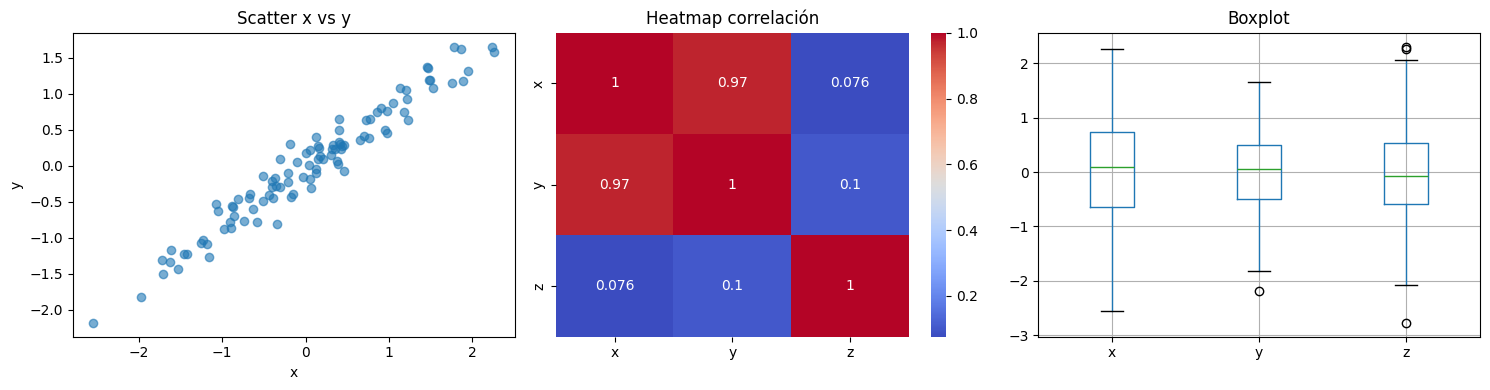

In [39]:
# ── Práctica guiada 4.3 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
df = pd.DataFrame({
    "x": np.random.randn(100),
    "y": np.random.randn(100),
    "z": np.random.randn(100)
})
# Correlación artificial entre x e y
df["y"] = df["x"] * 0.8 + np.random.randn(100) * 0.2

# Resumen estadístico
print("--- describe ---")
print(df.describe())

# Matrices de correlación
print("\n--- Pearson ---")
print(df.corr(method="pearson").round(3))
print("\n--- Spearman ---")
print(df.corr(method="spearman").round(3))

# Correlación puntual
print(f"\nCorrelación x-y (Pearson): {df['x'].corr(df['y']):.3f}")

# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pairplot simplificado (scatter x vs y)
axes[0].scatter(df["x"], df["y"], alpha=0.6)
axes[0].set_title("Scatter x vs y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Heatmap de correlación
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Heatmap correlación")

# Boxplot
df.boxplot(ax=axes[2])
axes[2].set_title("Boxplot")

plt.tight_layout()
plt.show()

#### Práctica guiada 4.3b — EDA con un dataset real

El ejemplo anterior usaba datos aleatorios para ilustrar la mecánica. Un buen EDA necesita datos reales: usamos el dataset público *tips* (244 cuentas de un restaurante), cargado directamente con `seaborn.load_dataset`.

--- head ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

--- info ---
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

--- describe ---
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.78

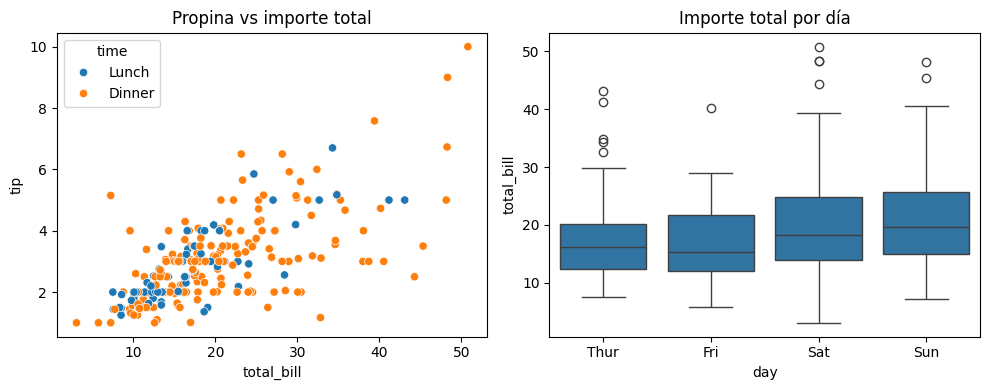

In [40]:
# ── Práctica guiada 4.3b — EDA con un dataset real (propinas de restaurante) ─
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 'tips' es un dataset real y público (244 cuentas de un restaurante de EE.UU.)
df = sns.load_dataset("tips")

print("--- head ---")
print(df.head())
print("\n--- info ---")
df.info()
print("\n--- describe ---")
print(df.describe())

# Preguntas de EDA: ¿la propina depende del importe total? ¿del tamaño del grupo?
print("\nCorrelación (Pearson):")
print(df[["total_bill", "tip", "size"]].corr())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", ax=axes[0])
axes[0].set_title("Propina vs importe total")

sns.boxplot(data=df, x="day", y="total_bill", ax=axes[1])
axes[1].set_title("Importe total por día")

plt.tight_layout()
plt.show()

### 4.3.4 Test

1. La media es sensible a…  
   a) nada &nbsp; b) outliers &nbsp; c) moda &nbsp; d) mediana

2. La mediana es…  
   a) promedio &nbsp; b) valor central &nbsp; c) moda &nbsp; d) varianza

3. Pearson mide…  
   a) monotónica &nbsp; b) lineal &nbsp; c) ordinal &nbsp; d) nada

4. Spearman mide…  
   a) lineal &nbsp; b) monotónica &nbsp; c) ordinal &nbsp; d) nada

5. Un heatmap de correlación muestra…  
   a) valores &nbsp; b) relaciones &nbsp; c) tipos &nbsp; d) nulos

6. Un boxplot detecta…  
   a) media &nbsp; b) outliers &nbsp; c) moda &nbsp; d) nada

7. `describe` incluye…  
   a) solo media &nbsp; b) estadísticas &nbsp; c) tipos &nbsp; d) nulos

8. La varianza mide…  
   a) centro &nbsp; b) dispersión &nbsp; c) forma &nbsp; d) nada

9. Un patrón estacional…  
   a) tendencia &nbsp; b) repetición periódica &nbsp; c) outlier &nbsp; d) nulo

10. EDA sirve para…  
    a) modelar &nbsp; b) entender datos &nbsp; c) desplegar &nbsp; d) nada

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 4.3 — resumen_estadistico

Escribe 'resumen_estadistico(df, columna)' que devuelva un diccionario con las claves 'media', 'mediana' y 'desviacion' (desviación estándar) de esa columna.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [41]:
import pandas as pd

def resumen_estadistico(df: pd.DataFrame, columna: str) -> dict:
    # TODO: implementa aquí tu solución
    ...

import pandas as pd
_df = pd.DataFrame({"x": [1, 2, 3, 4, 5]})
try:
    _r = resumen_estadistico(_df, "x")
    _ok = 0
    if isinstance(_r, dict) and set(["media", "mediana", "desviacion"]).issubset(_r.keys()):
        _ok += 1; print("✓ Claves correctas presentes")
    else:
        print(f"✗ Faltan claves esperadas, obtenido {_r}")
    if _r.get("media") == 3.0 and _r.get("mediana") == 3.0:
        _ok += 1; print("✓ media y mediana correctas")
    else:
        print(f"✗ media/mediana incorrectas: {_r}")
    print(f"\nResultado: {_ok}/2 casos correctos")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")

✗ Faltan claves esperadas, obtenido None
✗ Error de ejecución: AttributeError: 'NoneType' object has no attribute 'get'


---
## Epígrafe 4.4 — Desarrollo de modelos en Python

### 4.4.1 Conceptos clave

- **Regresión lineal**: `y = a + bx + e`.
- **Regresión no lineal**: polinómica, logística, árboles.
- **Muestreo**: train/test split, validación cruzada.
- **Predicción**: `predict`, métricas (MSE, RMSE, R²).
- **Precisión y validez**: sobreajuste, subajuste.

### 4.4.2 Explicación razonada

**Regresión lineal**: modela relación entre variable dependiente y una o más independientes. Se ajusta minimizando suma de cuadrados. `scikit-learn` o `statsmodels`.

**No lineal**: cuando la relación no es lineal. Se usan transformaciones, polinomios, árboles, SVM, redes.

**Muestreo**: dividir en train/test. Validación cruzada (k-fold) para estimar rendimiento.

**Métricas**:
- MSE: error cuadrático medio.
- RMSE: raíz del MSE.
- R²: proporción de varianza explicada.

**Sobreajuste**: modelo memoriza train, mal en test. Soluciones: regularización, más datos, modelo más simple.

=== Regresión lineal ===
Coeficiente: 1.987
Intercepto:  1.322
MSE:         1.043
R²:          0.972

=== Regresión polinómica (grado 2) ===
R² (test):   0.972


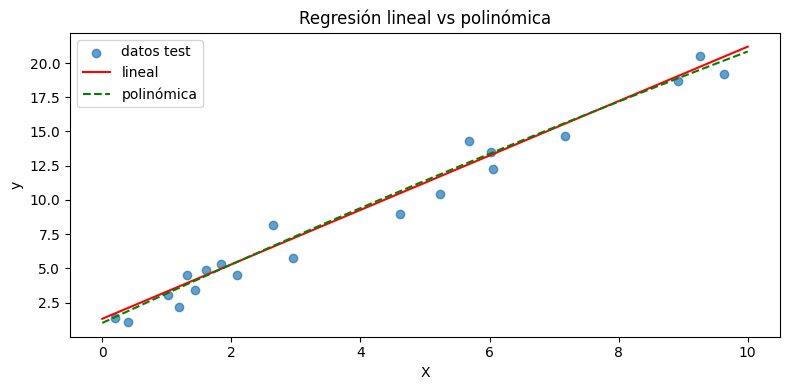

In [42]:
# ── Práctica guiada 4.4 ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Datos sintéticos
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 2 * X.squeeze() + 1 + np.random.randn(100)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Modelo lineal
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Regresión lineal ===")
print(f"Coeficiente: {model.coef_[0]:.3f}")
print(f"Intercepto:  {model.intercept_:.3f}")
print(f"MSE:         {mean_squared_error(y_test, y_pred):.3f}")
print(f"R²:          {r2_score(y_test, y_pred):.3f}")

# Modelo polinómico (no lineal)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X_train, y_train)
print(f"\n=== Regresión polinómica (grado 2) ===")
print(f"R² (test):   {poly.score(X_test, y_test):.3f}")

# Visualización
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.figure(figsize=(8, 4))
plt.scatter(X_test, y_test, label="datos test", alpha=0.7)
plt.plot(X_plot, model.predict(X_plot), label="lineal", color="red")
plt.plot(X_plot, poly.predict(X_plot), label="polinómica", color="green", linestyle="--")
plt.legend()
plt.title("Regresión lineal vs polinómica")
plt.xlabel("X")
plt.ylabel("y")
plt.tight_layout()
plt.show()

### 4.4.4 Test

1. Regresión lineal ajusta…  
   a) polinomio &nbsp; b) recta &nbsp; c) árbol &nbsp; d) red

2. `train_test_split` sirve para…  
   a) normalizar &nbsp; b) dividir &nbsp; c) modelar &nbsp; d) predecir

3. MSE mide…  
   a) error absoluto &nbsp; b) error cuadrático &nbsp; c) R² &nbsp; d) nada

4. R² mide…  
   a) error &nbsp; b) varianza explicada &nbsp; c) media &nbsp; d) nada

5. Sobreajuste es…  
   a) buen test &nbsp; b) mal test &nbsp; c) train=test &nbsp; d) nada

6. Validación cruzada…  
   a) 1 split &nbsp; b) k splits &nbsp; c) sin split &nbsp; d) nada

7. Regresión logística…  
   a) lineal &nbsp; b) clasificación &nbsp; c) cluster &nbsp; d) nada

8. Polinómica es…  
   a) lineal &nbsp; b) no lineal &nbsp; c) árbol &nbsp; d) red

9. `predict` devuelve…  
   a) modelo &nbsp; b) predicciones &nbsp; c) métricas &nbsp; d) datos

10. Regularización evita…  
    a) subajuste &nbsp; b) sobreajuste &nbsp; c) nada &nbsp; d) todo

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto 4.4 — entrenar_regresion

Escribe 'entrenar_regresion(X, y)' que entrene un 'LinearRegression' de scikit-learn con los datos dados y devuelva el MODELO YA ENTRENADO (con .fit ya llamado).

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [43]:
from sklearn.linear_model import LinearRegression

def entrenar_regresion(X, y):
    # TODO: crea un LinearRegression, entrénalo con X, y devuélvelo entrenado
    ...

import numpy as np
_X = np.array([[1], [2], [3], [4]])
_y = np.array([2, 4, 6, 8])  # relación lineal perfecta y = 2x
try:
    _modelo = entrenar_regresion(_X, _y)
    _pred = _modelo.predict([[5]])[0]
    if abs(_pred - 10) < 0.01:
        print(f"✓ Modelo entrenado correctamente, predicción para x=5: {_pred:.2f} (esperado ≈10)")
    else:
        print(f"✗ Predicción incorrecta: {_pred} (esperado ≈10)")
except Exception as e:
    print(f"✗ Error de ejecución: {type(e).__name__}: {e}")

✗ Error de ejecución: AttributeError: 'NoneType' object has no attribute 'predict'


---
# MÓDULO COMPLEMENTARIO — PYTHON DESDE LA CONSOLA INTERACTIVA (REPL)

Este módulo enseña a trabajar con el intérprete interactivo de Python desde **CMD o PowerShell** en Windows.
Cada sección incluye una explicación y una celda ejecutable equivalente al comportamiento del REPL.

> **Nota**: en el REPL real los prompts `>>>` y `...` los muestra Python. Aquí, en el notebook, el kernel ejecuta el código directamente sin necesidad de esos prefijos.

## Sección 1 — Entrar en Python y los prompts `>>>` y `...`

Desde **CMD** o **PowerShell** escribe:

```text
C:\Users\grach> python
Python 3.x.x ...
>>>
```

A partir de ese momento ya no estás en Windows: estás escribiendo **código Python**.

### `>>>` — prompt principal
Python espera una **nueva instrucción**.

### `...` — prompt de continuación
Python sabe que la instrucción **aún no ha terminado** y espera más código. Aparece tras `:` (bloques `if`, `for`, `def`, `class`…).  
Para cerrar el bloque pulsa **Enter en una línea vacía**.

```text
>>> if 10 > 5:
...     print("Es mayor")
...                        ← Enter vacío aquí
Es mayor
>>>
```

### Característica especial del REPL
Las expresiones **imprimen su resultado automáticamente**, sin `print()`:

```python
>>> 2 + 3
5
>>> nombre = "Jose"   # asignación → no imprime
>>> nombre            # evaluar variable → sí imprime
'Jose'
```

### Salir del REPL
```python
>>> exit()   # o quit()
```
También **Ctrl+Z + Enter** en CMD / **Ctrl+D** en Linux/macOS.

In [44]:
# ── Práctica 1a — Expresiones: el REPL muestra el resultado automáticamente ──
2 + 3

5

In [45]:
# ── Práctica 1b — Asignación vs evaluación ───────────────────────────────────
nombre = "Jose"   # asignación: no imprime nada
nombre            # evaluar: imprime el valor

'Jose'

In [46]:
# ── Práctica 1c — Bloque if (equivalente al prompt ...) ──────────────────────
if 10 > 5:
    print("Es mayor")   # Enter vacío después del bloque = se ejecuta

Es mayor


## Sección 2 — `:`, indentación y `;`

### El `:`
Abre un **bloque de código**. Lo usan: `if`, `elif`, `else`, `for`, `while`, `def`, `class`, `try`, `except`, `with`.

```text
instrucción_que_abre_bloque:
    código del bloque  ← 4 espacios
```

### Indentación
Python usa la **sangría** para delimitar bloques. Un error de indentación produce `IndentationError`.

```python
# Correcto
if 10 > 5:
    print("A")   # 4 espacios
    print("B")

# Incorrecto → IndentationError
if 10 > 5:
print("A")       # sin sangría
```

### `;` — varias instrucciones en una línea
Útil en el REPL para pruebas rápidas, **no recomendado** en código de producción:

```python
>>> x = 10; y = 20; print(x + y)
30
```

### Instrucciones de bloque en una sola línea
```python
>>> if 10 > 5: print("Mayor")
Mayor
>>> for x in [1, 2, 3]: print(x)
1
2
3
```

In [47]:
# ── Práctica 2 — Dos puntos, indentación y punto y coma ──────────────────────

# Bloque if con indentación correcta
if 10 > 5:
    print("A")
    print("B")

# Punto y coma: varias instrucciones en una línea
x = 10; y = 20; print(x + y)

# Bloque completo en una sola línea
if 10 > 5: print("Mayor")
for x in [1, 2, 3]: print(x)

# Descomenta para ver IndentationError:
# if True:
# print("error")  # ← sin sangría → IndentationError

A
B
30
Mayor
1
2
3


## Sección 3 — `type()`, `dir()`, `help()` e `isinstance()`

Estas funciones convierten el REPL en una **herramienta de exploración** del lenguaje.

### `type(objeto)` — ¿qué tipo es esto?
```python
>>> type(10)        → <class 'int'>
>>> type(10.5)      → <class 'float'>
>>> type("Hola")   → <class 'str'>
>>> type(True)      → <class 'bool'>
>>> type([1,2,3])   → <class 'list'>
```

### `dir(objeto)` — ¿qué puedo hacer con esto?
Lista todos los atributos y métodos disponibles:
```python
>>> dir("Hola")  → [..., 'upper', 'lower', 'replace', 'split', ...]
>>> dir()        → variables definidas en el entorno actual
```

### `help(objeto)` — documentación completa
```python
>>> help(str.upper)   # pulsa q para salir
>>> help(print)
```

### `isinstance(objeto, clase)` — ¿pertenece a esta clase?
```python
>>> isinstance(10, int)      → True
>>> isinstance("Hola", str)  → True
```

### Flujo de trabajo con el REPL
```text
objeto → dir(objeto) → buscar método → objeto.método() → help(método)
```

In [48]:
# ── Práctica 3 — type(), dir(), help(), isinstance() ─────────────────────────

# type() con distintos objetos
for valor in [10, 10.5, "Hola", True, [1,2,3], {"a":1}, (1,2), {1,2}]:
    print(f"type({repr(valor):<15}) → {type(valor)}")

print()

# dir() sobre un string (filtramos __dunder__ para mayor claridad)
texto = "Hola"
metodos_str = [m for m in dir(texto) if not m.startswith("_")]
print("Métodos de str:", metodos_str)

print()

# Usar métodos descubiertos con dir()
print(texto.upper())
print(texto.replace("H", "J"))
print(texto.lower())

print()

# isinstance()
print(isinstance(10, int))       # True
print(isinstance("Hola", str))   # True
print(isinstance(10, float))     # False
print(isinstance(True, int))     # True — bool es subclase de int

print()

# help() capturado como texto
import pydoc
print(pydoc.render_doc(str.upper, renderer=pydoc.plaintext))

type(10             ) → <class 'int'>
type(10.5           ) → <class 'float'>
type('Hola'         ) → <class 'str'>
type(True           ) → <class 'bool'>
type([1, 2, 3]      ) → <class 'list'>
type({'a': 1}       ) → <class 'dict'>
type((1, 2)         ) → <class 'tuple'>
type({1, 2}         ) → <class 'set'>

Métodos de str: ['capitalize', 'casefold', 'center', 'count', 'encode', 'endswith', 'expandtabs', 'find', 'format', 'format_map', 'index', 'isalnum', 'isalpha', 'isascii', 'isdecimal', 'isdigit', 'isidentifier', 'islower', 'isnumeric', 'isprintable', 'isspace', 'istitle', 'isupper', 'join', 'ljust', 'lower', 'lstrip', 'maketrans', 'partition', 'removeprefix', 'removesuffix', 'replace', 'rfind', 'rindex', 'rjust', 'rpartition', 'rsplit', 'rstrip', 'split', 'splitlines', 'startswith', 'strip', 'swapcase', 'title', 'translate', 'upper', 'zfill']

HOLA
Jola
hola

True
True
False
True

Python Library Documentation: method_descriptor

upper(self, /) unbound builtins.str method
    Retu

## Sección 4 — Variables, tipado dinámico y `_`

Una variable se crea **simplemente asignando** un valor. No hay que declarar el tipo:

```python
>>> nombre = "Jose"
>>> edad = 30
>>> altura = 1.75
```

El tipo puede **cambiar** a lo largo del programa (tipado dinámico):

```python
>>> x = 10       # int
>>> x = "Hola"  # str
>>> x = 3.14     # float
```

Pero las operaciones entre tipos incompatibles lanzan `TypeError` (tipado **fuerte**):

```python
>>> "Hola" + 5   # TypeError
```

### `_` — el último resultado en el REPL

En la consola interactiva, `_` guarda el **último valor evaluado**:

```python
>>> 10 + 20
30
>>> _ + 5
35
```

> En el notebook `_` funciona igual: contiene la última expresión evaluada de la celda anterior.

In [49]:
# ── Práctica 4a — Variables y tipado dinámico ─────────────────────────────────

nombre = "Jose"
edad   = 30
altura = 1.75
print(nombre, edad, altura)
print(type(nombre), type(edad), type(altura))

# Tipado dinámico: la variable cambia de tipo
x = 10;      print(f"x = {x!r:<10}  tipo: {type(x).__name__}")
x = "Hola";  print(f"x = {x!r:<10}  tipo: {type(x).__name__}")
x = 3.14;    print(f"x = {x!r:<10}  tipo: {type(x).__name__}")

# TypeError por operación incompatible
try:
    "Hola" + 5
except TypeError as e:
    print(f"TypeError: {e}")

# Expresión para que _ la recoja
10 + 20

Jose 30 1.75
<class 'str'> <class 'int'> <class 'float'>
x = 10          tipo: int
x = 'Hola'      tipo: str
x = 3.14        tipo: float
TypeError: can only concatenate str (not "int") to str


30

In [50]:
# ── Práctica 4b — _ contiene el último resultado ─────────────────────────────
# _ tiene 30 (resultado de la última expresión de la celda anterior)
_ + 5

35

## Sección 5 — Strings: comillas, `'''`, docstrings, `#` y f-strings

### Comillas simples y dobles — equivalentes
```python
>>> nombre = 'Jose'
>>> nombre = "Jose"
```

### Strings multilínea con `'''` o `"""`
```python
>>> texto = '''Hola
... esto es
... varias líneas'''
>>> print(texto)
```

### `'''` como docstring
Cuando aparece justo **dentro** de una función o clase, es documentación accesible con `help()`:
```python
def saludar():
    '''Esta función muestra un saludo.'''
    print("Hola")

help(saludar)
```

### Diferencia entre `#` y `'''`
- `#` → comentario real, Python lo ignora completamente.
- `'''...'''` → objeto string; como docstring documenta, pero sigue siendo un valor.

### f-strings
```python
>>> nombre = "Jose"; edad = 50
>>> print(f"Me llamo {nombre} y tengo {edad} años")
>>> print(f"El año que viene tendré {edad + 1}")   # expresión
>>> print(f"Precio: {19.9876:.2f} €")              # 2 decimales
>>> print(f"{0.8567:.1%}")                          # porcentaje
```

In [51]:
# ── Práctica 5 — Strings, ''', docstrings, comentarios y f-strings ────────────

# Comillas equivalentes
a = 'Jose'
b = "Jose"
print("¿Son iguales?", a == b)   # True

# Multilínea con '''
texto = '''Hola
esto es
una cadena
de varias líneas'''
print(texto)
print("Tipo:", type(texto))

# Docstring accesible con __doc__
def saludar():
    '''Esta función muestra un saludo. Ejemplo de docstring.'''
    print("Hola")

print("Docstring:", saludar.__doc__)
saludar()

# Comentario (Python lo ignora)
edad = 50  # Edad del usuario

# f-strings
nombre = "Jose"
print(f"Me llamo {nombre} y tengo {edad} años")
print(f"El año que viene tendré {edad + 1}")

# Formateo numérico
precio = 19.9876
print(f"Precio: {precio:.2f} €")
porcentaje = 0.8567
print(f"Porcentaje: {porcentaje:.1%}")

# Expresión dentro de f-string
a, b = 10, 20
print(f"La suma de {a} y {b} es {a + b}")

¿Son iguales? True
Hola
esto es
una cadena
de varias líneas
Tipo: <class 'str'>
Docstring: Esta función muestra un saludo. Ejemplo de docstring.
Hola
Me llamo Jose y tengo 50 años
El año que viene tendré 51
Precio: 19.99 €
Porcentaje: 85.7%
La suma de 10 y 20 es 30


## Sección 6 — `if / elif / else`, `pass` y `while`

### `if / elif / else`
```python
>>> nota = 7
>>> if nota >= 9:
...     print("Excelente")
... elif nota >= 5:
...     print("Aprobado")
... else:
...     print("Suspenso")
...
Aprobado
```
`elif` y `else` también llevan `:` y deben estar **al mismo nivel** que el `if`.

### `pass` — marcador de posición
`pass` significa *no hagas nada*. Python exige que todo bloque tenga al menos una instrucción:
```python
def calcular():
    pass        # implementaré esto más tarde

class MiClase:
    pass
```

### `while`
```python
>>> contador = 0
>>> while contador < 3:
...     print(contador)
...     contador += 1
...
0
1
2
```
Para interrumpir un bucle infinito en el REPL real: **Ctrl+C** → `KeyboardInterrupt`.  
En el notebook usa el botón **■ (Interrupt kernel)**.

In [52]:
# ── Práctica 6 — if/elif/else, pass y while ───────────────────────────────────

# if / elif / else
nota = 7
if nota >= 9:
    print("Excelente")
elif nota >= 5:
    print("Aprobado")
else:
    print("Suspenso")

# Varios valores
for n in [10, 7, 3, 9, 4]:
    if n >= 9:
        cat = "Excelente"
    elif n >= 5:
        cat = "Aprobado"
    else:
        cat = "Suspenso"
    print(f"  nota {n} → {cat}")

print()

# pass como marcador de posición
def calcular():
    pass   # TODO: implementar

class MiClase:
    pass

print("calcular():", calcular())   # None — existe pero no hace nada
print("MiClase():  ", MiClase())

print()

# while
contador = 0
while contador < 3:
    print(f"  contador = {contador}")
    contador += 1

# while con break (equivale a Ctrl+C controlado)
i = 0
while True:
    if i >= 4:
        break
    print(f"  i = {i}")
    i += 1

Aprobado
  nota 10 → Excelente
  nota 7 → Aprobado
  nota 3 → Suspenso
  nota 9 → Excelente
  nota 4 → Suspenso

calcular(): None
MiClase():   <__main__.MiClase object at 0x7fd3997de540>

  contador = 0
  contador = 1
  contador = 2
  i = 0
  i = 1
  i = 2
  i = 3


## Sección 7 — Funciones: `def`, parámetros, `return`

### Definir y llamar
```python
>>> def saludar():
...     print("Hola")
...
>>> saludar()
Hola
```

### Con parámetros
```python
>>> def saludar(nombre):
...     print(f"Hola {nombre}")
...
>>> saludar("Jose")
Hola Jose
```

### Con `return`
```python
>>> def sumar(a, b):
...     return a + b
...
>>> resultado = sumar(10, 20)
>>> resultado
30
```

### `dir()` sobre una función
```python
>>> dir(sumar)   # muestra __name__, __doc__, __code__, etc.
```

In [53]:
# ── Práctica 7 — def, parámetros, return ──────────────────────────────────────

# Sin parámetros
def saludar():
    print("Hola")

saludar()

# Con parámetro
def saludar_a(nombre):
    print(f"Hola {nombre}")

saludar_a("Jose")

# Con return
def sumar(a, b):
    return a + b

resultado = sumar(10, 20)
print("Resultado:", resultado)

# Con docstring y parámetro por defecto
def presentar(nombre, edad, ciudad="desconocida"):
    '''Imprime una presentación del usuario.'''
    print(f"Me llamo {nombre}, tengo {edad} años y soy de {ciudad}")

presentar("Jose", 50)
presentar("Ana", 30, "Madrid")
print("Docstring:", presentar.__doc__)

# dir() sobre una función
atributos_fun = [a for a in dir(sumar) if not a.startswith("__")]
print("Atributos de sumar():", atributos_fun)

Hola
Hola Jose
Resultado: 30
Me llamo Jose, tengo 50 años y soy de desconocida
Me llamo Ana, tengo 30 años y soy de Madrid
Docstring: Imprime una presentación del usuario.
Atributos de sumar(): []


## Sección 8 — Clases desde el REPL

Se pueden definir clases directamente en la consola:

```python
>>> class Persona:
...     def __init__(self, nombre, edad):
...         self.nombre = nombre
...         self.edad = edad
...
...     def saludar(self):
...         print(f"Hola, soy {self.nombre}")
...
>>> p = Persona("Jose", 50)
>>> p.nombre
'Jose'
>>> p.saludar()
Hola, soy Jose
>>> type(p)
<class '__main__.Persona'>
>>> isinstance(p, Persona)
True
>>> dir(p)    # incluye nombre, saludar, ...
```

Jerarquía de capas:

```text
class Persona
  └── __init__  → inicializa atributos (nombre, edad)
  └── saludar   → método de instancia

p = Persona("Jose", 50)   → instancia
  └── p.nombre            → atributo
  └── p.saludar()         → llamada a método
```

In [54]:
# ── Práctica 8 — Clases en el REPL ───────────────────────────────────────────

class Persona:
    def __init__(self, nombre, edad):
        self.nombre = nombre
        self.edad   = edad

    def saludar(self):
        print(f"Hola, soy {self.nombre}")

    def presentar(self):
        '''Devuelve una presentación completa.'''
        return f"Me llamo {self.nombre} y tengo {self.edad} años"

# Crear instancia
p = Persona("Jose", 50)

# Acceder a atributos
print("nombre:", p.nombre)
print("edad:  ", p.edad)

# Llamar a métodos
p.saludar()
print(p.presentar())

# type() e isinstance()
print("type:", type(p))
print("isinstance(p, Persona):", isinstance(p, Persona))
print("isinstance(p, object): ", isinstance(p, object))  # toda clase hereda de object

# dir() — atributos propios sin dunder
atributos = [a for a in dir(p) if not a.startswith("_")]
print("dir(p) sin dunder:", atributos)

# Varias instancias
personas = [Persona("Ana", 30), Persona("Luis", 25), Persona("Eva", 45)]
for per in personas:
    print(f"  {per.presentar()}")

nombre: Jose
edad:   50
Hola, soy Jose
Me llamo Jose y tengo 50 años
type: <class '__main__.Persona'>
isinstance(p, Persona): True
isinstance(p, object):  True
dir(p) sin dunder: ['edad', 'nombre', 'presentar', 'saludar']
  Me llamo Ana y tengo 30 años
  Me llamo Luis y tengo 25 años
  Me llamo Eva y tengo 45 años


## Sección 9 — TAB, cursores, `Ctrl+C` y chuleta completa

### TAB — autocompletado (solo en REPL real y en el notebook)
```text
>>> texto = "Hola"
>>> texto.      ← pulsa TAB
```
Muestra todos los métodos disponibles. En VS Code/Kiro también funciona con `Ctrl+Space`.

### ↑ ↓ — historial de comandos
```text
>>> nombre = "Jose"
>>> edad = 50
>>> print(nombre)
↑  →  recuperas print(nombre)
↑  →  recuperas edad = 50
```
Puedes editar la línea recuperada con **← →** antes de ejecutarla.

### `Ctrl+C` — interrumpir
```python
>>> while True:
...     print("Hola")
KeyboardInterrupt    ← Ctrl+C
>>>
```
En el notebook usa **■ (Interrupt kernel)**.

---

### Chuleta completa del REPL

| Elemento | Significado |
|---|---|
| `>>>` | Python espera nueva instrucción |
| `...` | Python espera continuación del bloque |
| `:` | Abre un bloque |
| 4 espacios | Indentación obligatoria |
| `;` | Varias instrucciones en una línea |
| `.` | Accede a atributos/métodos |
| `TAB` | Autocompletado |
| `↑ ↓` | Historial de comandos |
| `← →` | Moverse por la línea |
| `Ctrl+C` | Interrumpir → `KeyboardInterrupt` |
| `exit()` / `quit()` | Salir de Python |
| `type(x)` | Tipo del objeto |
| `dir(x)` | Atributos y métodos |
| `help(x)` | Documentación |
| `isinstance(x, C)` | Pertenencia a clase |
| `_` | Último resultado evaluado |
| `#` | Comentario |
| `'''...'''` | String multilínea / docstring |
| `f"...{expr}"` | String formateado |
| `pass` | No hacer nada (marcador) |
| `if / elif / else` | Condicional |
| `for / while` | Bucles |
| `def` | Definir función |
| `class` | Definir clase |
| `return` | Devolver resultado |

In [55]:
# ── Práctica 9 — Sesión REPL completa (sección 44 del tutorial) ──────────────

# Variables y f-strings
nombre = "Jose"
edad   = 50
print(f"Hola, me llamo {nombre}")
print(f"Tengo {edad} años")

# if/else
if edad >= 18:
    print("Soy mayor de edad")
else:
    print("Soy menor de edad")

# for con f-string
for i in range(3):
    print(f"Iteración {i}")

# Función con docstring
def presentar(nombre, edad):
    '''Imprime una presentación.'''
    print(f"Me llamo {nombre} y tengo {edad} años")

presentar(nombre, edad)

# Clase
class Persona:
    def __init__(self, nombre, edad):
        self.nombre = nombre
        self.edad   = edad
    def __repr__(self):
        return f"Persona({self.nombre!r}, {self.edad})"

p = Persona(nombre, edad)
print(p)
print("type:      ", type(p))
print("isinstance:", isinstance(p, Persona))

# _ — evaluamos una expresión para que _ la recoja
10 + 20

Hola, me llamo Jose
Tengo 50 años
Soy mayor de edad
Iteración 0
Iteración 1
Iteración 2
Me llamo Jose y tengo 50 años
Persona('Jose', 50)
type:       <class '__main__.Persona'>
isinstance: True


30

In [56]:
# _ contiene 30 de la celda anterior
print(f"El último resultado fue {_}, y sumando 5 = {_ + 5}")

El último resultado fue 30, y sumando 5 = 35


---
# MÓDULO ADICIONAL — Fundamentos avanzados de Python

Estos epígrafes no aparecen de forma explícita en el currículo oficial (RD 566/2024) pero son
imprescindibles en cualquier puesto de desarrollo con Python: **comprehensions, generadores,
decoradores, gestores de contexto, expresiones regulares y tipado estático**. Se añaden aquí
como refuerzo transversal, útiles sobre todo para los módulos 5099, 5100 y 5101.

---
# MÓDULO B — Fundamentos de tipos de datos, variables y cadenas

Antes de entrar en POO y en las prácticas avanzadas, este módulo refuerza la base que
sostiene todo lo demás: cómo se captura la entrada del usuario, cómo se nombran las
cosas en Python, cómo funcionan el ámbito y la mutabilidad, las estructuras de datos
fundamentales (listas, tuplas, conjuntos, `range`, diccionarios) y las distintas formas
de construir cadenas de texto.

## B.1 — input() y conversión de tipos

### Conceptos clave

- `input()` **siempre** devuelve un `str`, incluso si el usuario escribe un número: hay que convertirlo explícitamente (`int()`, `float()`).
- En un notebook, `input()` detiene la ejecución esperando texto por teclado; aquí lo simulamos para que la celda se pueda ejecutar sola.
- Patrón habitual: `int(input("..."))`, con `try/except ValueError` si la entrada puede no ser válida.

### Errores frecuentes

- Olvidar convertir el resultado y sumarlo directamente a un número (`TypeError`).
- No validar la entrada del usuario antes de usarla (confiar ciegamente en `input()`).

In [57]:
# ── B.1 — La función input() ──────────────────────────────────────────────────
# input() SIEMPRE devuelve un string, aunque el usuario escriba solo números.
# En un notebook, input() pide el dato de forma interactiva; para que esta celda
# se pueda ejecutar sin intervención (por ejemplo en un corrector automático),
# simulamos la entrada con una lista de valores predefinidos.

entradas_simuladas = iter(["Ana", "29", "s"])

def input_simulado(prompt=""):
    valor = next(entradas_simuladas)
    print(f"{prompt}{valor}")  # mostramos qué "escribiría" el usuario
    return valor

nombre = input_simulado("¿Cómo te llamas? ")
edad_texto = input_simulado("¿Qué edad tienes? ")
acepta = input_simulado("¿Aceptas los términos? (s/n) ")

print(f"\ntipo de 'nombre': {type(nombre)}")
print(f"tipo de 'edad_texto': {type(edad_texto)}")  # str, NO int

# Error clásico: sumar directamente el resultado de input() sin convertir
try:
    edad_en_5_anios = edad_texto + 5   # TypeError: no se puede sumar str + int
except TypeError as e:
    print(f"\n✗ Error típico: {e}")

# Forma correcta: convertir explícitamente
edad = int(edad_texto)
print(f"✓ Dentro de 5 años tendrás {edad + 5} años")

acepta_bool = acepta.strip().lower() in ("s", "si", "sí", "y", "yes")
print(f"¿Acepta? {acepta_bool} (tipo {type(acepta_bool).__name__})")

# En un script/notebook real (interactivo), sería simplemente:
#   nombre = input("¿Cómo te llamas? ")
#   edad = int(input("¿Qué edad tienes? "))

¿Cómo te llamas? Ana
¿Qué edad tienes? 29
¿Aceptas los términos? (s/n) s

tipo de 'nombre': <class 'str'>
tipo de 'edad_texto': <class 'str'>

✗ Error típico: can only concatenate str (not "int") to str
✓ Dentro de 5 años tendrás 34 años
¿Acepta? True (tipo bool)


### B.1 Test

1. `input()` siempre devuelve… b) un `str`
2. Para leer un número hay que… b) convertir explícitamente con `int()`/`float()`
3. `input("Edad: ")` muestra el texto… b) como mensaje (prompt) al usuario
4. Sumar directamente `input()` a un `int` provoca… b) `TypeError`
5. Validar la entrada de `input()` es… b) responsabilidad del programador
6. `input()` en un notebook… b) espera una respuesta del usuario en una celda interactiva
7. Simular `input()` con una lista de valores predefinidos sirve para… b) probar código sin intervención manual
8. `int(input("..."))` puede lanzar… b) `ValueError` si el texto no es numérico
9. `input()` NUNCA devuelve… b) `int` o `float` directamente
10. Buena práctica al leer datos del usuario… b) validar y convertir antes de usarlos

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.2 — Convenciones de nombrado (snake_case, PascalCase, UPPER_CASE)

### Conceptos clave

- **snake_case**: variables, funciones y métodos (`edad_usuario`, `calcular_total`). Es el estándar de PEP 8 para estos casos.
- **PascalCase**: nombres de **clases** (`CuentaBancaria`, `GestorPedidos`), NO de variables.
- **UPPER_CASE**: constantes por convención (`MAX_INTENTOS`, `PI`); Python no las protege realmente, es solo un acuerdo entre programadores.
- `_prefijo` / `__prefijo`: indican uso interno/privado por convención (o *name mangling* con doble guion bajo en clases).

### Errores frecuentes

- Usar PascalCase o camelCase para variables (válido en Python, pero rompe la convención y confunde: PascalCase se reserva para clases).
- Pensar que `MAX_INTENTOS` es inmutable por estar en mayúsculas: Python no lo impide, es solo una convención.

In [58]:
# ── B.2 — Convenciones de nombrado de identificadores ─────────────────────────
# PEP 8 (la guía de estilo oficial de Python) define, entre otras:
#   snake_case   -> variables, funciones y métodos       (edad_usuario, calcular_total)
#   PascalCase   -> nombres de CLASES                     (CuentaBancaria, Circulo)
#   UPPER_CASE   -> constantes                             (PI, MAX_INTENTOS)
#   _prefijo     -> uso "interno"/privado por convención   (_cache, __saldo)
#
# Nota importante: PascalCase en Python se usa para CLASES, no para variables.
# Una variable en PascalCase (p. ej. 'NombreUsuario') es válida sintácticamente,
# pero rompe la convención y confunde: al leer 'NombreUsuario' cualquier
# programador de Python esperará que sea una clase, no un dato.

# --- snake_case correcto para variables y funciones ---
nombre_usuario = "Marta"
numero_de_intentos = 3

def calcular_precio_total(precio_unitario, cantidad):
    return precio_unitario * cantidad

print(calcular_precio_total(4.5, 3))

# --- PascalCase correcto: nombres de clase ---
class GestorPedidos:
    pass

# --- UPPER_CASE correcto: constantes (por convención; Python no las protege) ---
MAX_INTENTOS = 3
PI = 3.14159

# --- Ejemplo de lo que NO se debe hacer (anti-patrón, solo para ilustrar) ---
NombreUsuario = "Marta"   # ⚠ variable en PascalCase: válido, pero mala práctica
nombreUsuario = "Marta"   # ⚠ camelCase: válido, pero no es el estilo de Python (sí de JS/Java)

print("\nComparación de estilos para el MISMO dato:")
print("  snake_case (recomendado):", nombre_usuario)
print("  PascalCase (desaconsejado en variables):", NombreUsuario)
print("  camelCase (no es el estilo de Python):", nombreUsuario)

# Verificación con una herramienta real de estilo: 'pycodestyle' (implementa PEP 8)
try:
    import pycodestyle
    print("\npycodestyle disponible: se podría analizar un fichero .py con 'pycodestyle archivo.py'")
except ImportError:
    print("\n(pycodestyle no está instalado; instálalo con 'pip install pycodestyle' para comprobar estilo automáticamente)")

13.5

Comparación de estilos para el MISMO dato:
  snake_case (recomendado): Marta
  PascalCase (desaconsejado en variables): Marta
  camelCase (no es el estilo de Python): Marta

(pycodestyle no está instalado; instálalo con 'pip install pycodestyle' para comprobar estilo automáticamente)


### B.2 Test

1. El estilo recomendado para variables y funciones es… b) snake_case
2. PascalCase se reserva por convención para… b) nombres de clases
3. `MAX_INTENTOS` en mayúsculas indica… b) una constante por convención
4. Python… b) no impide modificar una variable en mayúsculas
5. `nombreUsuario` (camelCase) es… b) válido mas no es el estilo estándar de Python
6. La guía de estilo oficial de Python se llama… b) PEP 8
7. Un guion bajo simple al inicio (`_variable`) indica… b) uso interno por convención
8. Doble guion bajo en un atributo de clase (`__saldo`) activa… b) *name mangling*
9. `class GestorPedidos:` sigue la convención… b) PascalCase
10. Nombrar una variable `NombreUsuario` es… b) sintácticamente válido pero mala práctica

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.3 — Variables, tipos de datos y ámbito (scope)

### Conceptos clave

- Regla **LEGB**: Python busca un nombre en el ámbito **L**ocal → **E**nclosing → **G**lobal → **B**uilt-in, en ese orden.
- `global`: dentro de una función, permite **modificar** una variable definida fuera de todas las funciones.
- `nonlocal`: permite modificar una variable del ámbito envolvente (una función anidada dentro de otra), sin llegar al global.
- Una variable creada dentro de una función es **local** por defecto y desaparece al terminar la función.

### Errores frecuentes

- Asignar una variable dentro de una función sin `global`/`nonlocal` pensando que modificará la de fuera (crea una nueva variable local).
- `UnboundLocalError`: usar una variable antes de asignarla dentro de una función donde también se le asigna un valor más adelante.

In [59]:
# ── B.3 — Variables, tipos de datos y ámbito (scope) ──────────────────────────
# Python resuelve nombres siguiendo la regla LEGB:
#   Local -> Enclosing (función que envuelve) -> Global -> Built-in

x_global = "soy global"

def funcion_externa():
    x_enclosing = "soy del ámbito envolvente"

    def funcion_interna():
        x_local = "soy local"
        print(x_local)                 # Local
        print(x_enclosing)             # Enclosing
        print(x_global)                # Global
        print(len)                     # Built-in (función incorporada)

    funcion_interna()

funcion_externa()

# --- 'global': modificar una variable global desde dentro de una función ---
contador = 0

def incrementar():
    global contador
    contador += 1

incrementar(); incrementar(); incrementar()
print("\ncontador tras 3 incrementos:", contador)

# --- 'nonlocal': modificar una variable del ámbito envolvente (no global) ---
def crear_contador():
    cuenta = 0
    def siguiente():
        nonlocal cuenta
        cuenta += 1
        return cuenta
    return siguiente

contador_independiente = crear_contador()
print("contador_independiente():", contador_independiente())
print("contador_independiente():", contador_independiente())
print("contador_independiente():", contador_independiente())

# --- Error frecuente: usar una variable local antes de asignarla, pensando que es global ---
valor = 10
def funcion_con_error():
    try:
        print(valor)      # UnboundLocalError: Python ya sabe que 'valor' se asigna
        valor = 20         #   más abajo en esta función → la trata como local
    except UnboundLocalError as e:
        print(f"✗ Error típico: {e}")

funcion_con_error()

soy local
soy del ámbito envolvente
soy global
<built-in function len>

contador tras 3 incrementos: 3
contador_independiente(): 1
contador_independiente(): 2
contador_independiente(): 3
✗ Error típico: cannot access local variable 'valor' where it is not associated with a value


### B.3 Test

1. La regla LEGB busca nombres en el orden… b) Local, Enclosing, Global, Built-in
2. `global` dentro de una función permite… b) modificar una variable global
3. `nonlocal` se usa para modificar variables del ámbito… b) envolvente (función que la contiene)
4. Una variable definida dentro de una función es, por defecto… b) local
5. `UnboundLocalError` ocurre cuando… b) se usa una variable local antes de asignarle valor
6. Sin usar `global`, asignar una variable dentro de una función… b) crea una variable local nueva
7. Las funciones incorporadas como `len()` pertenecen al ámbito… b) Built-in
8. Una variable local deja de existir… b) al terminar la ejecución de la función
9. `nonlocal` NO permite modificar… b) una variable del ámbito global
10. El ámbito de una variable determina… b) desde dónde es visible/accesible

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.4 — Tipos de datos y mutabilidad (visión de conjunto)

### Conceptos clave

- **Inmutables**: `int`, `float`, `complex`, `bool`, `str`, `tuple`, `frozenset`, `bytes`. "Modificarlos" crea un objeto nuevo.
- **Mutables**: `list`, `dict`, `set`, `bytearray`, e instancias de clases propias. Se modifican *in place* (el mismo objeto cambia).
- **Aliasing**: dos variables pueden apuntar al MISMO objeto mutable; modificarlo desde una variable afecta a la otra.
- Solo los objetos inmutables (y hashables) pueden ser clave de un `dict` o elemento de un `set`.

### Errores frecuentes

- No copiar una lista antes de modificarla, esperando que el original no cambie (`lista_b = lista_a` NO copia).
- Intentar usar una lista o un diccionario como clave de otro diccionario o elemento de un set (`TypeError: unhashable type`).

In [60]:
# ── B.4 — Tipos de datos y mutabilidad (visión de conjunto) ──────────────────
# INMUTABLES (no se pueden modificar "in place"; cualquier "cambio" crea un
# objeto nuevo): int, float, complex, bool, str, tuple, frozenset, bytes.
#
# MUTABLES (se pueden modificar in place, el objeto sigue siendo "el mismo"):
# list, dict, set, bytearray, y en general instancias de clases propias.

# --- Inmutable: un str "cambia" creando otro objeto ---
texto = "hola"
id_original = id(texto)
texto = texto.upper()          # esto crea un NUEVO string, no modifica el original
print("¿Sigue siendo el mismo objeto?", id(texto) == id_original)  # False

# --- Mutable: una lista SÍ se modifica in place ---
lista = [1, 2, 3]
id_lista_original = id(lista)
lista.append(4)                # modifica la lista existente
print("¿Sigue siendo el mismo objeto?", id(lista) == id_lista_original)  # True

# --- Consecuencia práctica: el "efecto aliasing" con tipos mutables ---
lista_a = [1, 2, 3]
lista_b = lista_a          # lista_b NO es una copia, apunta al MISMO objeto
lista_b.append(99)
print("\nlista_a:", lista_a)   # también cambia! ambas variables apuntan a la misma lista
print("lista_b:", lista_b)

# Para evitarlo, hay que copiar explícitamente
lista_c = lista_a.copy()   # o list(lista_a), o lista_a[:]
lista_c.append(1000)
print("\nlista_a tras copiar y modificar la copia:", lista_a)  # NO cambia
print("lista_c:", lista_c)

# --- Con tipos inmutables este problema NO existe ---
num_a = 10
num_b = num_a
num_b += 5   # crea un int nuevo (15) y lo asigna a num_b; num_a no se ve afectado
print("\nnum_a:", num_a, "| num_b:", num_b)

print("\nResumen de mutabilidad:")
for nombre, valor in [("int", 5), ("str", "x"), ("tuple", (1, 2)),
                       ("frozenset", frozenset([1, 2])), ("list", [1, 2]),
                       ("dict", {"a": 1}), ("set", {1, 2})]:
    # hash(valor) solo funciona en objetos inmutables (hashables)
    try:
        hash(valor)
        mutable = "inmutable (hashable)"
    except TypeError:
        mutable = "mutable (no hashable)"
    print(f"  {nombre:10s}: {mutable}")

¿Sigue siendo el mismo objeto? False
¿Sigue siendo el mismo objeto? True

lista_a: [1, 2, 3, 99]
lista_b: [1, 2, 3, 99]

lista_a tras copiar y modificar la copia: [1, 2, 3, 99]
lista_c: [1, 2, 3, 99, 1000]

num_a: 10 | num_b: 15

Resumen de mutabilidad:
  int       : inmutable (hashable)
  str       : inmutable (hashable)
  tuple     : inmutable (hashable)
  frozenset : inmutable (hashable)
  list      : mutable (no hashable)
  dict      : mutable (no hashable)
  set       : mutable (no hashable)


### B.4 Test

1. `list`, `dict` y `set` son tipos… b) mutables
2. `int`, `str` y `tuple` son tipos… b) inmutables
3. `lista_b = lista_a` hace que ambas variables… b) apunten al mismo objeto
4. Para copiar una lista de verdad se usa… b) `.copy()` o `list(...)` o `[:]`
5. Un objeto inmutable al "modificarse"… b) en realidad crea un objeto nuevo
6. Solo pueden ser clave de un `dict`… b) objetos hashables (normalmente inmutables)
7. `hash(objeto)` lanza `TypeError` en… b) objetos mutables como listas o dicts
8. El fenómeno de dos variables compartiendo el mismo objeto mutable se llama… b) aliasing
9. `frozenset` es la versión… b) inmutable de `set`
10. Modificar una lista con `.append()`… b) no crea un objeto nuevo (modifica in place)

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.5 — Listas: creación, indexado, slicing y métodos

### Conceptos clave

- Acceso por **índice** (posición), desde 0; índices negativos cuentan desde el final (`-1` = último).
- *Slicing* `lista[inicio:fin:paso]` devuelve una **nueva lista**, sin incluir el índice `fin`.
- Es **mutable**: `.append()`, `.insert()`, `.remove()`, `.pop()`, `.sort()` modifican la lista existente.
- `sorted(lista)` crea una lista nueva ordenada; `lista.sort()` ordena in place y no devuelve nada útil (`None`).

### Errores frecuentes

- Confundir `.remove(valor)` (busca por VALOR) con `.pop(indice)` (busca por POSICIÓN).
- Usar `lista.sort()` esperando que devuelva la lista ordenada (devuelve `None`).

In [61]:
# ── B.5 — Listas: creación, indexado, slicing y métodos (tipo MUTABLE) ───────
frutas = ["manzana", "pera", "plátano", "uva", "kiwi"]

# Acceso por ÍNDICE (posición), empezando en 0; índices negativos desde el final
print("frutas[0]:", frutas[0])
print("frutas[-1]:", frutas[-1])          # último elemento
print("frutas[1:3]:", frutas[1:3])        # slicing: índices 1 y 2 (el 3 no se incluye)
print("frutas[::2]:", frutas[::2])        # slicing con paso 2
print("frutas[::-1]:", frutas[::-1])      # lista invertida

# Es MUTABLE: se puede modificar sin crear una lista nueva
frutas[0] = "fresa"
frutas.append("mango")
frutas.insert(1, "naranja")
frutas.remove("uva")            # elimina por VALOR
ultimo = frutas.pop()           # elimina y devuelve el ÚLTIMO elemento (por posición)
print("\nTras modificar:", frutas)
print("Elemento sacado con pop():", ultimo)

# Errores frecuentes
try:
    print(frutas[100])
except IndexError as e:
    print(f"\n✗ IndexError: {e}")

try:
    frutas.remove("no_existe")
except ValueError as e:
    print(f"✗ ValueError: {e}")

# Métodos útiles
numeros = [5, 3, 8, 1, 9, 3]
print("\nsorted (nueva lista):", sorted(numeros))
print("numeros tras sorted() (sin cambios):", numeros)
numeros.sort()  # este SÍ modifica in place
print("numeros tras .sort() (in place):", numeros)
print("count(3):", numeros.count(3))
print("index(8):", numeros.index(8))

# Listas anidadas (matrices)
matriz = [[1, 2], [3, 4], [5, 6]]
print("\nmatriz[1][0]:", matriz[1][0])  # fila 1, columna 0

frutas[0]: manzana
frutas[-1]: kiwi
frutas[1:3]: ['pera', 'plátano']
frutas[::2]: ['manzana', 'plátano', 'kiwi']
frutas[::-1]: ['kiwi', 'uva', 'plátano', 'pera', 'manzana']

Tras modificar: ['fresa', 'naranja', 'pera', 'plátano', 'kiwi']
Elemento sacado con pop(): mango

✗ IndexError: list index out of range
✗ ValueError: list.remove(x): x not in list

sorted (nueva lista): [1, 3, 3, 5, 8, 9]
numeros tras sorted() (sin cambios): [5, 3, 8, 1, 9, 3]
numeros tras .sort() (in place): [1, 3, 3, 5, 8, 9]
count(3): 2
index(8): 4

matriz[1][0]: 3


### B.5 Test

1. `lista[-1]` accede a… b) el último elemento
2. `lista[1:3]` devuelve los índices… b) 1 y 2 (el 3 no se incluye)
3. `.remove(valor)` busca por… b) valor, no por posición
4. `.pop()` sin argumento elimina y devuelve… b) el último elemento
5. `sorted(lista)`… b) devuelve una lista nueva, no modifica la original
6. `lista.sort()`… b) ordena in place y devuelve None
7. Acceder a un índice fuera de rango lanza… b) `IndexError`
8. `lista[::-1]` produce… b) la lista invertida
9. Las listas son de tipo… b) mutable
10. `.remove()` sobre un valor que no existe lanza… b) `ValueError`

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.6 — Tuplas: inmutabilidad, empaquetado y desempaquetado

### Conceptos clave

- Se accede igual que a las listas, **por índice**: `tupla[0]`, `tupla[-1]`, slicing.
- Son **inmutables**: no se pueden modificar tras crearlas (`TypeError` al intentar asignar).
- El **desempaquetado** (`a, b = tupla`) es una de las razones por las que se usan tanto en Python.
- Al ser inmutables (y hashables si su contenido lo es), pueden usarse como clave de un `dict` o elemento de un `set`.

### Errores frecuentes

- Intentar modificar un elemento de una tupla (`tupla[0] = x`) pensando que funciona como una lista.
- Olvidar la coma al crear una tupla de un solo elemento: `(1)` es un `int`, `(1,)` es una tupla.

In [62]:
# ── B.6 — Tuplas: inmutabilidad, empaquetado y desempaquetado ────────────────
coordenada = (40.4168, -3.7038)   # Madrid: latitud, longitud

# Acceso por ÍNDICE, igual que en listas
print("latitud:", coordenada[0])
print("longitud:", coordenada[1])
print("slicing coordenada[0:1]:", coordenada[0:1])

# Es INMUTABLE: no se puede modificar
try:
    coordenada[0] = 0
except TypeError as e:
    print(f"\n✗ TypeError: {e}")

# Desempaquetado (unpacking): muy usado en Python
latitud, longitud = coordenada
print(f"\nDesempaquetado: lat={latitud}, lon={longitud}")

# Desempaquetado extendido con *
primero, *resto = (1, 2, 3, 4, 5)
print("primero:", primero, "| resto:", resto)

# Empaquetado implícito al devolver varios valores de una función
def dividir_con_resto(a, b):
    return a // b, a % b   # esto empaqueta una tupla (cociente, resto)

cociente, resto = dividir_con_resto(17, 5)   # y aquí se desempaqueta
print(f"\n17 // 5 = {cociente}, 17 % 5 = {resto}")

# ¿Por qué usar tupla en vez de lista? Cuando los datos no deben cambiar
# (coordenadas, RGB de un color, claves de un diccionario...) y para ganar
# algo de rendimiento/memoria frente a una lista equivalente.
import sys
print("\nTamaño tupla (1,2,3):", sys.getsizeof((1, 2, 3)), "bytes")
print("Tamaño lista [1,2,3]:", sys.getsizeof([1, 2, 3]), "bytes")

# Las tuplas SÍ son hashables (si su contenido lo es) -> se pueden usar como
# clave de un diccionario, cosa que una lista NUNCA podría hacer
cache = {(0, 0): "origen", (1, 1): "diagonal"}
print("\ncache[(0, 0)]:", cache[(0, 0)])

latitud: 40.4168
longitud: -3.7038
slicing coordenada[0:1]: (40.4168,)

✗ TypeError: 'tuple' object does not support item assignment

Desempaquetado: lat=40.4168, lon=-3.7038
primero: 1 | resto: [2, 3, 4, 5]

17 // 5 = 3, 17 % 5 = 2

Tamaño tupla (1,2,3): 64 bytes
Tamaño lista [1,2,3]: 88 bytes

cache[(0, 0)]: origen


### B.6 Test

1. El acceso a una tupla se hace… b) por índice, igual que en listas
2. Las tuplas son… b) inmutables
3. `a, b = (1, 2)` es un ejemplo de… b) desempaquetado (unpacking)
4. `(1)` (sin coma) es un… b) `int`, no una tupla
5. `(1,)` (con coma) es… b) una tupla de un elemento
6. Una tupla puede usarse como clave de un `dict`… b) sí, si su contenido es hashable
7. Modificar un elemento de una tupla lanza… b) `TypeError`
8. `primero, *resto = (1,2,3,4)` asigna a `resto`… b) una lista `[2,3,4]`
9. Las tuplas suelen preferirse a las listas cuando… b) los datos no deben cambiar
10. Una función puede devolver varios valores gracias a… b) el empaquetado implícito en una tupla

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.7 — Conjuntos (set) y conjuntos congelados (frozenset)

### Conceptos clave

- `set`: colección **mutable**, sin orden garantizado, **sin duplicados**; sus elementos deben ser hashables.
- `frozenset`: versión **inmutable** de `set` (por eso puede ser elemento de otro set, o clave de un dict).
- No admite acceso por índice (no hay orden); se accede comprobando pertenencia (`in`) o iterando.
- Operaciones de conjuntos: unión `|`, intersección `&`, diferencia `-`, diferencia simétrica `^`.

### Errores frecuentes

- Intentar acceder a un `set` por índice (`conjunto[0]`) → `TypeError`.
- Meter una lista (mutable) dentro de un `set` → `TypeError: unhashable type`.

In [63]:
# ── B.7 — Conjuntos (set) y conjuntos congelados (frozenset) ─────────────────
# set: colección MUTABLE, sin orden garantizado, sin elementos duplicados,
#      cuyos elementos deben ser hashables (inmutables).
# frozenset: la versión INMUTABLE de un set (no se puede modificar tras crearla).

matriculados_python = {"Ana", "Luis", "Marta", "Ana"}  # el duplicado "Ana" se elimina solo
print("Set (sin duplicados):", matriculados_python)

matriculados_datos = {"Marta", "Pedro", "Sofía"}

# Operaciones de conjuntos (muy útiles para comparar grupos de alumnos, tags, etc.)
print("\nUnión:", matriculados_python | matriculados_datos)
print("Intersección (en ambos cursos):", matriculados_python & matriculados_datos)
print("Diferencia (solo en Python):", matriculados_python - matriculados_datos)
print("Diferencia simétrica (en solo uno de los dos):", matriculados_python ^ matriculados_datos)

# Los sets NO admiten acceso por índice: no hay orden
try:
    matriculados_python[0]
except TypeError as e:
    print(f"\n✗ TypeError: {e}")

# Se accede comprobando pertenencia, o iterando
print("\n¿'Ana' está matriculada en Python?", "Ana" in matriculados_python)
for alumno in matriculados_python:
    pass  # el orden de iteración no está garantizado

# Métodos mutables propios de set
matriculados_python.add("Elena")
matriculados_python.discard("Luis")   # a diferencia de remove(), no lanza error si no existe
print("\nTras add/discard:", matriculados_python)

# Un set NO puede contener elementos mutables (listas, dicts, otros sets)
try:
    conjunto_invalido = {[1, 2], [3, 4]}
except TypeError as e:
    print(f"\n✗ TypeError al meter una lista en un set: {e}")

# frozenset: inmutable, por eso SÍ puede usarse como elemento de otro set, o como clave de dict
permisos_lectura = frozenset(["leer"])
permisos_admin = frozenset(["leer", "escribir", "borrar"])
try:
    permisos_lectura.add("escribir")
except AttributeError as e:
    print(f"\n✗ AttributeError (frozenset es inmutable): {e}")

grupos_de_permisos = {permisos_lectura, permisos_admin}  # válido: frozenset es hashable
print("\nSet de frozensets:", grupos_de_permisos)

Set (sin duplicados): {'Marta', 'Luis', 'Ana'}

Unión: {'Pedro', 'Ana', 'Sofía', 'Marta', 'Luis'}
Intersección (en ambos cursos): {'Marta'}
Diferencia (solo en Python): {'Luis', 'Ana'}
Diferencia simétrica (en solo uno de los dos): {'Sofía', 'Pedro', 'Luis', 'Ana'}

✗ TypeError: 'set' object is not subscriptable

¿'Ana' está matriculada en Python? True

Tras add/discard: {'Elena', 'Marta', 'Ana'}

✗ TypeError al meter una lista en un set: unhashable type: 'list'

✗ AttributeError (frozenset es inmutable): 'frozenset' object has no attribute 'add'

Set de frozensets: {frozenset({'leer'}), frozenset({'leer', 'escribir', 'borrar'})}


### B.7 Test

1. Un `set` NO admite… b) elementos duplicados
2. El acceso a un `set` se hace… b) comprobando pertenencia con `in`, no por índice
3. `frozenset` es la versión… b) inmutable de `set`
4. `a & b` entre dos sets calcula… b) la intersección
5. `a | b` entre dos sets calcula… b) la unión
6. `a - b` entre dos sets calcula… b) los elementos solo en `a`
7. Meter una lista dentro de un `set` provoca… b) `TypeError` (unhashable)
8. `.discard(x)` frente a `.remove(x)`… b) no lanza error si `x` no existe
9. Un `frozenset` puede ser… b) elemento de otro set o clave de un dict
10. `set` es de tipo… b) mutable

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.8 — range: secuencias de enteros perezosas

### Conceptos clave

- `range(inicio, fin, paso)` NO crea una lista: genera valores al vuelo, con memoria constante.
- El valor `fin` **nunca** se incluye (igual que en el *slicing*).
- Admite paso negativo para contar hacia atrás.
- `enumerate()` suele ser preferible a `range(len(lista))` cuando se necesita índice y valor a la vez.

### Errores frecuentes

- Confundir `range(n)` con una lista real (por ejemplo, esperando que `range(5)[::-1]` imprima algo distinto de un objeto range).
- Usar `range(len(lista))` cuando `enumerate(lista)` es más legible y menos propenso a errores.

In [64]:
# ── B.8 — range: secuencias de enteros perezosas ─────────────────────────────
# range NO es una lista: es un objeto perezoso que calcula sus valores al
# vuelo, ocupando memoria constante sin importar cuántos números represente.

r = range(5)             # 0,1,2,3,4  (el "final" NO se incluye)
r2 = range(2, 10, 2)     # inicio, fin (excluido), paso -> 2,4,6,8
r3 = range(10, 0, -1)    # paso negativo -> cuenta hacia atrás

print("range(5) ->", list(r))
print("range(2,10,2) ->", list(r2))
print("range(10,0,-1) ->", list(r3))

# Acceso por índice (sí soporta indexado, a pesar de no ser una lista)
print("\nr2[0]:", r2[0], "| r2[-1]:", r2[-1])

# Comprobación de pertenencia MUY eficiente (no recorre uno a uno)
print("¿500000 in range(1_000_000)?", 500_000 in range(1_000_000))

import sys
print("\nTamaño de range(1_000_000):", sys.getsizeof(range(1_000_000)), "bytes")
print("Tamaño de list(range(1_000_000)):", sys.getsizeof(list(range(1_000_000))), "bytes")

# Uso típico: bucles for controlados por número de repeticiones o por índice
for i in range(3):
    print(f"  vuelta número {i}")

frutas = ["manzana", "pera", "kiwi"]
for i in range(len(frutas)):          # patrón para acceder al índice y al valor
    print(f"  frutas[{i}] = {frutas[i]}")

# Alternativa más "pythónica" cuando se necesitan índice y valor: enumerate()
for i, fruta in enumerate(frutas):
    print(f"  enumerate -> {i}: {fruta}")

range(5) -> [0, 1, 2, 3, 4]
range(2,10,2) -> [2, 4, 6, 8]
range(10,0,-1) -> [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

r2[0]: 2 | r2[-1]: 8
¿500000 in range(1_000_000)? True

Tamaño de range(1_000_000): 48 bytes
Tamaño de list(range(1_000_000)): 8000056 bytes
  vuelta número 0
  vuelta número 1
  vuelta número 2
  frutas[0] = manzana
  frutas[1] = pera
  frutas[2] = kiwi
  enumerate -> 0: manzana
  enumerate -> 1: pera
  enumerate -> 2: kiwi


### B.8 Test

1. `range(5)` genera… b) 0,1,2,3,4 (sin incluir el 5)
2. `range` ocupa… b) memoria constante, independientemente del rango
3. `range(10,0,-1)` genera valores… b) decrecientes
4. `range` admite acceso… b) por índice, aunque no es una lista
5. Comprobar `x in range(...)`... b) es muy eficiente, no recorre uno a uno
6. Frente a `range(len(lista))`, se prefiere… b) `enumerate(lista)`
7. `list(range(5))` convierte el range en… b) una lista real en memoria
8. El segundo argumento de `range` (fin)… b) nunca se incluye
9. `range(2,10,2)` genera… b) 2,4,6,8
10. `range` es un objeto… b) perezoso (lazy)

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.9 — Diccionarios: acceso por clave

### Conceptos clave

- Acceso por **clave**, no por posición: `dict['clave']`, no existe un "índice 0" en un diccionario.
- `.get(clave, valor_por_defecto)` evita el `KeyError` al acceder a una clave que puede no existir.
- Es **mutable**: se pueden añadir, modificar y eliminar claves libremente.
- Las claves deben ser hashables (str, int, tuple...); los valores pueden ser de cualquier tipo, incluidos otros dicts o listas.

### Errores frecuentes

- Acceder con `dict['clave']` a una clave inexistente sin comprobar antes → `KeyError`.
- Intentar usar una lista como clave de un diccionario → `TypeError: unhashable type`.

In [65]:
# ── B.9 — Diccionarios: acceso por CLAVE (no por índice), tipo MUTABLE ───────
alumno = {"nombre": "Ana", "edad": 29, "curso": "Especialización Python"}

# Acceso por CLAVE (no por posición: los diccionarios no tienen "índice 0")
print("alumno['nombre']:", alumno["nombre"])

# Acceso seguro con .get() -> evita KeyError si la clave no existe
print("alumno.get('email'):", alumno.get("email"))                      # None
print("alumno.get('email', 'sin email'):", alumno.get("email", "sin email"))

try:
    print(alumno["email"])
except KeyError as e:
    print(f"\n✗ KeyError: {e}")

# Es MUTABLE: se puede modificar, añadir y eliminar claves
alumno["email"] = "ana@correo.com"      # añade una clave nueva
alumno["edad"] = 30                     # modifica un valor existente
del alumno["curso"]                     # elimina una clave
print("\nTras modificar:", alumno)

# Iteración: por claves, por valores, o por pares (clave, valor)
print("\nClaves:", list(alumno.keys()))
print("Valores:", list(alumno.values()))
for clave, valor in alumno.items():
    print(f"  {clave} -> {valor}")

# setdefault: obtiene el valor, y si la clave no existe la crea con un valor por defecto
contador_visitas = {}
for pagina in ["inicio", "inicio", "contacto", "inicio", "contacto"]:
    contador_visitas[pagina] = contador_visitas.get(pagina, 0) + 1
print("\nContador de visitas:", contador_visitas)

# Diccionario anidado (muy habitual al trabajar con JSON/APIs)
usuario = {"nombre": "Luis", "direccion": {"ciudad": "Valladolid", "cp": "47001"}}
print("\nusuario['direccion']['ciudad']:", usuario["direccion"]["ciudad"])

# Las CLAVES de un dict deben ser hashables (inmutables): funciona con str, int, tuple...
valido = {(0, 0): "origen", 1: "uno", "clave": "valor"}
try:
    invalido = {[1, 2]: "no funciona"}
except TypeError as e:
    print(f"\n✗ TypeError: {e}")

alumno['nombre']: Ana
alumno.get('email'): None
alumno.get('email', 'sin email'): sin email

✗ KeyError: 'email'

Tras modificar: {'nombre': 'Ana', 'edad': 30, 'email': 'ana@correo.com'}

Claves: ['nombre', 'edad', 'email']
Valores: ['Ana', 30, 'ana@correo.com']
  nombre -> Ana
  edad -> 30
  email -> ana@correo.com

Contador de visitas: {'inicio': 3, 'contacto': 2}

usuario['direccion']['ciudad']: Valladolid

✗ TypeError: unhashable type: 'list'


### B.9 Test

1. El acceso a un diccionario se hace por… b) clave, no por posición
2. `.get('x')` sobre una clave inexistente devuelve… b) `None` (o el valor por defecto indicado)
3. `dict['x']` sobre una clave inexistente lanza… b) `KeyError`
4. Los diccionarios son de tipo… b) mutable
5. Las claves de un diccionario deben ser… b) hashables (p.ej. str, int, tuple)
6. `.items()` permite iterar por… b) pares (clave, valor)
7. `del dict['x']`… b) elimina la clave 'x'
8. Usar una lista como clave de un dict provoca… b) `TypeError`
9. `.keys()` devuelve… b) las claves del diccionario
10. Un diccionario puede contener como valor… b) otro diccionario u otra lista

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.10 — La función bool() y los valores truthy/falsy

### Conceptos clave

- Son **falsy**: `0`, `0.0`, `""`, `[]`, `()`, `{}`, `set()`, `None`, `False`. Todo lo demás es **truthy**.
- `bool` es una subclase de `int`: `True == 1`, `False == 0`, y se pueden sumar booleanos.
- `if not lista:` es la forma "pythónica" de comprobar si una colección está vacía.
- Cuidado: `0` o `""` pueden ser datos VÁLIDOS, no "ausencia de dato" — usa `is None` cuando la distinción importe.

### Errores frecuentes

- Usar `if variable:` para comprobar "si tiene dato" cuando `0` o `""` son valores legítimos (los trataría como ausentes).
- Confundir `is None` (comprobación de identidad, correcta para `None`) con comprobar la verdad del valor (`if not variable:`).

In [66]:
# ── B.10 — La función bool() y los valores "truthy"/"falsy" ──────────────────
# bool(x) convierte cualquier valor a True o False según sus reglas de verdad.
# Son FALSY (equivalen a False): 0, 0.0, "", [], (), {}, set(), None, False.
# Todo lo demás es TRUTHY (equivale a True).

valores = [0, 1, -1, 0.0, "", "texto", [], [0], {}, {"a": 1}, None, False, True, (), (0,)]
for v in valores:
    print(f"bool({v!r:>12}) = {bool(v)}")

# Esto permite escribir condicionales más "pythónicos"
lista_vacia = []
lista_con_datos = [1, 2, 3]

# En vez de: if len(lista_vacia) == 0:
if not lista_vacia:
    print("\nLa lista está vacía (comprobación pythónica con 'not')")

if lista_con_datos:
    print("La lista tiene elementos")

# Cuidado: 0 y "" son falsy, pero pueden ser valores VÁLIDOS que no deberías descartar
def mostrar_temperatura(temp):
    # ERROR FRECUENTE: "if temp:" trataría 0 grados como "sin dato"
    if temp is None:
        print("Sin dato de temperatura")
    else:
        print(f"Temperatura: {temp}°C")

mostrar_temperatura(0)      # 0°C es un dato válido, no "vacío"
mostrar_temperatura(None)   # esto sí es "sin dato"

# bool es en realidad una subclase de int (True == 1, False == 0)
print("\nisinstance(True, int):", isinstance(True, int))
print("True + True:", True + True)          # 2
print("suma de booleanos:", sum([True, False, True, True]))  # cuenta los True

bool(           0) = False
bool(           1) = True
bool(          -1) = True
bool(         0.0) = False
bool(          '') = False
bool(     'texto') = True
bool(          []) = False
bool(         [0]) = True
bool(          {}) = False
bool(    {'a': 1}) = True
bool(        None) = False
bool(       False) = False
bool(        True) = True
bool(          ()) = False
bool(        (0,)) = True

La lista está vacía (comprobación pythónica con 'not')
La lista tiene elementos
Temperatura: 0°C
Sin dato de temperatura

isinstance(True, int): True
True + True: 2
suma de booleanos: 3


### B.10 Test

1. `bool(0)` es… b) `False`
2. `bool([])` es… b) `False`
3. `bool("texto")` es… b) `True`
4. `True + True` da como resultado… b) 2
5. `bool` es subclase de… b) `int`
6. `if not lista:` comprueba si la lista está… b) vacía
7. `0` y `""` son valores… b) falsy
8. Para distinguir "sin dato" de "dato 0" se debe usar… b) `is None`
9. `bool(None)` es… b) `False`
10. `sum([True, False, True])` da como resultado… b) 2

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## B.11 — Formateo de cadenas: %, .format() y f-strings

### Conceptos clave

- Operador `%` (estilo C, `printf`): el más antiguo, hoy **desaconsejado** por su sintaxis propensa a errores.
- `.format()`: más flexible que `%`, admite índices (`{0}`) y nombres (`{n}`).
- **f-strings** (`f"..."`, Python 3.6+): más legibles y rápidas — la opción **recomendada hoy**.
- Todas admiten especificadores de formato (`{:.2f}`, `{:<10}`, `{:>8}`) para decimales y alineación.

### Errores frecuentes

- Usar `%` en código nuevo por costumbre, en vez de f-strings (menos legible y más propenso a errores de tipo/orden).
- Olvidar el número de argumentos exacto que espera un `%` o un `.format()`, provocando `TypeError`/`IndexError`.

In [67]:
# ── B.11 — Formateo de cadenas: %, .format() y f-strings ─────────────────────
# Tres formas de construir strings con datos variables, de más antigua a más moderna:
#   1) operador %       (estilo "printf", heredado de C; hoy desaconsejado)
#   2) método .format()  (más flexible, introducido en Python 2.6/3.0)
#   3) f-strings         (Python 3.6+; MÁS LEGIBLE y RÁPIDO -> recomendado hoy)

nombre = "Ana"
edad = 29
pi = 3.14159265

# --- 1) Operador % ---
print("%% -> Hola, %s. Tienes %d años. Pi ≈ %.2f" % (nombre, edad, pi))

# --- 2) .format() ---
print(".format() -> Hola, {}. Tienes {} años. Pi ≈ {:.2f}".format(nombre, edad, pi))
print(".format() con nombres -> Hola, {n}. Tienes {e} años.".format(n=nombre, e=edad))
print(".format() con índices -> {0} tiene {1} años; {0} estudia Python.".format(nombre, edad))

# --- 3) f-strings (recomendado) ---
print(f"f-string -> Hola, {nombre}. Tienes {edad} años. Pi ≈ {pi:.2f}")
print(f"f-string con expresión -> El año que viene tendrás {edad + 1} años")

# ── Casos de uso con las estructuras de datos vistas en este módulo ──────────

# Con LISTA: recorrer e interpolar cada elemento
frutas = ["manzana", "pera", "kiwi"]
for i, fruta in enumerate(frutas, start=1):
    print(f"  {i}. {fruta.capitalize()}")

# Con TUPLA: desempaquetar directamente dentro del f-string
coordenada = (40.4168, -3.7038)
lat, lon = coordenada
print(f"\nUbicación: lat={lat:.4f}, lon={lon:.4f}")

# Con DICCIONARIO: acceder por clave dentro de la interpolación
alumno = {"nombre": "Marta", "nota": 8.756}
print(f"\n{alumno['nombre']} obtuvo un {alumno['nota']:.1f} sobre 10")
# (fíjate: dentro de un f-string con comillas dobles, la clave va con comillas simples)

# Con SET: no tiene orden, pero se puede mostrar como texto unido
etiquetas = {"python", "backend", "sql"}
print(f"\nEtiquetas: {', '.join(sorted(etiquetas))}")

# Alineación y relleno, útil para tablas de texto simples
productos = [("Teclado", 25.5), ("Ratón", 12.0), ("Monitor", 149.99)]
print("\nProducto        Precio")
for prod, precio in productos:
    print(f"{prod:<15}{precio:>8.2f} €")

# Por qué evitar % y usar f-strings: legibilidad y menos errores de tipo/orden
try:
    print("%s tiene %d años" % (nombre,))   # falta un argumento -> error
except TypeError as e:
    print(f"\n✗ Error típico con %: {e}")

% -> Hola, Ana. Tienes 29 años. Pi ≈ 3.14
.format() -> Hola, Ana. Tienes 29 años. Pi ≈ 3.14
.format() con nombres -> Hola, Ana. Tienes 29 años.
.format() con índices -> Ana tiene 29 años; Ana estudia Python.
f-string -> Hola, Ana. Tienes 29 años. Pi ≈ 3.14
f-string con expresión -> El año que viene tendrás 30 años
  1. Manzana
  2. Pera
  3. Kiwi

Ubicación: lat=40.4168, lon=-3.7038

Marta obtuvo un 8.8 sobre 10

Etiquetas: backend, python, sql

Producto        Precio
Teclado           25.50 €
Ratón             12.00 €
Monitor          149.99 €

✗ Error típico con %: not enough arguments for format string


### B.11 Test

1. La forma más moderna y recomendada de formatear cadenas es… b) f-strings
2. `f"{pi:.2f}"` redondea `pi` a… b) 2 decimales
3. El operador `%` para formatear cadenas es de estilo… b) C / printf
4. `.format()` admite argumentos por… b) posición e índice, y también por nombre
5. `f"{valor:<10}"` alinea el texto a la… b) izquierda, con ancho 10
6. Un argumento insuficiente en `%` provoca… b) `TypeError`
7. Dentro de un f-string se puede… b) evaluar expresiones Python directamente
8. `{0}` en `.format()` se refiere a… b) el primer argumento posicional
9. f-strings requieren, como mínimo, Python… b) 3.6
10. Formatear con f-strings frente a `%` mejora… b) la legibilidad y reduce errores

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

#### 📝 Ejercicio propuesto B.EX — generar_ficha

Escribe 'generar_ficha(alumno)' donde 'alumno' es un dict con claves 'nombre', 'edad' y 'notas' (una lista de números). Debe devolver un string con formato: 'NOMBRE (edad años) - media: X.XX' usando una f-string, con el nombre en mayúsculas y la media con 2 decimales.

*Completa el código donde pone `TODO`. La propia celda comprueba tu solución.*

In [68]:
def generar_ficha(alumno: dict) -> str:
    # TODO: implementa aquí tu solución con una f-string
    ...

_alumno = {"nombre": "ana", "edad": 22, "notas": [7, 8, 9]}
_r = generar_ficha(_alumno)
_esperado = "ANA (22 años) - media: 8.00"
if _r == _esperado:
    print(f"✓ generar_ficha correcto: {_r!r}")
else:
    print(f"✗ Esperado {_esperado!r}, obtenido {_r!r}")

✗ Esperado 'ANA (22 años) - media: 8.00', obtenido None


## A.1 — Comprehensions y expresiones generadoras

### Conceptos clave

- **List/dict/set comprehension**: forma compacta y "pythónica" de construir colecciones.
- **Expresión generadora**: como una list comprehension pero perezosa (no crea la lista en memoria).
- Mejoran la legibilidad frente a bucles `for` explícitos cuando la lógica es simple.

### Errores frecuentes
- Anidar demasiadas condiciones/bucles en una comprehension hace el código "menos" legible: si no cabe en una línea razonable, usa un `for` normal.
- Confundir `{...}` para dict comprehension (necesita `clave: valor`) con set comprehension (solo `valor`).

In [69]:
# ── Comprehensions y expresiones generadoras ─────────────────────────────────
numeros = range(1, 11)

cuadrados = [n**2 for n in numeros if n % 2 == 0]
print("Cuadrados de pares:", cuadrados)

mapa_cuadrados = {n: n**2 for n in numeros}
print("Dict comprehension:", mapa_cuadrados)

pares_impares = {"par" if n % 2 == 0 else "impar" for n in numeros}
print("Set comprehension:", pares_impares)

suma_cuadrados_grandes = sum(n**2 for n in numeros if n > 5)
print("Suma con generador (sin crear lista intermedia):", suma_cuadrados_grandes)

matriz = [[f + c for c in range(3)] for f in range(0, 9, 3)]
print("Comprehension anidada (matriz):", matriz)

Cuadrados de pares: [4, 16, 36, 64, 100]
Dict comprehension: {1: 1, 2: 4, 3: 9, 4: 16, 5: 25, 6: 36, 7: 49, 8: 64, 9: 81, 10: 100}
Set comprehension: {'impar', 'par'}
Suma con generador (sin crear lista intermedia): 330
Comprehension anidada (matriz): [[0, 1, 2], [3, 4, 5], [6, 7, 8]]


### A.1 Test

1. Una expresión generadora se escribe con… b) paréntesis `(...)`
2. Una list comprehension se escribe con… b) corchetes `[...]`
3. Una dict comprehension necesita… b) `clave: valor`
4. La principal ventaja de un generador frente a una lista es… b) menor uso de memoria
5. `{x for x in rango}` produce… b) un set
6. `sum(x for x in rango)` evita… b) crear una lista intermedia
7. Una comprehension anidada sirve para… b) construir estructuras multidimensionales
8. El filtro en una comprehension se coloca… b) al final, tras el `for`
9. Abusar de comprehensions muy complejas perjudica… b) la legibilidad
10. `[x for x in [] ]` produce… b) una lista vacía

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## A.2 — Generadores e iteradores (`yield`, protocolo de iteración)

### Conceptos clave

- **Iterable**: objeto que implementa `__iter__` (listas, strings, dicts, ficheros…).
- **Iterador**: objeto que implementa `__iter__` y `__next__`, y lanza `StopIteration` al agotarse.
- **Generador**: forma sencilla de crear un iterador usando `yield` en vez de `return`.
- Un generador **se consume una sola vez**; hay que volver a crearlo para iterar de nuevo.

### Errores frecuentes
- Intentar reutilizar un generador ya agotado (no lanza error, simplemente no produce nada).
- Olvidar `raise StopIteration` en un iterador manual (bucle infinito).

In [70]:
# ── Generadores, iteradores y el protocolo de iteración ──────────────────────

def fibonacci(limite):
    """Generador: produce números de Fibonacci hasta 'limite' términos."""
    a, b = 0, 1
    for _ in range(limite):
        yield a
        a, b = b, a + b

print("Fibonacci (generador):", list(fibonacci(10)))

# Un generador se consume una sola vez
gen = fibonacci(5)
print("Primer consumo:", list(gen))
print("Segundo consumo (ya vacío):", list(gen))

# Implementación manual del protocolo de iteración (__iter__/__next__)
class Contador:
    """Iterador que cuenta desde 'inicio' hasta 'fin' (incluido)."""
    def __init__(self, inicio, fin):
        self.actual = inicio
        self.fin = fin

    def __iter__(self):
        return self

    def __next__(self):
        if self.actual > self.fin:
            raise StopIteration
        valor = self.actual
        self.actual += 1
        return valor

print("Contador personalizado:", list(Contador(1, 5)))

# Comparación de memoria: lista vs generador
import sys
lista = [n for n in range(10000)]
generador = (n for n in range(10000))
print(f"Tamaño lista: {sys.getsizeof(lista)} bytes")
print(f"Tamaño generador: {sys.getsizeof(generador)} bytes")

Fibonacci (generador):

 [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
Primer consumo: [0, 1, 1, 2, 3]
Segundo consumo (ya vacío): []
Contador personalizado: [1, 2, 3, 4, 5]
Tamaño lista: 85176 bytes
Tamaño generador: 192 bytes


### A.2 Test

1. `yield` convierte una función en… b) generador
2. Un iterador debe implementar… b) `__iter__` y `__next__`
3. Al agotarse, un iterador lanza… b) `StopIteration`
4. Un generador consumido una vez… b) queda vacío
5. La ventaja principal de un generador es… b) uso de memoria constante
6. `list(generador)`… b) fuerza la evaluación completa
7. Todo generador es… b) iterador
8. Todo iterador es… c) no necesariamente generador
9. `__iter__` debe devolver… b) un objeto iterador (normalmente self)
10. `range()` es… b) iterable pero no generador

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## A.3 — Decoradores

### Conceptos clave

- Un **decorador** es una función que envuelve otra función para añadirle comportamiento sin modificar su código.
- `@decorador` es azúcar sintáctico de `funcion = decorador(funcion)`.
- `functools.wraps` conserva metadatos (`__name__`, `__doc__`) de la función original.
- Se usan mucho en frameworks: `@app.route(...)` en Flask, `@app.get(...)` en FastAPI (ya vistos en el módulo 5098).

### Errores frecuentes
- Olvidar `@functools.wraps(func)`: la función decorada "pierde" su nombre y docstring originales.
- No devolver el resultado de `func(*args, **kwargs)` dentro del envoltorio.

In [71]:
# ── Decoradores ────────────────────────────────────────────────────────────
import functools
import time

def cronometrar(func):
    """Decorador que mide el tiempo de ejecución de una función."""
    @functools.wraps(func)  # conserva __name__ y __doc__ de la función original
    def envoltorio(*args, **kwargs):
        inicio = time.perf_counter()
        resultado = func(*args, **kwargs)
        duracion = time.perf_counter() - inicio
        print(f"{func.__name__} tardó {duracion*1000:.3f} ms")
        return resultado
    return envoltorio

@cronometrar
def suma_lenta(n):
    """Suma los primeros n números."""
    return sum(range(n))

print(suma_lenta(1_000_000))
print("Nombre conservado gracias a functools.wraps:", suma_lenta.__name__)
print("Docstring conservado:", suma_lenta.__doc__)

# Decorador con parámetros propios
def repetir(veces):
    def decorador(func):
        @functools.wraps(func)
        def envoltorio(*args, **kwargs):
            resultados = []
            for _ in range(veces):
                resultados.append(func(*args, **kwargs))
            return resultados
        return envoltorio
    return decorador

@repetir(veces=3)
def saludar(nombre):
    return f"Hola, {nombre}"

print(saludar("Ana"))

suma_lenta tardó 12.060 ms
499999500000
Nombre conservado gracias a functools.wraps: suma_lenta
Docstring conservado: Suma los primeros n números.
['Hola, Ana', 'Hola, Ana', 'Hola, Ana']


### A.3 Test

1. `@decorador` equivale a… b) `f = decorador(f)`
2. `functools.wraps` conserva… b) nombre y docstring
3. Un decorador con parámetros necesita… b) una función anidada extra
4. `*args, kwargs` en el envoltorio sirven para… b) aceptar cualquier firma**
5. `@app.route("/")` en Flask es… b) un decorador
6. Olvidar devolver el resultado en el envoltorio… b) devuelve None
7. Un decorador se ejecuta… b) al definir la función, no solo al llamarla
8. Se pueden aplicar… b) varios decoradores a la vez
9. El orden de varios decoradores apilados es… b) de abajo hacia arriba
10. Un decorador típico usado para medir tiempos usa el módulo… b) `time`

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## A.4 — Gestores de contexto (`with`)

### Conceptos clave

- El bloque `with` garantiza que se ejecuta código de "limpieza" (`__exit__`) pase lo que pase dentro del bloque.
- Se puede implementar como **clase** (`__enter__`/`__exit__`) o como **función** con `@contextlib.contextmanager`.
- Ya se usó implícitamente con `open(...)` (epígrafe 3.3) y con conexiones a bases de datos.

### Errores frecuentes
- Olvidar el `try/finally` dentro de un `@contextmanager`: si el bloque `with` lanza una excepción, el código de limpieza no se ejecuta.
- Devolver `True` en `__exit__` sin quererlo, lo que **silencia** cualquier excepción del bloque.

In [72]:
# ── Gestores de contexto (context managers) ──────────────────────────────────
from contextlib import contextmanager
import time

class Cronometro:
    """Gestor de contexto como clase: implementa __enter__ y __exit__."""
    def __enter__(self):
        self.inicio = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        duracion = time.perf_counter() - self.inicio
        print(f"Bloque ejecutado en {duracion*1000:.3f} ms")
        return False  # no suprime excepciones

with Cronometro():
    sum(range(500_000))

# Gestor de contexto como función con @contextmanager
@contextmanager
def seccion(nombre):
    print(f"→ Entrando en: {nombre}")
    try:
        yield
    finally:
        print(f"← Saliendo de: {nombre}")

with seccion("carga de datos"):
    print("  procesando...")

# with maneja excepciones y garantiza la limpieza
try:
    with seccion("operación peligrosa"):
        raise ValueError("algo falló dentro del bloque")
except ValueError as e:
    print(f"Excepción capturada fuera del with: {e}")

Bloque ejecutado en 7.676 ms
→ Entrando en: carga de datos
  procesando...
← Saliendo de: carga de datos
→ Entrando en: operación peligrosa
← Saliendo de: operación peligrosa
Excepción capturada fuera del with: algo falló dentro del bloque


### A.4 Test

1. `with` garantiza… b) limpieza incluso si hay excepción
2. `__enter__` se ejecuta… b) al entrar en el bloque
3. `__exit__` se ejecuta… b) siempre, al salir del bloque
4. Si `__exit__` devuelve `True`… b) la excepción se silencia
5. `@contextmanager` requiere… b) un `yield` dentro de un generador
6. `open(...)` como context manager evita… b) olvidar cerrar el fichero
7. El código de limpieza en `@contextmanager` debe ir en… b) un bloque `finally`
8. Se puede usar `with` con… b) varios gestores separados por coma
9. Un gestor de contexto como clase necesita como mínimo… b) `__enter__` y `__exit__`
10. `with` sustituye de forma más segura a… b) `try/finally` manual

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## A.5 — Expresiones regulares (`re`)

### Conceptos clave

- `re.search`, `re.match`, `re.fullmatch`, `re.findall`, `re.sub`, `re.compile`.
- Metacaracteres básicos: `\d`, `\w`, `\s`, `.`, `*`, `+`, `?`, `{n,m}`, `^`, `$`.
- **Grupos** `(...)` y grupos con nombre `(?P<nombre>...)` para extraer partes de un texto.
- Muy útil para validar formularios (emails, DNI, teléfonos) antes de guardarlos en base de datos (epígrafe 3.4).

### Errores frecuentes
- Confundir `match`/`fullmatch` (anclados al inicio/a toda la cadena) con `search` (busca en cualquier posición).
- No usar cadenas *raw* (`r"..."`), lo que provoca problemas con las barras invertidas.

In [73]:
# ── Expresiones regulares (módulo re) ─────────────────────────────────────────
import re

texto = "Contacto: ana.garcia@empresa.com o tel. 612-345-678. Backup: soporte@it.org"

# Buscar todos los emails
emails = re.findall(r"[\w.]+@[\w.]+\.\w+", texto)
print("Emails encontrados:", emails)

# Validar un formato con match/fullmatch
patron_telefono = re.compile(r"\d{3}-\d{3}-\d{3}")
telefono = re.search(patron_telefono, texto)
print("Teléfono encontrado:", telefono.group() if telefono else None)

# Sustitución
texto_censurado = re.sub(r"[\w.]+@[\w.]+\.\w+", "[EMAIL OCULTO]", texto)
print("Texto censurado:", texto_censurado)

# Grupos con nombre
patron_fecha = re.compile(r"(?P<dia>\d{2})/(?P<mes>\d{2})/(?P<anio>\d{4})")
m = patron_fecha.search("La entrega es el 15/09/2026.")
if m:
    print(f"Día={m.group('dia')} Mes={m.group('mes')} Año={m.group('anio')}")

# Validación de un DNI español (8 dígitos + letra) — ejemplo didáctico
def validar_dni(dni: str) -> bool:
    return bool(re.fullmatch(r"\d{8}[A-Za-z]", dni))

for prueba in ["12345678Z", "1234567Z", "12345678"]:
    print(f"{prueba!r} válido: {validar_dni(prueba)}")

Emails encontrados: ['ana.garcia@empresa.com', 'soporte@it.org']
Teléfono encontrado: 612-345-678
Texto censurado: Contacto: [EMAIL OCULTO] o tel. 612-345-678. Backup: [EMAIL OCULTO]
Día=15 Mes=09 Año=2026
'12345678Z' válido: True
'1234567Z' válido: False
'12345678' válido: False


### A.5 Test

1. `re.findall` devuelve… b) todas las coincidencias
2. `re.fullmatch` exige que coincida… b) toda la cadena
3. `\d` representa… b) un dígito
4. `\w` representa… b) letra, número o guion bajo
5. `re.sub` sirve para… b) sustituir texto
6. Un grupo con nombre se define con… b) `(?P<nombre>...)`
7. Se recomienda usar cadenas… b) raw (`r"..."`)
8. `re.compile` sirve para… b) reutilizar un patrón eficientemente
9. `^` dentro de un patrón normal (sin `re.MULTILINE`) representa… b) inicio de la cadena
10. `{3}` tras un carácter significa… b) exactamente 3 repeticiones

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

## A.6 — Tipado estático (`typing`) y `dataclasses`

### Conceptos clave

- Los **type hints** (`def f(x: int) -> str`) documentan tipos esperados, pero Python **no los verifica** en tiempo de ejecución.
- Herramientas externas como **mypy** analizan estáticamente el código para detectar incoherencias antes de ejecutar.
- `@dataclass` genera automáticamente `__init__`, `__repr__` y `__eq__` para clases centradas en datos.

### Errores frecuentes
- Pensar que los type hints "protegen" en tiempo de ejecución (no lo hacen sin una herramienta externa).
- Usar un valor mutable como valor por defecto en un atributo de `dataclass` sin `field(default_factory=...)`.

In [74]:
# ── Tipado estático (type hints) y dataclasses ────────────────────────────────
from dataclasses import dataclass, field
from typing import Optional

def dividir(a: float, b: float) -> Optional[float]:
    """Devuelve a/b, o None si b es 0. Los type hints documentan la intención,
    pero Python NO los verifica en tiempo de ejecución (son opcionales)."""
    if b == 0:
        return None
    return a / b

print(dividir(10, 2))
print(dividir(10, 0))

# Python ignora los hints en runtime: esto "funciona" aunque los tipos no coincidan
# con la firma (concatenación de strings en vez de división), y NO lanza error de tipado.
def concatenar(a: int, b: int) -> int:
    return a + b   # aquí 'a' y 'b' deberían ser int, pero nada lo obliga

print("Hints no verificados:", concatenar("10", "20"))  # concatena strings, no suma

@dataclass
class Estudiante:
    """Genera automáticamente __init__, __repr__ y __eq__."""
    nombre: str
    edad: int
    notas: list = field(default_factory=list)  # evita el problema de mutables por defecto

    def media(self) -> float:
        return sum(self.notas) / len(self.notas) if self.notas else 0.0

e1 = Estudiante("Marta", 22, [8, 9, 7])
e2 = Estudiante("Marta", 22, [8, 9, 7])
print(e1)                      # __repr__ generado automáticamente
print("¿e1 == e2?", e1 == e2)  # __eq__ generado automáticamente
print("Media de e1:", e1.media())

5.0
None
Hints no verificados: 1020
Estudiante(nombre='Marta', edad=22, notas=[8, 9, 7])
¿e1 == e2? True
Media de e1: 8.0


### A.6 Test

1. Los type hints en Python son… b) opcionales y no verificados en runtime
2. Para comprobarlos estáticamente se usa… b) mypy
3. `@dataclass` genera automáticamente… b) `__init__`, `__repr__`, `__eq__`
4. Un atributo mutable por defecto en dataclass debe usar… b) `field(default_factory=...)`
5. `Optional[float]` equivale a… b) `float | None`
6. `from typing import Optional` se usa para… b) tipos que pueden ser None
7. Un hint incorrecto en tiempo de ejecución… b) no lanza error por sí solo
8. `dataclass` reduce… b) código repetitivo (boilerplate)
9. `__eq__` generado compara… b) los valores de los atributos
10. El tipado gradual de Python se considera… b) opcional/gradual typing

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

---
# PROYECTO INTEGRADOR FINAL — Gestor de gastos personales

Cierra el curso un **proyecto integrador** que combina en una sola aplicación pequeña todo lo trabajado en los cuatro módulos: clases y `dataclass` (5100), persistencia con SQLite y control de errores (5099-5100), y análisis + visualización con pandas/matplotlib (5101). Es el tipo de ejercicio recomendado como **evaluación final o proyecto de síntesis** del curso, y una buena base para pedir a cada alumno una variante propia (gestor de tareas, biblioteca, inventario, reservas...).

No se pudo registrar el gasto: CHECK constraint failed: importe > 0
   id      concepto     categoria  importe       fecha
0   1  Supermercado  Alimentación    45.30  2026-09-16
1   2          Cine          Ocio    12.00  2026-09-16
2   3      Gasolina    Transporte    60.00  2026-09-16
3   4   Restaurante  Alimentación    28.50  2026-09-16
4   5     Streaming          Ocio     9.99  2026-09-16



Gasto total por categoría:
categoria
Alimentación    73.80
Transporte      60.00
Ocio            21.99
Name: importe, dtype: float64


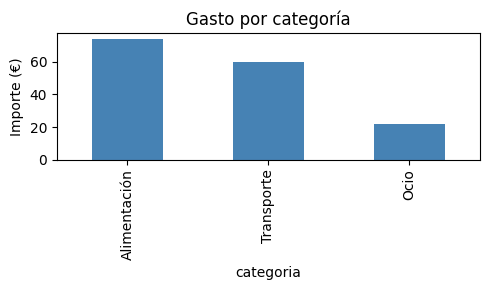

In [75]:
# ── Proyecto integrador final ─────────────────────────────────────────────────
# Gestor de gastos personales: integra OOP, ficheros, SQLite, pandas y gráficos.
# Objetivo pedagógico: mostrar cómo se combinan TODOS los módulos del curso
# en una aplicación pequeña pero realista.

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from datetime import date

@dataclass
class Gasto:
    """Representa un gasto individual."""
    concepto: str
    categoria: str
    importe: float
    fecha: str = str(date.today())


class GestorGastos:
    """Encapsula el acceso a una base de datos SQLite de gastos."""

    def __init__(self, ruta: str = ":memory:"):
        self.con = sqlite3.connect(ruta)
        self.con.execute("""
            CREATE TABLE IF NOT EXISTS gastos (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                concepto TEXT NOT NULL,
                categoria TEXT NOT NULL,
                importe REAL NOT NULL CHECK (importe > 0),
                fecha TEXT NOT NULL
            )
        """)
        self.con.commit()

    def anadir(self, gasto: Gasto):
        try:
            self.con.execute(
                "INSERT INTO gastos (concepto, categoria, importe, fecha) VALUES (?, ?, ?, ?)",
                (gasto.concepto, gasto.categoria, gasto.importe, gasto.fecha),
            )
            self.con.commit()
        except sqlite3.IntegrityError as e:
            print(f"No se pudo registrar el gasto: {e}")

    def como_dataframe(self) -> pd.DataFrame:
        return pd.read_sql_query("SELECT * FROM gastos", self.con)

    def cerrar(self):
        self.con.close()


# Uso de la aplicación
gestor = GestorGastos()
gastos_ejemplo = [
    Gasto("Supermercado", "Alimentación", 45.30),
    Gasto("Cine", "Ocio", 12.00),
    Gasto("Gasolina", "Transporte", 60.00),
    Gasto("Restaurante", "Alimentación", 28.50),
    Gasto("Streaming", "Ocio", 9.99),
]
for g in gastos_ejemplo:
    gestor.anadir(g)

# Intento de gasto inválido (importe <= 0) — debe fallar de forma controlada
gestor.anadir(Gasto("Gasto erróneo", "Otros", -5))

df = gestor.como_dataframe()
print(df)

resumen = df.groupby("categoria")["importe"].sum().sort_values(ascending=False)
print("\nGasto total por categoría:")
print(resumen)

fig, ax = plt.subplots(figsize=(5, 3))
resumen.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Importe (€)")
ax.set_title("Gasto por categoría")
plt.tight_layout()
plt.show()

gestor.cerrar()

---
# BUENAS PRÁCTICAS PROFESIONALES — pruebas automatizadas

### Conceptos clave

- `unittest` (incluido en la librería estándar) y `pytest` (el más usado en la industria) permiten automatizar la verificación de que el código funciona, sustituyendo los `print` y `assert` sueltos usados hasta ahora en las prácticas guiadas.
- Una **suite de tests** documenta el comportamiento esperado y detecta regresiones al modificar código.
- En un entorno profesional, los tests se ejecutan automáticamente en cada cambio (CI/CD).

### Errores frecuentes
- Escribir tests que dependen del orden de ejecución de otros tests.
- No probar los casos límite (valores negativos, vacíos, tipos inesperados).

In [76]:
# ── Pruebas unitarias formales: unittest y pytest ─────────────────────────────
import unittest

def es_primo(n: int) -> bool:
    if n < 2:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

class TestEsPrimo(unittest.TestCase):
    def test_numeros_primos(self):
        for p in [2, 3, 5, 7, 11, 97]:
            self.assertTrue(es_primo(p), f"{p} debería ser primo")

    def test_numeros_no_primos(self):
        for n in [0, 1, 4, 9, 100]:
            self.assertFalse(es_primo(n), f"{n} no debería ser primo")

    def test_negativos(self):
        self.assertFalse(es_primo(-7))

# Ejecutamos la suite dentro del notebook (equivalente a 'python -m unittest')
resultado = unittest.main(argv=[""], exit=False, verbosity=2)
print("¿Todos los tests pasaron?", resultado.result.wasSuccessful())

test_negativos (__main__.TestEsPrimo.test_negativos) ... 

ok


test_numeros_no_primos (__main__.TestEsPrimo.test_numeros_no_primos) ... 

ok


test_numeros_primos (__main__.TestEsPrimo.test_numeros_primos) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.004s

OK


¿Todos los tests pasaron? True


### Test final del módulo adicional

1. `pytest` frente a `unittest` es… b) más usado en la industria, sintaxis más simple
2. Un test unitario prueba… b) una unidad mínima de código (función/método)
3. `assertTrue`/`assertFalse` pertenecen a… b) `unittest`
4. Ejecutar tests automáticamente en cada cambio se conoce como… b) integración continua (CI)
5. Probar casos límite es importante para… b) detectar errores en los extremos
6. Una suite de tests actúa también como… b) documentación viva del comportamiento
7. `unittest.main()` en un notebook requiere… b) `argv=[""], exit=False`
8. Los tests deben ser… b) independientes entre sí
9. Un test que falla silenciosamente es… b) peor que uno que falla ruidosamente
10. Automatizar pruebas reduce… b) el riesgo de regresiones al modificar código

*(Autoevaluación: comenta tus respuestas con el profesorado o consulta la versión del profesorado.)*

---
# Cierre

Este notebook cubre los **4 módulos** del Curso de Especialización en Python con:

- **Conceptos clave** explicados en tablas y texto.
- **Razonamiento** orientado a estudiantes de informática.
- **Prácticas ejecutables** directamente en las celdas de código.
- **Errores frecuentes** y buenas prácticas.
- **10 preguntas tipo test** por epígrafe con las respuestas correctas marcadas.
- **Módulo complementario** sobre el REPL interactivo de Python.

Para cambiar el intérprete Python utiliza el selector de kernel en la barra superior del notebook.